# -----------------------------------------------------
### PROJEKT - Analiza danych
# -----------------------------------------------------

Wybrany został zbiór danych dotyczący ofert sprzedaży mieszkań z serwisu OTODOM z czerwca 2024, na podstawie którego przeprowadzona zostanie analiza eksploracyjna danych.  

Plik analizowany nazywa się  apartments_pl_2024_06.csv, który pochodzi z serwisu Kaggle. Autorem jest Pan Krzysztof Jamroz. https://www.kaggle.com/datasets/krzysztofjamroz/apartment-prices-in-poland  

Projekt dotyczy analizy danych ofert sprzedaży mieszkań z  15 największych miast w Polsce. Są to:  Białystok
Bydgoszcz
Częstochowa
Gdańsk
Gdynia
Katowice
Kraków
Lublin
Łódź
Poznań
Radom
Rzeszów
Szczecin
Warszawa
Wrocław

Podział zadań:
Czyszczenie, przekształcanie danych i statystyki opisowe - Mikołaj, Maja - osoba sprawdzająca
Eksploracyjna analiza danych i wizuaizacje - Michał, Mikołaj - osoba sprawdzająca
Wnioskowanie statystyczne - Maja, Michał - osoba sprawdzająca


# -----------------------------------------------------
### Opis, czyszczenie i przekształcanie danych

### Importowanie bibliotek

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
from scipy.stats import chi2_contingency
import missingno as msno
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer, IterativeImputer
import matplotlib.ticker as mtick
import pingouin as pg

### Wyjaśnienia zmiennych 
- **city** — Nazwa miasta, w którym znajduje się nieruchomość.
- **type** — Typ budynku (np. blockOfFlats – blok, apartmentBuilding – kamienica/budynek wielorodzinny).
- **squareMeters** — Powierzchnia mieszkania w metrach kwadratowych (m²).
- **rooms** — Liczba pokoi w mieszkaniu.
- **floor** — Piętro, na którym zlokalizowane jest mieszkanie.
- **floorCount** — Całkowita liczba pięter w budynku.
- **buildYear** — Rok budowy budynku.
- **latitude, longitude** — Współrzędne geograficzne nieruchomości.
- **centreDistance** — Odległość od centrum miasta (w km).
- **poiCount** — Liczba punktów użyteczności publicznej (POI) w promieniu 500 m od mieszkania.
- **[poiName]Distance** — Odległość do najbliższego punktu użyteczności publicznej danego typu (np. schoolDistance, pharmacyDistance).
- **ownership** — Rodzaj własności (np. condominium – własność, cooperative – spółdzielcze).
- **condition** — Stan/standard wykończenia mieszkania (np. premium, high, low).
- **has[features]** — Zmienne logiczne (tak/nie) opisujące udogodnienia:
-  **hasParkingSpace**, **hasBalcony**, **hasElevator**, **hasSecurity**, **hasStorageRoom**.
- **price** — Cena oferty w Polskich Złotych (PLN).


### Pobranie danych z pliku CSV i wyświetlenie pierwszych kilku wierszy

In [67]:
df = pd.read_csv("apartments_pl_2024_06.csv", encoding="utf-8")
print(df.head())

                                 id      city               type  \
0  811891f98a870dfd6e414374a0a85560  szczecin       blockOfFlats   
1  adaf636d0c44d8d9325bce42403eefee  szczecin  apartmentBuilding   
2  9b957bd60885a469c96f17b58a914f4b  szczecin  apartmentBuilding   
3  74fef2ff7135bc70797a3fbfd7d44ed6  szczecin       blockOfFlats   
4  77cc78c75b0d09bf84d6d3124a28803c  szczecin       blockOfFlats   

   squareMeters  rooms  floor  floorCount  buildYear   latitude  longitude  \
0         47.00    2.0    6.0        12.0     1981.0  53.428544  14.552812   
1         88.22    3.0    1.0         2.0     2000.0  53.449093  14.516844   
2        117.00    5.0    4.0         4.0        NaN  53.443096  14.561348   
3         33.31    1.0    1.0         4.0     1963.0  53.436100  14.541200   
4         56.00    3.0    7.0         7.0     2018.0  53.447465  14.557811   

   ...  pharmacyDistance    ownership  buildingMaterial  condition  \
0  ...             0.085  condominium      concreteS

### Wyświetlanie podstawowych informacji o zbiorze danych

In [68]:
# Tłumaczenie nazw kolumn

translation = {

    'city': 'miasto',

    'type': 'typ_zabudowy',

    'squareMeters': 'metraż',

    'rooms': 'liczba_pokoi',

    'floor': 'piętro',

    'floorCount': 'liczba_pięter_w_budynku',

    'buildYear': 'rok_budowy',

    'buildingMaterial': 'materiał_budowlany',

    'latitude': 'szerokość_geograficzna',

    'longitude': 'długość_geograficzna',

    'centreDistance': 'odległość_od_centrum',

    'schoolDistance': 'odległość_od_szkoły',

    'clinicDistance': 'odległość_od_przychodni',
    'collegeDistance': 'odległość_od_uczelni',

    'postOfficeDistance': 'odległość_od_urzędu_pocztowego',

    'kindergartenDistance': 'odległość_od_przedszkola',

    'restaurantDistance': 'odległość_od_restauracji',

    'pharmacyDistance': 'odległość_od_apteki',

    'poiCount': 'liczba_punktów_użyteczności_w_promieniu_500m',

    'ownership': 'rodzaj_własności',

    'condition': 'standard_wykończenia',

    'hasParkingSpace': 'czy_posiada_parking',

    'hasBalcony': 'czy_posiada_balkon',

    'hasElevator': 'czy_posiada_windę',

    'hasSecurity': 'czy_posiada_ochronę',

    'hasStorageRoom': 'czy_posiada_komórkę_lokatorską',

    'price': 'cena',

}



# Zmiana nazw kolumn w ramce danych

df = df.rename(columns=translation)

df.columns = [col.replace('Distance', '_odległość') for col in df.columns]

In [69]:
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (21501, 28)

First few rows:
                                 id    miasto       typ_zabudowy  metraż  \
0  811891f98a870dfd6e414374a0a85560  szczecin       blockOfFlats   47.00   
1  adaf636d0c44d8d9325bce42403eefee  szczecin  apartmentBuilding   88.22   
2  9b957bd60885a469c96f17b58a914f4b  szczecin  apartmentBuilding  117.00   
3  74fef2ff7135bc70797a3fbfd7d44ed6  szczecin       blockOfFlats   33.31   
4  77cc78c75b0d09bf84d6d3124a28803c  szczecin       blockOfFlats   56.00   

   liczba_pokoi  piętro  liczba_pięter_w_budynku  rok_budowy  \
0           2.0     6.0                     12.0      1981.0   
1           3.0     1.0                      2.0      2000.0   
2           5.0     4.0                      4.0         NaN   
3           1.0     1.0                      4.0      1963.0   
4           3.0     7.0                      7.0      2018.0   

   szerokość_geograficzna  długość_geograficzna  ...  odległość_od_apteki  \
0               53.428544            

In [70]:
print("\nData types:")
print(df.dtypes)


Data types:
id                                               object
miasto                                           object
typ_zabudowy                                     object
metraż                                          float64
liczba_pokoi                                    float64
piętro                                          float64
liczba_pięter_w_budynku                         float64
rok_budowy                                      float64
szerokość_geograficzna                          float64
długość_geograficzna                            float64
odległość_od_centrum                            float64
liczba_punktów_użyteczności_w_promieniu_500m    float64
odległość_od_szkoły                             float64
odległość_od_przychodni                         float64
odległość_od_urzędu_pocztowego                  float64
odległość_od_przedszkola                        float64
odległość_od_restauracji                        float64
odległość_od_uczelni               

### Statystyka opisowa

In [71]:
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
             metraż  liczba_pokoi        piętro  liczba_pięter_w_budynku  \
count  21501.000000  21501.000000  17928.000000             21292.000000   
mean      56.968572      2.622948      3.404786                 5.474826   
std       20.617717      0.892924      2.606225                 3.407545   
min       25.000000      1.000000      1.000000                 1.000000   
25%       42.690000      2.000000      2.000000                 3.000000   
50%       52.810000      3.000000      3.000000                 4.000000   
75%       66.300000      3.000000      4.000000                 7.000000   
max      150.000000      6.000000     29.000000                29.000000   

         rok_budowy  szerokość_geograficzna  długość_geograficzna  \
count  18121.000000            21501.000000          21501.000000   
mean    1986.774129               51.992750             19.496174   
std       32.796668                1.313801              1.754150   
min     1850.000000 

### Charakterystyka Nieruchomości
Analiza Powierzchni

Średnia powierzchnia (57 m²): Jest to metraż typowy dla polskich warunków, odpowiadający mieszkaniu trzypokojowemu (standard M4). Tradycyjnie taki układ dedykowany był rodzinie czteroosobowej (salon + dwie sypialnie). Współcześnie jednak, biorąc pod uwagę zmiany demograficzne i model pracy, trzeci pokój zyskuje nowe funkcje. Zamiast pokoju dziecięcego, może by adaptowany jest na domowe biuro (home office), gabinet do przyjmowania klientów lub pokój gościnny.

Wartość minimalna (25 m²): Dolna granica zbioru pokrywa się z aktualnymi przepisami polskiego prawa budowlanego (§ 94,Dz.U.2022.1225 ), które określają minimalną powierzchnię samodzielnego lokalu mieszkalnego właśnie na 25 m². Sugeruje to, że dane zostały poprawnie wyczyszczone z błędnych wpisów (np. garaży czy komórek).

Wartość maksymalna (150 m²): Górna granica wskazuje na obecność w zbiorze dużych apartamentów. Jednocześnie brak metraży rzędu powyżej m² pozwala na postawienie hipotezy, że zbiór zawiera wyłącznie mieszkania, a wyklucza domy jednorodzinne, które zazwyczaj charakteryzują się znacznie większą powierzchnią. 

Mediana liczby pokoji to 3 pokoje. Jest to tożsame z powierzchnią mieszkań.

Wiek budynku (buildYear): Zakres to 1850 – 2024. Przekrój od przedwojennych kamienic i bloki z PRL po rynek pierwotny i nowo oddane budynki. Mediana to 1993 a średnia wynosi 1986. Fakt, że średnia  jest niższa od mediany , wskazuje na rozkład lewostronnie skośny. Wynika to z obecności w zbiorze starych nieruchomości (np. XIX-wiecznych kamienic), które matematycznie zaniżają średnią. Mediana jest tu bardziej miarodajna i pokazuje, że „typowy” budynek pochodzi z 1993 roku, a połowa wszystkich ofert jest nowsza niż ten rok. Połowa mieszkań została wybudowana pozniej niż 1993 rok.

Mediana liczby pięter to 3 , co pasuje do polskiego krajobrazu, maksymalna liczba piętra to 29, co pokazuję, ze w zbiorze były oferty z najwyższych nowoczesnych wieżowcow.

Wszystki dane distance, obrazują, że mieszkania znajdują się w gęste zabudowie miejskiej.
Średnia odległość do szkoły, przedszkola, restauracji, apteki wynosi 300-400 metrów, rzadko kiedy wartosc dla trzeciego kwartyla przekracza pół kilometra.

Średnio mieszkania mają 20 punktów w okolicy, 
Najtańsze mieszkanie zostało wystawione za  191 000 zł. Najdroższe mieszkanie kosztowało 3 mln złoty.

Średnia (~823 tys. zł) jest wyższa niż Mediana (~721 tys. zł), to rozkład prawoskośny. Kilka bardzo drogich luksusowych apartamentów zawyża średnią, ale typowy obywatel kupuje mieszkanie za ok. 720 tys. zł.

In [72]:
# 1. Poprawiamy nazwy miast
city_corrections = {
    'warszawa': 'Warszawa',
    'lodz': 'Łódź',
    'wroclaw': 'Wrocław',
    'poznan': 'Poznań',
    'gdansk': 'Gdańsk',
    'krakow': 'Kraków',
    'bialystok': 'Białystok',
    'czestochowa': 'Częstochowa',
    'rzeszow': 'Rzeszów',
}

# 2. Mapujemy nazwy i poprawiamy wielkość liter dla pozostałych
df['miasto'] = df['miasto'].str.lower().map(city_corrections).fillna(df['miasto'].str.capitalize())

# 3. Obliczamy średnią cenę
avg_price_by_city = df.groupby('miasto')['cena'].mean().round(2).reset_index(name='średnia_cena').sort_values('średnia_cena', ascending=False)
avg_price_by_city

,miasto,średnia_cena
12,Warszawa,1053134.17
6,Kraków,942168.78
3,Gdańsk,891338.46
4,Gdynia,884684.61
13,Wrocław,745965.31
8,Poznań,647102.18
10,Rzeszów,636870.79
7,Lublin,581738.83
11,Szczecin,572548.94
5,Katowice,528239.56


Najwyższą cena średnia posiada Warszawa, Kraków, Gdańsk i Gdynia. Średnia cena w tych miastach jest większą niż średnia z całej próbki.

### Analiza średniej ceny i metrażu

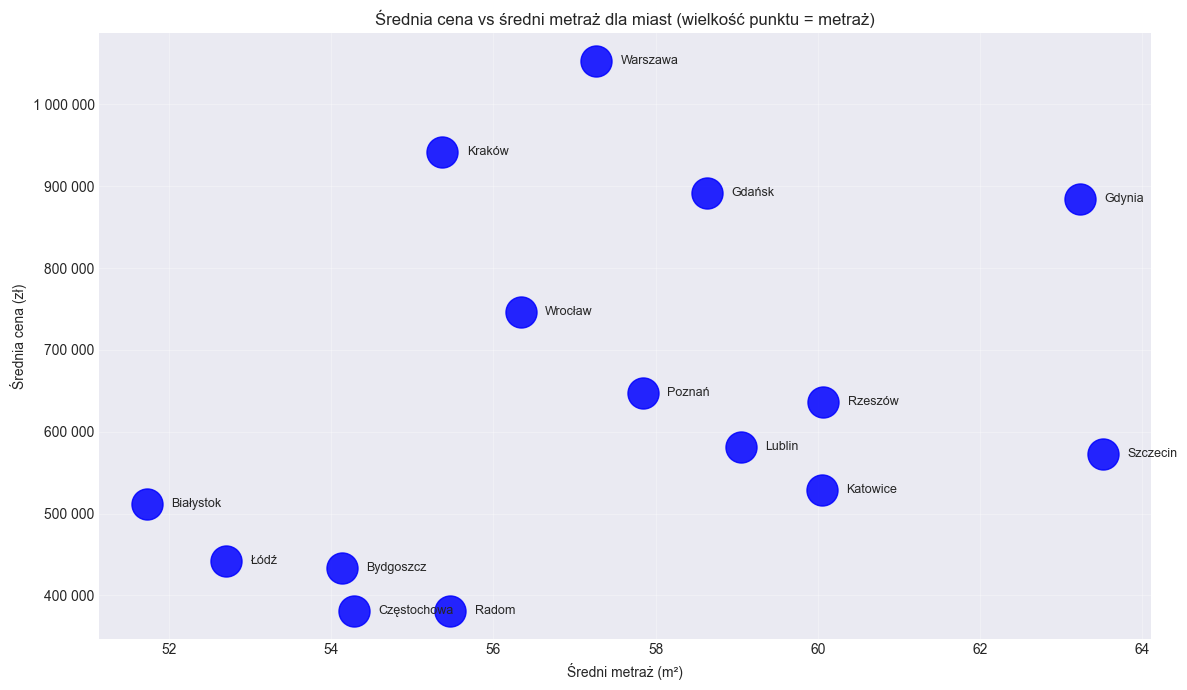

In [73]:
# 1.
import matplotlib.ticker as mtick
# Obliczamy średnią cenę i metraż dla każdego miasta
df_plot = df.groupby('miasto')[['cena', 'metraż']].mean().reset_index()

df_plot.columns = ['miasto', 'średnia_cena', 'średni_metraż']

# 2. DEFINICJA OSI
x = df_plot['średni_metraż']
y = df_plot['średnia_cena']

sizes = 500  

# 3. RYSOWANIE WYKRESU
fig, ax = plt.subplots(figsize=(12, 7))

# Przykład dla koloru niebieskiego
sc = ax.scatter(x, y, s=sizes, c='blue', alpha=0.85)

# 4. PODPISY MIAST
for _, r in df_plot.iterrows():
    ax.text(r['średni_metraż'] + 0.3, r['średnia_cena'], r['miasto'], fontsize=9, va='center')

# 5. FORMATOWANIE
ax.set_xlabel('Średni metraż (m²)')
ax.set_ylabel('Średnia cena (zł)')
ax.set_title('Średnia cena vs średni metraż dla miast (wielkość punktu = metraż)')
ax.grid(alpha=0.3)

# Formatowanie osi Y 
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda val, pos: f"{int(val):,}".replace(',', ' ')))

plt.tight_layout()
plt.show()

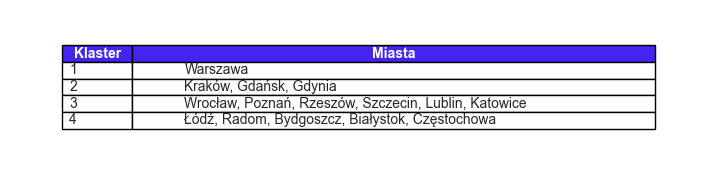

In [74]:

import matplotlib.pyplot as plt

# Dane ograniczone do klastra i nazw miast
data = [
    ["1", "Warszawa"],
    ["2", "Kraków, Gdańsk, Gdynia"],
    ["3", "Wrocław, Poznań, Rzeszów, Szczecin, Lublin, Katowice"],
    ["4", "Łódź, Radom, Bydgoszcz, Białystok, Częstochowa"]
]

columns = ["Klaster", "Miasta"]

# Tworzenie figury
fig, ax = plt.subplots(figsize=(9, 2))
ax.axis('tight')
ax.axis('off')

# Tworzenie tabeli
table = ax.table(cellText=data, colLabels=columns, cellLoc='left', loc='center')

# Stylizacja
table.auto_set_font_size(False)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#4624F0")  
    if col == 0:
        cell.set_width(0.10)  
    if col == 1:
        cell.set_width(0.75) 

plt.show()



W oparciu o powyższy wykres zależności średniej ceny do średniego metrażu w danym mieście , dokonano segmentacji badanych miast, wyodrębniając cztery główne klastry o zbliżonej charakterystyce rynkowej.
Na wykresie można wyodrębnić cztery wyraźne grupy miast o odmiennej charakterystyce:

      
1. Warszawa jest outlierem. Jest to rynek całkowicie oderwany od reszty kraju pod względem cenowym. Mimo że średni metraż  nie odbiega od średniej krajowej, cena całkowita jest wyższa niż w kolejnych najdroższych miastach.
2. Klaster 2: Rynki Premium.
    Miasta: Kraków, Gdańsk, Gdynia
   Charakterystyka:Ścisła czołówka Polski.
   Kraków ma wysoką cenę przy najmniejszym metrażu ze zbioru. Gdynia ma z kolei największą średni metraż z tej grupy i drugi największy z wszystkich podanych miast.
3. Wrocław, Poznań, Rzeszów, Szczecin, Lublin, Katowice.
Ceny zawierają się w przedziale 550 tys. – 750 tys. zł.Wyróżnia się tu podgrupa miast oferujących dużą przestrzeń, są to m.in. (Szczecin, Katowice, Rzeszów).
1. Rynki Budżetowe: Białystok, Łódz, Radom, Bydgoszcz, Częstochowa 
Miasta o najniższej barierze wejścia (ceny poniżej 550 tys. zł) i najmniejszym przeciętnim metrażu.

### Analiza brakujących danych

In [75]:
# liczba brakujacych danych (całkowita)
n_miss = df.isna().sum().sum()
print("n_miss:", n_miss)  

# liczba kompletnych obserwacji (wierszy bez braków)
n_complete = df.dropna().shape[0]
print("n_complete:", n_complete)  # liczba kompletnych obserwacji

# proporcja braków (w skali całego dataframe)
prop_miss = n_miss / (df.shape[0] * df.shape[1])
print("prop_miss:", prop_miss)  # proporcja brakujacych danych

# dodatkowo: brakujące wartości na kolumnę (opcjonalne)
print("missing per column:\n", df.isna().sum())

# ponowne obliczenie i wyświetlenie wyników
print("n_complete (computed):", n_complete)  # liczba kompletnych obserwacji
print("prop_miss (computed):", prop_miss)    # proporcja

n_miss: 37990
n_complete: 2750
prop_miss: 0.0631033772515564
missing per column:
 id                                                  0
miasto                                              0
typ_zabudowy                                     4397
metraż                                              0
liczba_pokoi                                        0
piętro                                           3573
liczba_pięter_w_budynku                           209
rok_budowy                                       3380
szerokość_geograficzna                              0
długość_geograficzna                                0
odległość_od_centrum                                0
liczba_punktów_użyteczności_w_promieniu_500m        0
odległość_od_szkoły                                11
odległość_od_przychodni                            63
odległość_od_urzędu_pocztowego                     20
odległość_od_przedszkola                           19
odległość_od_restauracji                           31


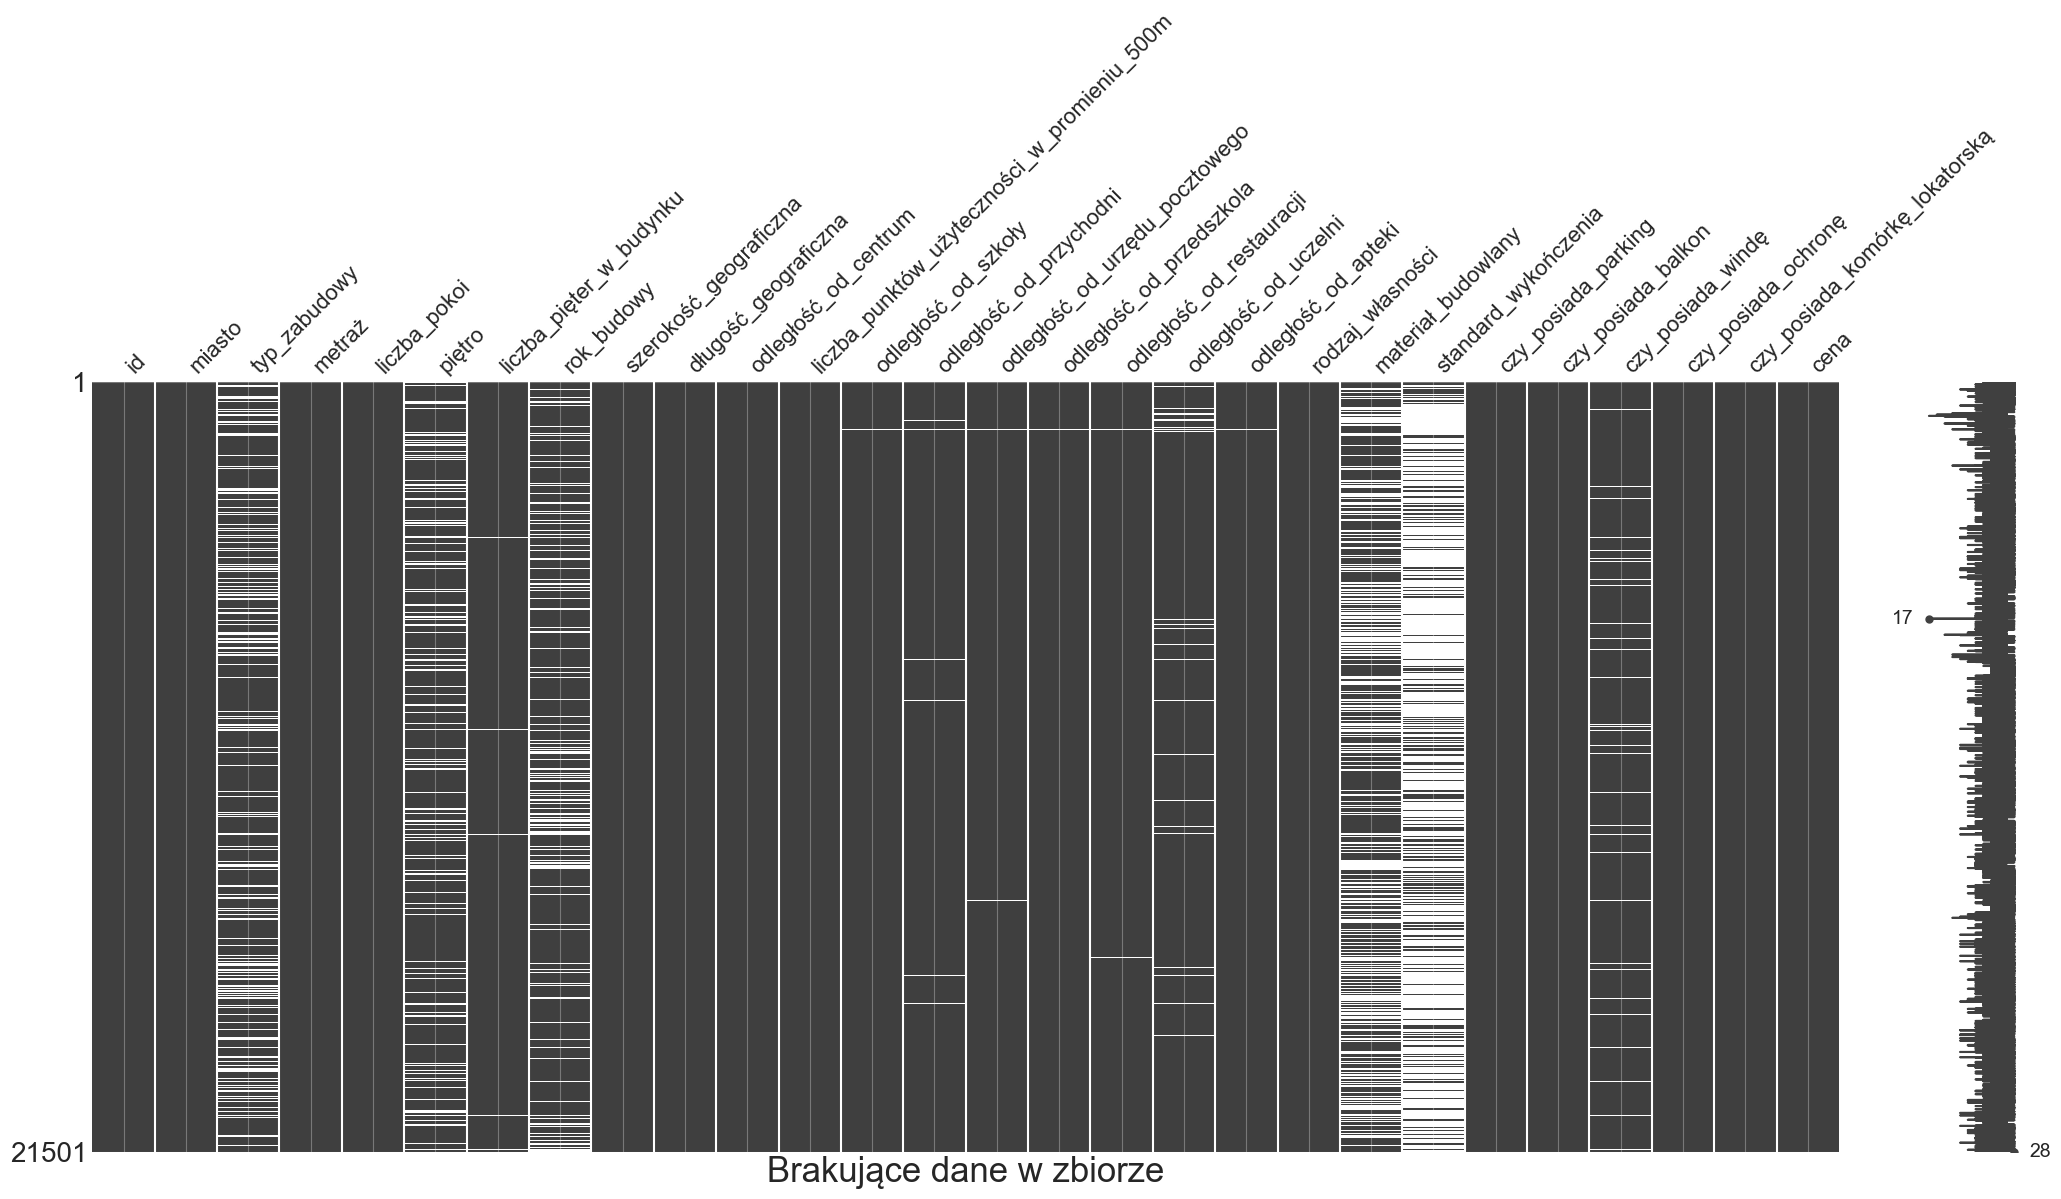

In [76]:
import missingno as msno
ax = msno.matrix(df) 

ax.set_title('Brakujące dane w zbiorze', fontsize=25, y=-0.05) 

ax.grid(alpha=0.3) 

plt.show()


### Braki w poszczególnych kolumnach

In [77]:
# proporcja braków w poszczególnych kolumnach
prop_miss_cols = df.isna().sum() / df.shape[0]

print("Proporcje braków w kolumnach:")
print(prop_miss_cols)

# wizualizacja braków w kolumnach
prop_miss_cols_pct = df.isna().mean() * 100
print("Procent braków w kolumnach:")
print(prop_miss_cols_pct)


Proporcje braków w kolumnach:
id                                              0.000000
miasto                                          0.000000
typ_zabudowy                                    0.204502
metraż                                          0.000000
liczba_pokoi                                    0.000000
piętro                                          0.166178
liczba_pięter_w_budynku                         0.009720
rok_budowy                                      0.157202
szerokość_geograficzna                          0.000000
długość_geograficzna                            0.000000
odległość_od_centrum                            0.000000
liczba_punktów_użyteczności_w_promieniu_500m    0.000000
odległość_od_szkoły                             0.000512
odległość_od_przychodni                         0.002930
odległość_od_urzędu_pocztowego                  0.000930
odległość_od_przedszkola                        0.000884
odległość_od_restauracji                        0.001442
o

Wykres przedstawia brakujące wartości w badanym zbiorze danych.
 Ciemne pola to dane kompletne, a białe brakujące.
 Zmienne niemal kompletne to: miasto, typ zabudowy, metraż, liczba pokoji, szerokość, długość geograficzna, cena.
 Są one istotnymi zmiennymi w kwestii zróżnicowania mieszkań i są całkowicie pozbawione braków.
 Przedstawia to jednolity ciemny wykres. Występują również zmienne z umiarkowanymi brakami. Sądzac z wykresu braki występują losowo i  raczej równomiernie w kolumnach: liczba pięter (0.9%),  zmiennych określajacych dystans ( które są też mniejsze niż 1%). 
 Zmienne : typ zabudowy i standard wykończenia, mają duża część obserwacji brakujących. Jesto to odpowiednio 20%, 41%,74%. Będą one szczególnej uwagi przy czyszczeniu danych imputacja lub ich usunięcie.Podsumowując, większość kluczowych danych lokalizacja, metraż, cena jest kompletna, co czyni zbiór gotowym do dalszej analizy. Braki koncentrują się głównie na zmiennych opisujących wyposażenie i stan budynku.

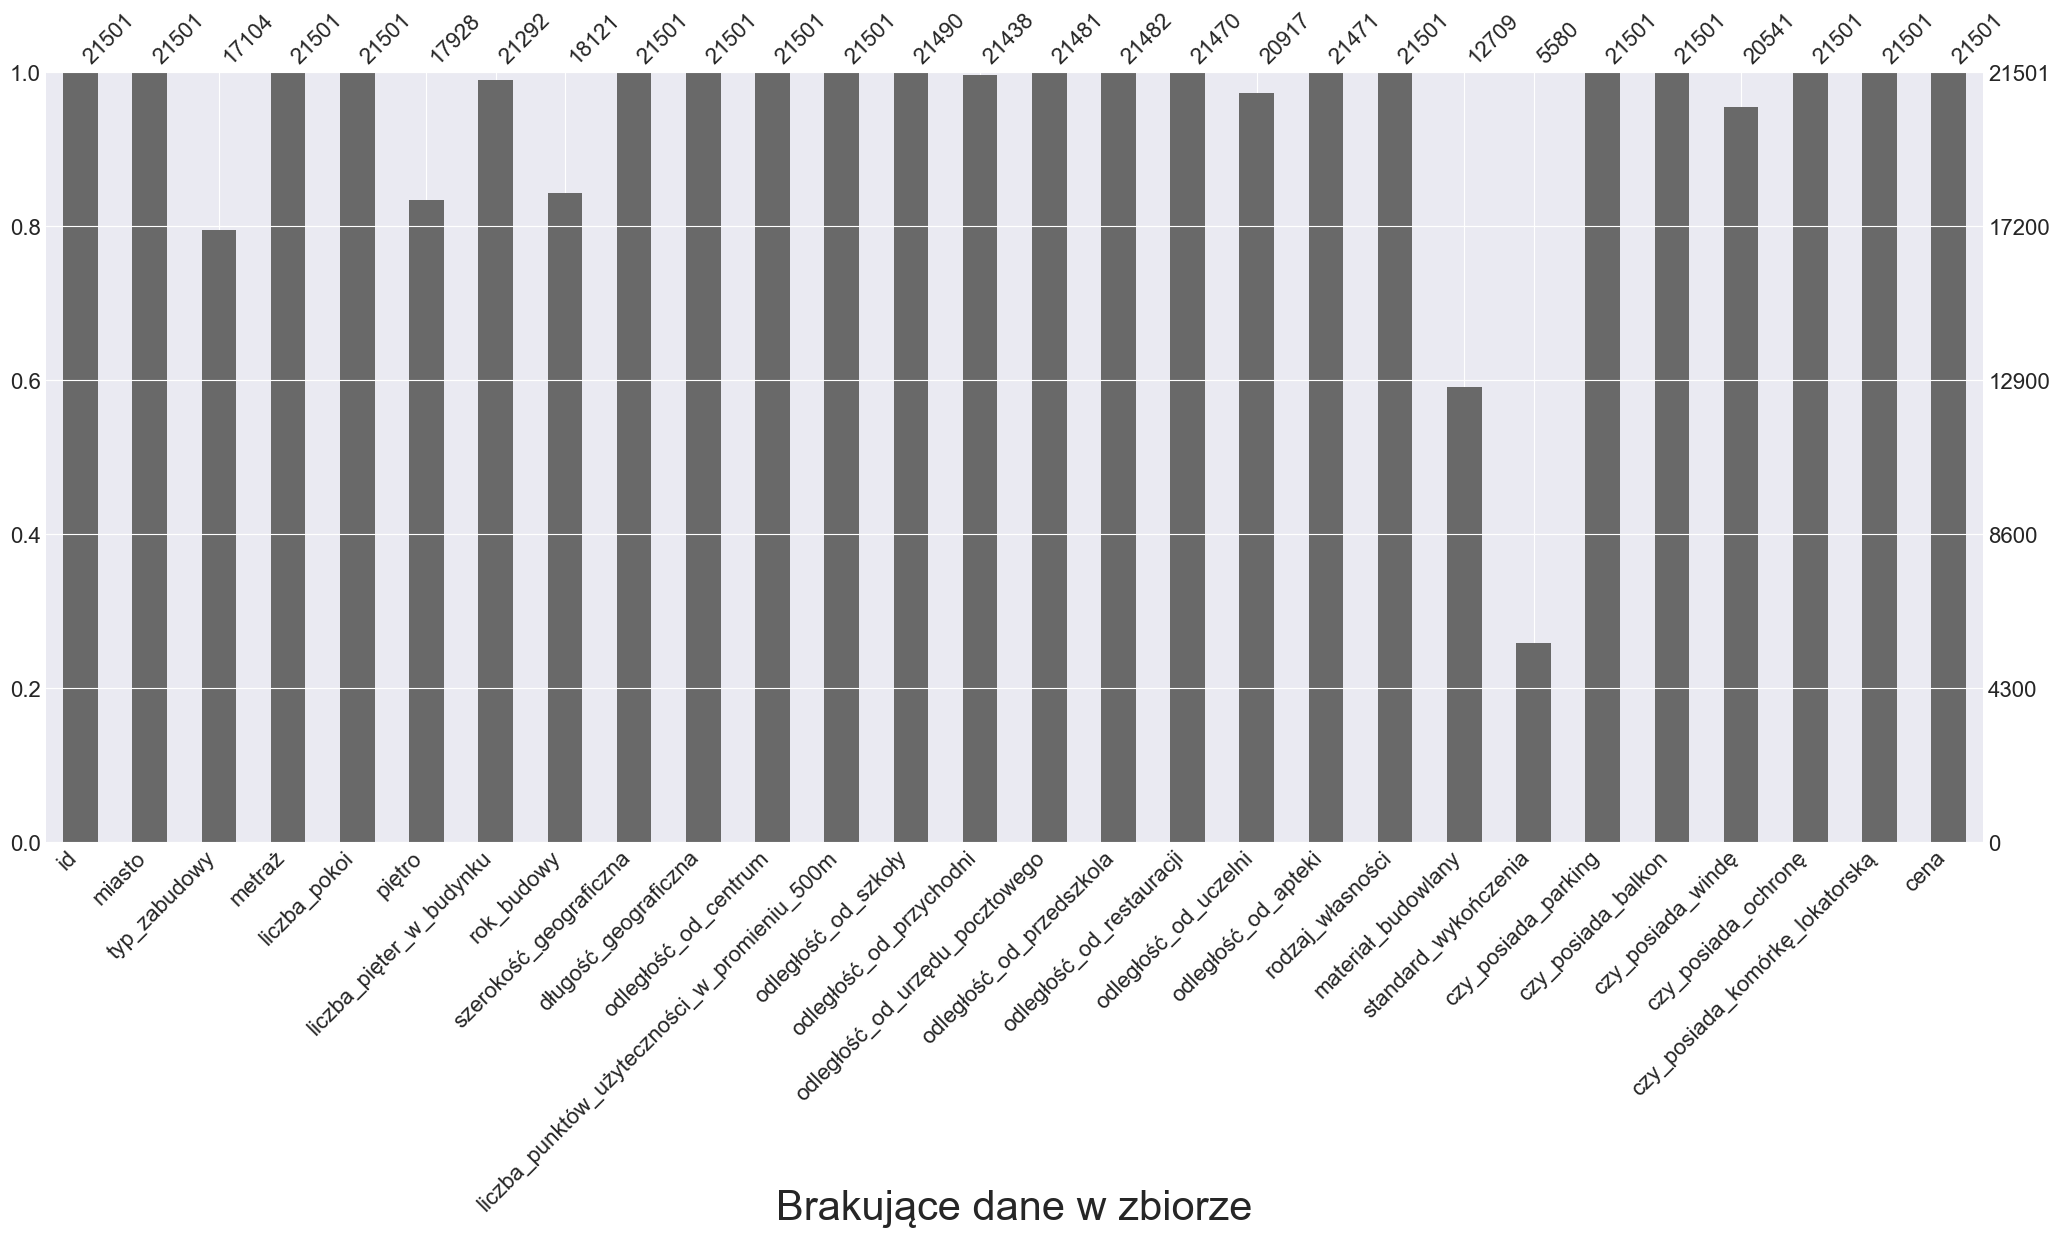

In [78]:

ax=msno.bar(df)

ax.set_title('Brakujące dane w zbiorze', y=-0.5, fontsize=30)

plt.show()

In [79]:
# Sprawdzenie braków
import pandas as pd
import numpy as np

def is_special(x):

    if pd.api.types.is_numeric_dtype(x):
     
        return ~np.isfinite(x.astype(float)) 
    else:
        return x.isna()

# Wywołanie
result = df.apply(is_special)
print(result.sum()) # Pokazuje liczbę "specjalnych" wartości w każdej kolumnie

id                                                  0
miasto                                              0
typ_zabudowy                                     4397
metraż                                              0
liczba_pokoi                                        0
piętro                                           3573
liczba_pięter_w_budynku                           209
rok_budowy                                       3380
szerokość_geograficzna                              0
długość_geograficzna                                0
odległość_od_centrum                                0
liczba_punktów_użyteczności_w_promieniu_500m        0
odległość_od_szkoły                                11
odległość_od_przychodni                            63
odległość_od_urzędu_pocztowego                     20
odległość_od_przedszkola                           19
odległość_od_restauracji                           31
odległość_od_uczelni                              584
odległość_od_apteki         

In [80]:

# Definiujemy
def is_special(x):
    if np.issubdtype(x.dtype, np.number):
        return ~np.isfinite(x) # Zwraca True dla NaN oraz inf/-inf
    else:
        return x.isna()
total_special = df.apply(is_special).sum()
just_na = df.isna().sum()
def count_inf(x):
    if np.issubdtype(x.dtype, np.number):
        return np.isinf(x).sum()
    return 0

just_inf = df.apply(count_inf)

# Tabela podsumowującą
raport = pd.DataFrame({
    'Wszystkie Specjalne': total_special,
    'Tylko Braki (NA)': just_na,
    'Tylko Nieskończoności (Inf)': just_inf
})

# Filtrujemy, żeby pokazać tylko kolumny, gdzie cokolwiek wykryto
raport_z_bledami = raport[raport['Wszystkie Specjalne'] > 0]

print(raport_z_bledami)

                                Wszystkie Specjalne  Tylko Braki (NA)  \
typ_zabudowy                                   4397              4397   
piętro                                         3573              3573   
liczba_pięter_w_budynku                         209               209   
rok_budowy                                     3380              3380   
odległość_od_szkoły                              11                11   
odległość_od_przychodni                          63                63   
odległość_od_urzędu_pocztowego                   20                20   
odległość_od_przedszkola                         19                19   
odległość_od_restauracji                         31                31   
odległość_od_uczelni                            584               584   
odległość_od_apteki                              30                30   
materiał_budowlany                             8792              8792   
standard_wykończenia                          15921

In [81]:
# Liczba wierszy do odrzucenia (gdyby miały złą niską cenę)
liczba_do_odrzucenia = ((df["cena"] < 150000)).sum()

print(f"Liczba ofert do odrzucenia: {liczba_do_odrzucenia}")


Liczba ofert do odrzucenia: 0


W zbiorze danych występują jedynie braki danych w postaci wartości NaN (braków typowych). Nie ma innych "specjalnych" braków, takich jak nieskończoności (Inf) czy wartości nieprawidłowe np. cena poniżej 150 tys złotych. W 06.2024 w największych miastach Poski mieszkanie nie mogłyby być wystawione na sprzedaż za tą cenę.

### Braki w danych według miast

<Figure size 1200x500 with 0 Axes>

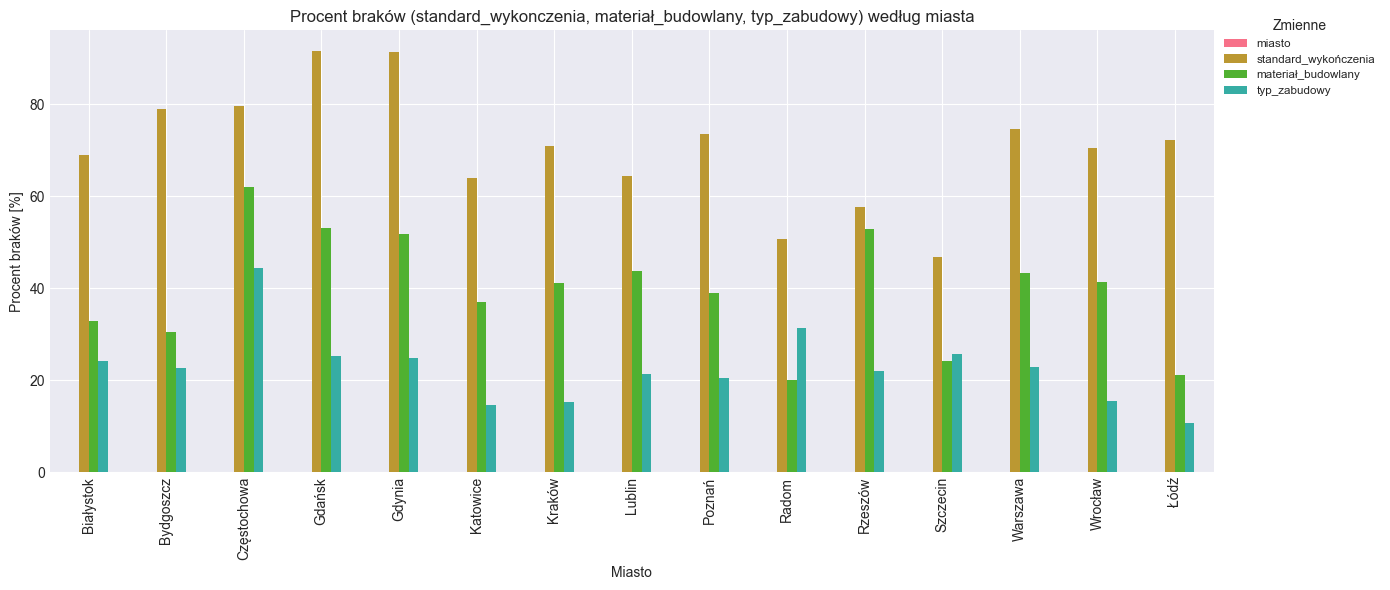

In [82]:
# --- Funkcja: procent braków wg miasta ---
def gg_miss_city_selected(df, 
                          city_col="miasto",
                          selected_cols=["standard_wykończenia", "materiał_budowlany", "typ_zabudowy"],
                          figsize=(12,5)):

    # filtr tylko wybranych kolumn
    df_selected = df[[city_col] + selected_cols]

    # liczba obserwacji w każdym mieście
    count_by_city = df_selected.groupby(city_col).size()

    # liczba braków w poszczególnych kolumnach wg miasta
    miss_count = df_selected.isna().groupby(df_selected[city_col]).sum()

    # procent braków = (liczba braków / liczba rekordów) * 100
    miss_pct = (miss_count.T / count_by_city).T * 100

    # wykres
    plt.figure(figsize=figsize)
    miss_pct.plot(kind="bar")
    plt.title("Procent braków (standard_wykonczenia, materiał_budowlany, typ_zabudowy) według miasta")
    plt.ylabel("Procent braków [%]")
    plt.xlabel("Miasto")
    plt.legend(fontsize="small", 
               title="Zmienne", 
               loc='upper left', 
               bbox_to_anchor=(1, 1.05))
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# --- Wywołanie ---
gg_miss_city_selected(df)

In [83]:
# Obliczamy procent braków w danych
# 1. Obliczamy liczbę kolumn
n_cols = df.shape[1]

# 2. Obliczamy sumę braków w każdym wierszu, a potem sumujemy je według miast
# Ta metoda unika użycia .apply() i jest zgodna z nowymi wersjami pandas
missing_counts = df.isna().sum(axis=1).groupby(df["miasto"]).sum()

# 3. Liczebność miast
city_counts = df.groupby("miasto").size()

# 4. Obliczamy procent
missing_pct_by_city = (missing_counts / (city_counts * n_cols)) * 100

# 5. Sortujemy malejąco i pokazujemy wynik
missing_pct_by_city = missing_pct_by_city.sort_values(ascending=False)
print(missing_pct_by_city)

# 6. Najgorsze miasto pod względem braków
worst_city = missing_pct_by_city.index[0]
worst_pct = missing_pct_by_city.iloc[0]
print(f"\nMiasto z największym procentem braków: {worst_city} ({worst_pct:.2f}%)")

miasto
Częstochowa    9.582560
Gdynia         8.096101
Gdańsk         7.495324
Bydgoszcz      6.735021
Katowice       6.661046
Poznań         6.575392
Rzeszów        6.332165
Warszawa       6.152276
Kraków         5.976227
Wrocław        5.793546
Lublin         5.711797
Białystok      5.674088
Łódź           5.655994
Szczecin       5.199823
Radom          5.091575
dtype: float64

Miasto z największym procentem braków: Częstochowa (9.58%)


Na przedstawionym wykresie kolumnowym widzimy udział brakujących wartości dla trzech zmiennych opisujących oferty mieszkaniowe analizowane w tym projekcie: standard_wykonczenia, materiał budwolany oraz rodzaj zabudowy, pogrupowanych według miasta. Brak definiujemy jako brak jednej zmiennej w danym ogłoszeniu.
Najbardziej wyróżnia się zmienna standard wykończenia, która we wszystkich miastach charakteryzuje się zdecydowanie najwyższym odsetkiem braków. 
W przypadku pozostałych zmiennych udziały braków są mniejsze, choć zauważalnie zróżnicowane pomiędzy miastami. Co ciekawe, mimo że średni poziom braków w zmiennej buildingMaterial jest wyższy, to w części miast występuje odwrotna zależność — np. w Częstochowie i Gdansku odsetek braków dla type jest większy niż dla materiał budwolany.
Miasta o najniższej jakości pełnych informacji w ogłoszeniach to:

Częstochowa – niemal 10% wszystkich informacji w analizowanych zmiennych jest nieuzupełnionych,

Gdynia – około 8%,

Gdańsk – blisko 7,5%.

Wskazuje to, że w tych miastach użytkownicy rynku nieruchomości mogli częściej napotkać niekompletne opisy ofert w czerwcu 2024, co mogło utrudniac porównywanie mieszkań i podejmowanie decyzji zakupowych.

### Inputacja brakujących danych

In [84]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

# --- 1. Grupa: Dane opisowe z dużymi brakami - usuwamy 
df.drop(columns=['standard_wykończenia', 'materiał_budowlany'], inplace=True, errors='ignore')

# --- 2. Grupa: Numeryczne ważne - Imputacja MICE ---
cols_to_impute = [
    'rok_budowy', 
    'piętro', 
    'liczba_pięter_w_budynku', 
    'odległość_od_centrum',
    'liczba_punktów_użyteczności_w_promieniu_500m',
    'odległość_od_szkoły',
    'odległość_od_przychodni',
    'odległość_od_urzędu_pocztowego',
    'odległość_od_przedszkola',
    'odległość_od_restauracji',
    'odległość_od_apteki',
    'odległość_od_uczelni'
]

# Konfiguracja i wykonanie MICE
iter_imputer = IterativeImputer(random_state=42)
df[cols_to_impute] = iter_imputer.fit_transform(df[cols_to_impute])

# Zaokrąglanie wartości, które muszą być liczbami całkowitymi
cols_integers = ['rok_budowy', 'piętro', 'liczba_pięter_w_budynku']
for col in cols_integers:
    df[col] = df[col].round().astype('Int64')

print("Braki danych po MICE (numeryczne):")
print(df[cols_to_impute].isna().sum())

# --- 3. Grupa: Winda (czy_posiada_windę) -> KNN Imputer ---
# Najpierw konwersja na format numeryczny dla algorytmu KNN
if df['czy_posiada_windę'].dtype == object:
    df['czy_posiada_windę'] = df['czy_posiada_windę'].map({'yes': 1, 'no': 0})

# Wybór cech (Lokalizacja + Cechy budynku)
features_knn = ['czy_posiada_windę', 'szerokość_geograficzna', 'długość_geograficzna', 'liczba_pięter_w_budynku', 'rok_budowy']

df_temp = df[features_knn].copy()
scaler = MinMaxScaler()
df_temp_scaled = pd.DataFrame(scaler.fit_transform(df_temp), columns=features_knn)

# Uruchomienie KNN Imputera (szukanie 5 najbliższych sąsiadów)
knn_imputer = KNNImputer(n_neighbors=5)
df_filled_scaled = knn_imputer.fit_transform(df_temp_scaled)

# Przypisanie wyniku (indeks 0 to czy_posiada_windę)
df['czy_posiada_windę'] = df_filled_scaled[:, 0].round().astype('int64')

print("Braki w 'czy_posiada_windę' po KNN:", df['czy_posiada_windę'].isna().sum())

# --- 4. Imputacja typu budynku (typ_zabudowy) za pomocą Klasyfikatora KNN ---
features_type = ['szerokość_geograficzna', 'długość_geograficzna', 'rok_budowy', 'liczba_pięter_w_budynku']
target_type = 'typ_zabudowy'

train_data = df[df[target_type].notna()].copy()
missing_data = df[df[target_type].isna()].copy()

if len(missing_data) > 0:
    scaler_type = MinMaxScaler()
    X_train = scaler_type.fit_transform(train_data[features_type])
    X_missing = scaler_type.transform(missing_data[features_type])
    y_train = train_data[target_type]

    # Klasyfikator KNN
    knn_classifier = KNeighborsClassifier(n_neighbors=10, weights='distance')
    knn_classifier.fit(X_train, y_train)

    # Przewidywanie i wstawienie braków
    predicted_types = knn_classifier.predict(X_missing)
    df.loc[df[target_type].isna(), target_type] = predicted_types

    print(f"Sukces! Braki w '{target_type}' po KNN:", df[target_type].isna().sum())
else:
    print(f"Brak danych do uzupełnienia w kolumnie '{target_type}'.")

# --- 5. Sprawdzenie końcowe ---
print("\nSuma wszystkich pozostałych braków w całym zbiorze:", df.isna().sum().sum())

Braki danych po MICE (numeryczne):
rok_budowy                                      0
piętro                                          0
liczba_pięter_w_budynku                         0
odległość_od_centrum                            0
liczba_punktów_użyteczności_w_promieniu_500m    0
odległość_od_szkoły                             0
odległość_od_przychodni                         0
odległość_od_urzędu_pocztowego                  0
odległość_od_przedszkola                        0
odległość_od_restauracji                        0
odległość_od_apteki                             0
odległość_od_uczelni                            0
dtype: int64
Braki w 'czy_posiada_windę' po KNN: 0
Sukces! Braki w 'typ_zabudowy' po KNN: 0

Suma wszystkich pozostałych braków w całym zbiorze: 0


In [85]:
# Pokaż kolumny i liczbę brakujących wartości (oraz procent braków)
missing_count = df.isna().sum()
missing_pct = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values(by='missing_count', ascending=False)

# Wyświetl wszystkie kolumny (posortowane malejąco według liczby braków)
print(missing_summary)

# Tylko kolumny z brakami:
print("\nKolumny z brakami:")
print(missing_summary[missing_summary['missing_count'] > 0])

                                              missing_count  missing_pct
id                                                        0          0.0
miasto                                                    0          0.0
czy_posiada_komórkę_lokatorską                            0          0.0
czy_posiada_ochronę                                       0          0.0
czy_posiada_windę                                         0          0.0
czy_posiada_balkon                                        0          0.0
czy_posiada_parking                                       0          0.0
rodzaj_własności                                          0          0.0
odległość_od_apteki                                       0          0.0
odległość_od_uczelni                                      0          0.0
odległość_od_restauracji                                  0          0.0
odległość_od_przedszkola                                  0          0.0
odległość_od_urzędu_pocztowego                     

### Wizualizacja danych

Analizowany przez nas zbiór obejmuje 21 501 obserwacji, w których zauważamy silną koncentrację ofert w największych miastach, gdzie sama Warszawa stanowi aż 1/3 wszystkich rekordów. Zwracamy uwagę, że tak duży udział stolicy, przy jej unikatowej specyfice i znacznie wyższych cenach, będzie mocno zakrzywiać średnie wyniki dla całego kraju, np. w zakresie cen czy powierzchni mieszkań. Fakt ten jest kluczowy dla rzetelnej interpretacji danych, ponieważ statystyki ogólnopolskie zostaną zdominowane przez charakterystykę rynku warszawskiego. Całość zbioru dopełnia dominacja bloków mieszkalnych (ok. 64%), co potwierdza typowo miejski profil badanych nieruchomości.

In [86]:
# ========================================
# CZĘŚĆ 1: PRZEGLĄD DATASETU
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("="*60)
print("PRZEGLĄD DATASETU - Rynek mieszkaniowy w Polsce")
print("="*60)

# 1. Podstawowe informacje
print(f"\nLiczba obserwacji: {df.shape[0]:,}")
print(f"Liczba zmiennych: {df.shape[1]}")
print(f"\nLiczba miast w analizie: {df['miasto'].nunique()}")

# 2. Rozkład obserwacji po miastach
print("\n" + "="*60)
print("ROZKŁAD OBSERWACJI PO MIASTACH")
print("="*60)

city_counts = df['miasto'].value_counts().sort_values(ascending=False)
city_pct = (city_counts / len(df) * 100).round(2)

city_summary = pd.DataFrame({
    'Liczba ofert': city_counts,
    'Procent (%)': city_pct
})

print(city_summary)

# 3. Podstawowe statystyki dla kluczowych zmiennych
print("\n" + "="*60)
print("STATYSTYKI OPISOWE - KLUCZOWE ZMIENNE")
print("="*60)

# Dodajemy zmienną cena za m²
df['cena_za_m2'] = df['cena'] / df['metraż']

key_vars = ['cena', 'cena_za_m2', 'metraż', 'liczba_pokoi', 'rok_budowy', 'odległość_od_centrum']
stats = df[key_vars].describe().round(2)

print(stats)

# 4. Dodatkowe informacje o cenach
print("\n" + "="*60)
print("ZAKRES CENOWY W DATASECIE")
print("="*60)

print(f"Najtańsze mieszkanie: {df['cena'].min():,.0f} PLN")
print(f"Najdroższe mieszkanie: {df['cena'].max():,.0f} PLN")
print(f"Średnia cena: {df['cena'].mean():,.0f} PLN")
print(f"Mediana ceny: {df['cena'].median():,.0f} PLN")

print(f"\nŚrednia cena za m²: {df['cena_za_m2'].mean():,.0f} PLN/m²")
print(f"Mediana ceny za m²: {df['cena_za_m2'].median():,.0f} PLN/m²")

# 5. Informacja o typach budynków
print("\n" + "="*60)
print("TYPY BUDYNKÓW W DATASECIE")
print("="*60)

type_counts = df['typ_zabudowy'].value_counts()
type_pct = (type_counts / len(df) * 100).round(2)

type_summary = pd.DataFrame({
    'Liczba': type_counts,
    'Procent (%)': type_pct
})

print(type_summary)

PRZEGLĄD DATASETU - Rynek mieszkaniowy w Polsce

Liczba obserwacji: 21,501
Liczba zmiennych: 26

Liczba miast w analizie: 15

ROZKŁAD OBSERWACJI PO MIASTACH
             Liczba ofert  Procent (%)
miasto                                
Warszawa             6962        32.38
Kraków               3245        15.09
Wrocław              2271        10.56
Gdańsk               1986         9.24
Łódź                 1691         7.86
Bydgoszcz             937         4.36
Gdynia                828         3.85
Poznań                793         3.69
Szczecin              647         3.01
Katowice              593         2.76
Lublin                574         2.67
Częstochowa           385         1.79
Białystok             231         1.07
Radom                 195         0.91
Rzeszów               163         0.76

STATYSTYKI OPISOWE - KLUCZOWE ZMIENNE
             cena  cena_za_m2    metraż  liczba_pokoi  rok_budowy  \
count    21501.00    21501.00  21501.00      21501.00     21501.0   
mea

Decydujemy się na analizę cen mieszkań, cen za m², powierzchni mieszkań, odległości od centrum miasta, liczby pokoi oraz roku budowy dla każdego miasta. W tym celu tworzymy histogramy, dla których ujednolicamy skale osi, aby zapewnić ich wzajemną porównywalność. Dodatkowo obliczamy średnią dla wszystkich miast łącznie oraz średnią i medianę dla każdego miasta osobno, co pozwala na dokładniejsze porównanie analizowanych rozkładów.

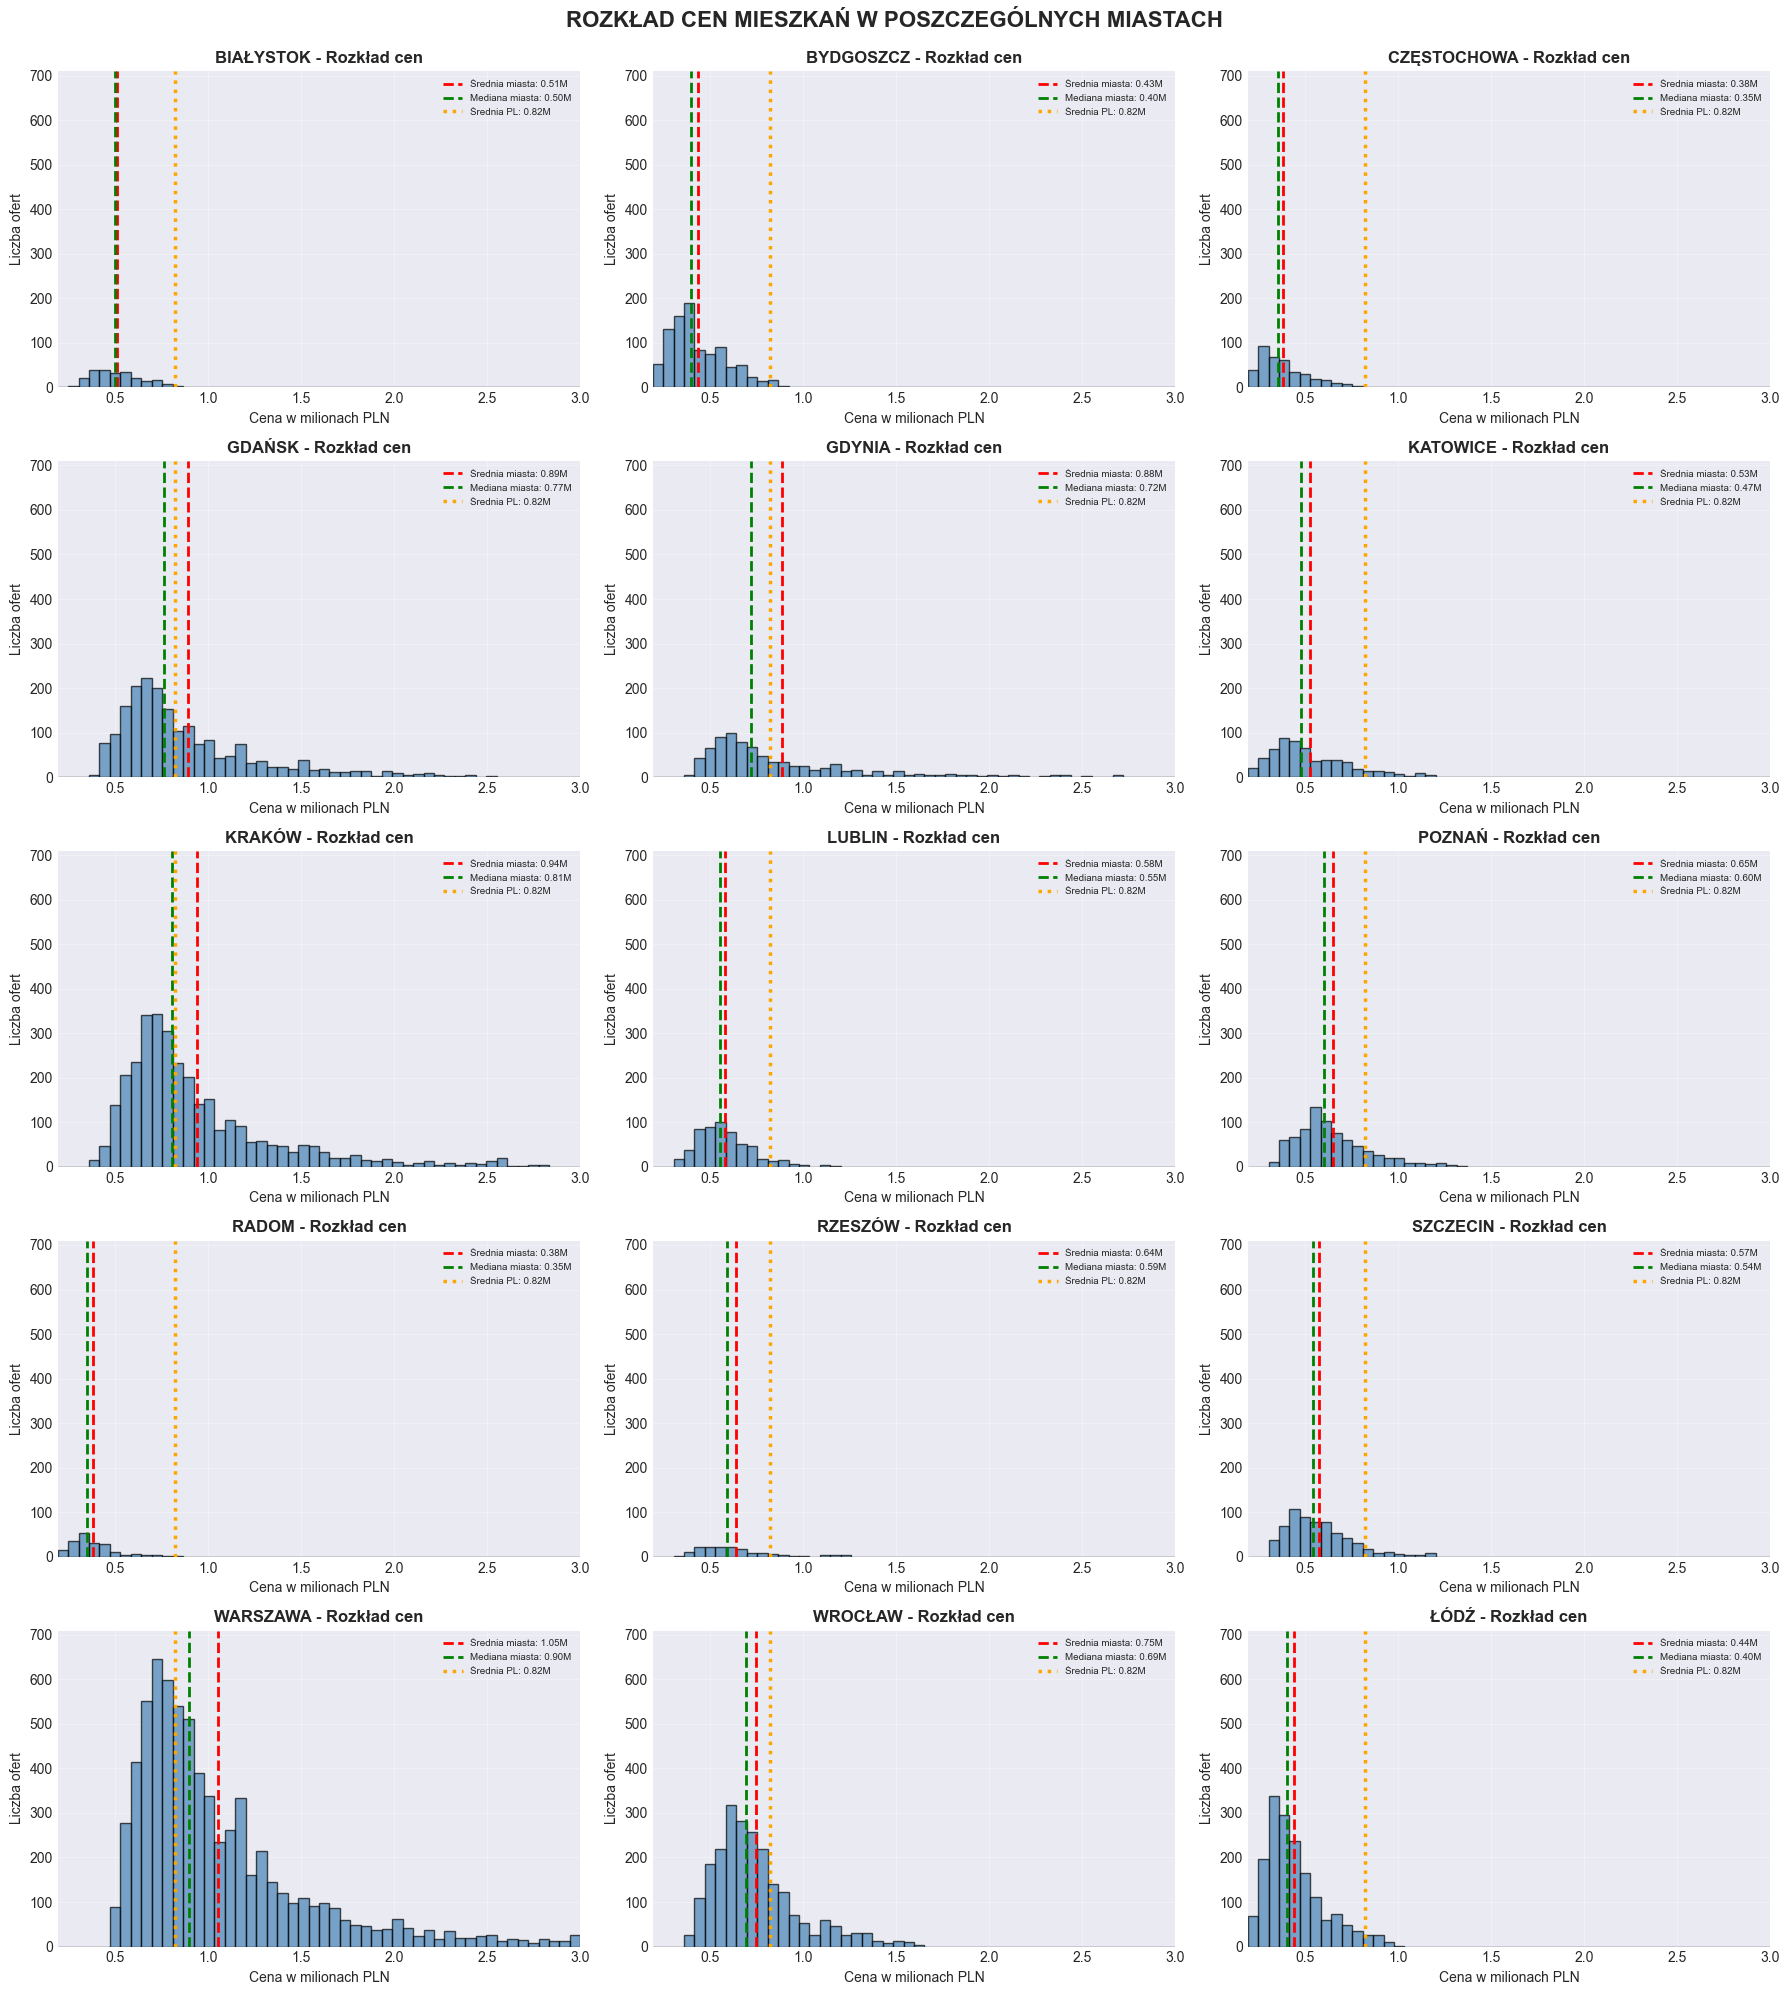


✅ Histogramy cen wygenerowane!


In [87]:
# ========================================
# CZĘŚĆ 2: ANALIZA CENOWA - HISTOGRAMY
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# Lista wszystkich miast
cities = df['miasto'].unique()
n_cities = len(cities)

# ========================================
# 2.1 HISTOGRAMY CENY - KAŻDE MIASTO OSOBNO
# ========================================

# Obliczamy globalną średnią dla wszystkich miast
global_mean_price = df['cena'].mean()
global_median_price = df['cena'].median()

# Ustalamy wspólną skalę osi X i Y
x_min, x_max = df['cena'].min(), df['cena'].max()

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

# Funkcja formatująca oś X w milionach
def millions_formatter(x, pos):
    return f'{x/1e6:.1f}'

# Najpierw liczymy maksymalną liczbę ofert dla ujednolicenia osi Y
max_count = 0
for city in cities:
    city_data = df[df['miasto'] == city]['cena']
    counts, _ = np.histogram(city_data, bins=50, range=(x_min, x_max))
    max_count = max(max_count, counts.max())

for idx, city in enumerate(sorted(cities)):
    city_data = df[df['miasto'] == city]['cena']
    
    axes[idx].hist(city_data, bins=50, range=(x_min, x_max), edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{city.upper()} - Rozkład cen', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Cena w milionach PLN', fontsize=10)
    axes[idx].set_ylabel('Liczba ofert', fontsize=10)
    
    # Formatowanie osi X w milionach
    axes[idx].xaxis.set_major_formatter(FuncFormatter(millions_formatter))
    
    # Ustawiamy wspólną skalę
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].set_ylim(0, max_count * 1.1)
    
    # Dodajemy statystyki dla danego miasta
    mean_price = city_data.mean()
    median_price = city_data.median()
    
    axes[idx].axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Średnia miasta: {mean_price/1e6:.2f}M')
    axes[idx].axvline(median_price, color='green', linestyle='--', linewidth=2, label=f'Mediana miasta: {median_price/1e6:.2f}M')
    
    # Dodajemy globalną średnią wszystkich miast
    axes[idx].axvline(global_mean_price, color='orange', linestyle=':', linewidth=2.5, label=f'Średnia PL: {global_mean_price/1e6:.2f}M')
    
    axes[idx].legend(fontsize=7, loc='upper right')
    axes[idx].grid(True, alpha=0.3)

# Ukrywamy puste subploty (jeśli liczba miast < 15)
for idx in range(n_cities, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ROZKŁAD CEN MIESZKAŃ W POSZCZEGÓLNYCH MIASTACH', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✅ Histogramy cen wygenerowane!")
print("="*60)

Histogramy cen mieszkań są prawo skosńe, zgodnie z oczekiwaniami. Miasta takie jak Warszawa, Kraków, Gdańsk i Gdynia mają wysoki rozstęp cen mieszkań, ale Gdańsk oraz Gdynia mają widocznie wyższą kurtozę, są to również wszystkie miasta których średnia cena mieszkań jest wyższa niż średnia cena dla całej Polski. Miasa o najbardziej równomiernym rozkładzie cen mieszkań to Białystok i Rzeszów, jednakże, może być to efekt niskiej liczbie obserwacji.

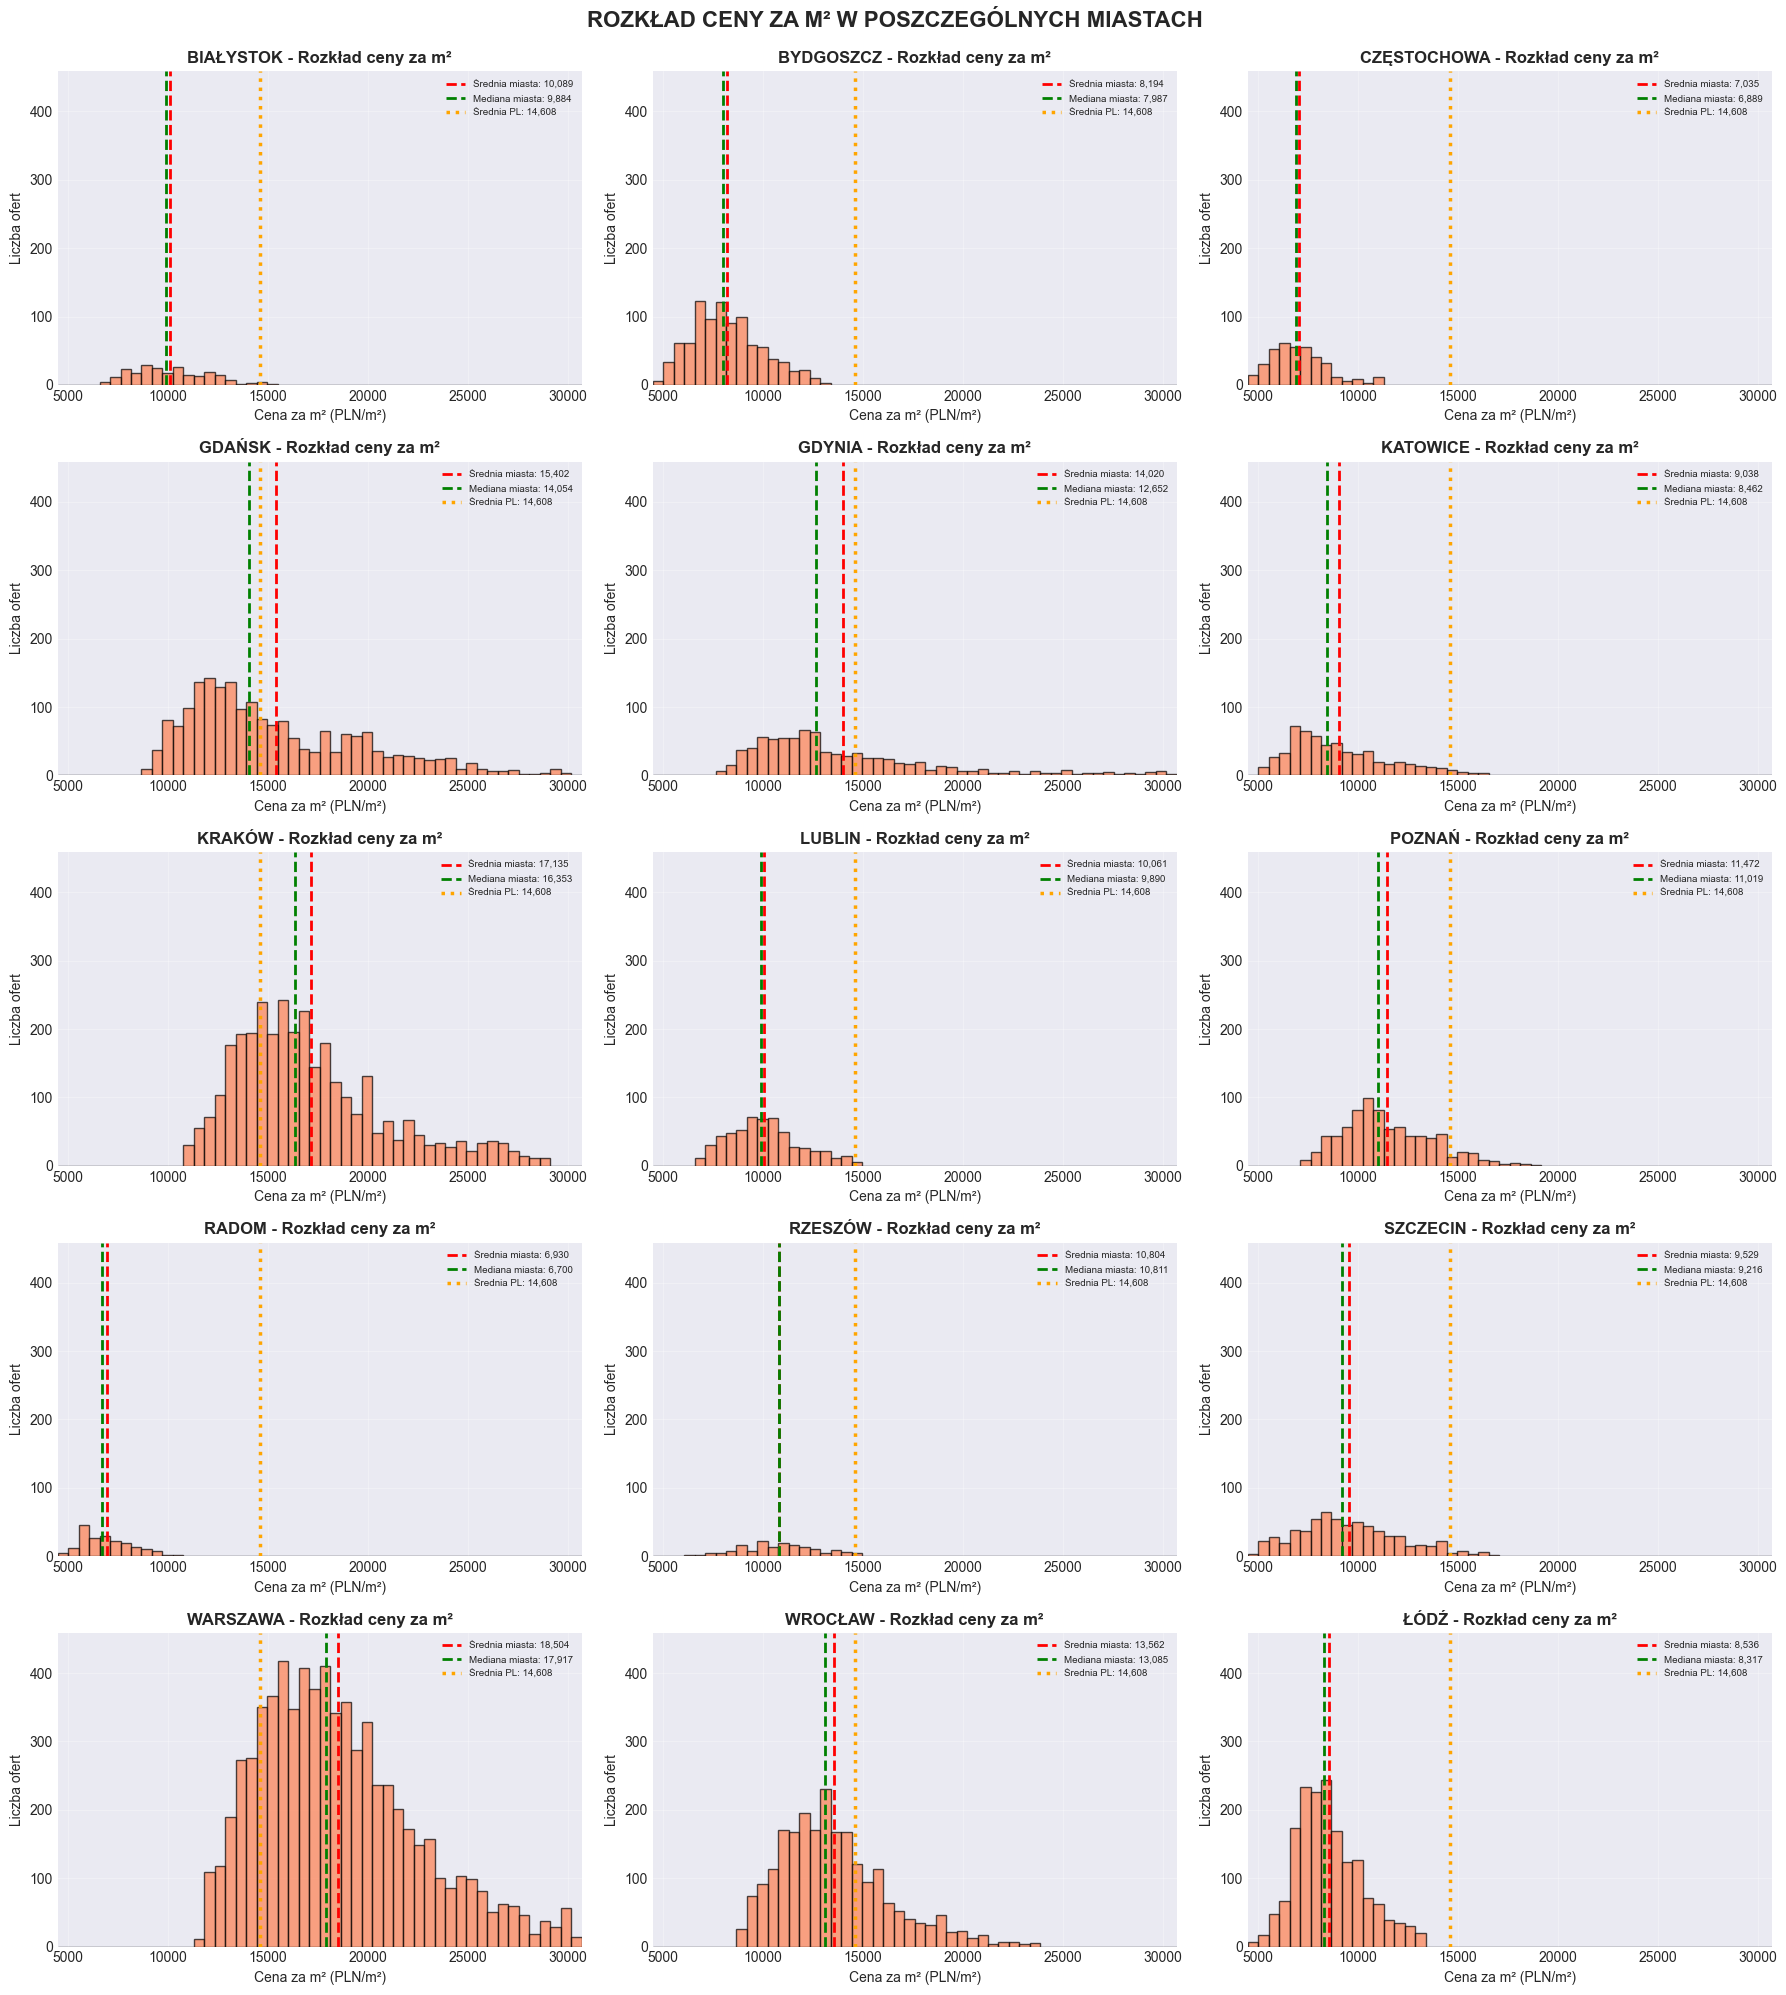


✅ Histogramy ceny za m² wygenerowane!


In [88]:
# ========================================
# CZĘŚĆ 2b: ANALIZA CENY ZA M² - HISTOGRAMY
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tworzymy kolumnę cena_za_m2 jeśli jeszcze nie istnieje
if 'cena_za_m2' not in df.columns:
    df['cena_za_m2'] = df['cena'] / df['metraż']

# Lista wszystkich miast
cities = df['miasto'].unique()
n_cities = len(cities)

# ========================================
# 2.2 HISTOGRAMY CENY ZA M² - KAŻDE MIASTO OSOBNO
# ========================================

# Obliczamy globalną średnią dla wszystkich miast
global_mean_m2 = df['cena_za_m2'].mean()
global_median_m2 = df['cena_za_m2'].median()

# Ustalamy wspólną skalę osi X i Y
x_min, x_max = df['cena_za_m2'].min(), df['cena_za_m2'].max()

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

# Najpierw liczymy maksymalną liczbę ofert dla ujednolicenia osi Y
max_count = 0
for city in cities:
    city_data = df[df['miasto'] == city]['cena_za_m2']
    counts, _ = np.histogram(city_data, bins=50, range=(x_min, x_max))
    max_count = max(max_count, counts.max())

for idx, city in enumerate(sorted(cities)):
    city_data = df[df['miasto'] == city]['cena_za_m2']
    
    axes[idx].hist(city_data, bins=50, range=(x_min, x_max), edgecolor='black', alpha=0.7, color='coral')
    axes[idx].set_title(f'{city.upper()} - Rozkład ceny za m²', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Cena za m² (PLN/m²)', fontsize=10)
    axes[idx].set_ylabel('Liczba ofert', fontsize=10)
    
    # Ustawiamy wspólną skalę
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].set_ylim(0, max_count * 1.1)
    
    # Dodajemy statystyki dla danego miasta
    mean_price = city_data.mean()
    median_price = city_data.median()
    
    axes[idx].axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Średnia miasta: {mean_price:,.0f}')
    axes[idx].axvline(median_price, color='green', linestyle='--', linewidth=2, label=f'Mediana miasta: {median_price:,.0f}')
    
    # Dodajemy globalną średnią wszystkich miast
    axes[idx].axvline(global_mean_m2, color='orange', linestyle=':', linewidth=2.5, label=f'Średnia PL: {global_mean_m2:,.0f}')
    
    axes[idx].legend(fontsize=7, loc='upper right')
    axes[idx].grid(True, alpha=0.3)

# Ukrywamy puste subploty
for idx in range(n_cities, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ROZKŁAD CENY ZA M² W POSZCZEGÓLNYCH MIASTACH', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✅ Histogramy ceny za m² wygenerowane!")
print("="*60)

Analiza cen za metr kwadratowy pokazuje, że jedynie Warszawa, Kraków oraz Gdańsk przekraczają średnią wyliczoną dla całego kraju. Miasta takie jak Gdynia i Wrocław oscylują nieco poniżej tego poziomu, natomiast pozostałe ośrodki charakteryzują się znacznie niższymi cenami. Za miasta o stosunkowo równomiernym rozkładzie cen jednostkowych uznajemy Białystok, Częstochowę, Lublin, Rzeszów oraz Szczecin. Najtańszymi lokalizacjami w naszym zestawieniu są Radom oraz Częstochowa, gdzie średnia cena całkowita mieszkania nie przekracza 400 000 PLN. Tytuł najtańszego dużego miasta w Polsce przypada Łodzi, w której średni koszt zakupu lokalu wynosi około 440 000 PLN. Z kolei za najdroższe mniejsze miasto uznajemy Rzeszów, gdzie średnia cena mieszkania jest niemal równa tej w Poznaniu i wynosi prawie 600 000 PLN.

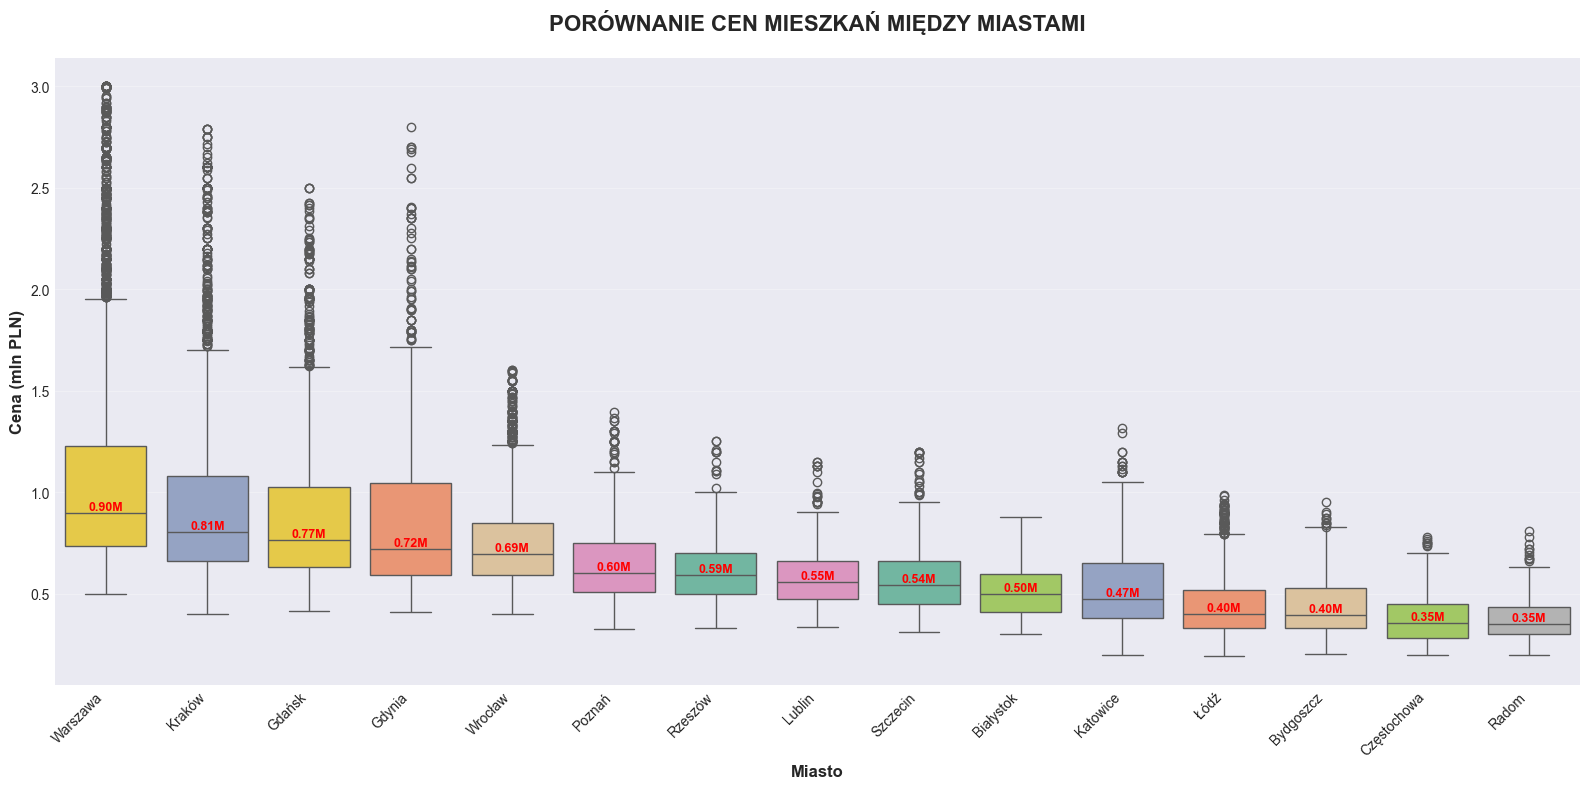

STATYSTYKI CEN MIESZKAŃ W MILIONACH PLN
             Średnia  Mediana   Min   Max  Odch. std.
miasto                                               
Warszawa        1.05     0.90  0.50  3.00        0.47
Kraków          0.94     0.80  0.40  2.79        0.43
Gdańsk          0.89     0.76  0.42  2.50        0.39
Gdynia          0.88     0.72  0.41  2.80        0.45
Wrocław         0.75     0.70  0.40  1.60        0.23
Poznań          0.65     0.60  0.32  1.40        0.20
Rzeszów         0.64     0.59  0.33  1.25        0.20
Lublin          0.58     0.55  0.34  1.15        0.15
Szczecin        0.57     0.54  0.31  1.20        0.17
Białystok       0.51     0.50  0.30  0.88        0.13
Katowice        0.53     0.48  0.20  1.32        0.21
Bydgoszcz       0.43     0.40  0.20  0.95        0.15
Łódź            0.44     0.40  0.19  0.99        0.16
Częstochowa     0.38     0.36  0.20  0.78        0.13
Radom           0.38     0.35  0.20  0.81        0.12

* Wszystkie wartości podane w milionach P

In [89]:
# ========================================
# CZĘŚĆ 3: PORÓWNANIE CEN MIĘDZY MIASTAMI - BOXPLOTY
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# ========================================
# 3.1 BOXPLOT - PORÓWNANIE CEN MIĘDZY MIASTAMI
# ========================================

# Sortujemy miasta według mediany ceny
city_medians = df.groupby('miasto')['cena'].median().sort_values(ascending=False)
sorted_cities = city_medians.index.tolist()

# Funkcja formatująca oś Y w milionach
def millions_formatter(x, pos):
    return f'{x/1e6:.1f}'

plt.figure(figsize=(16, 8))
ax = sns.boxplot(data=df, x='miasto', y='cena', order=sorted_cities, hue='miasto', palette='Set2', legend=False)
plt.title('PORÓWNANIE CEN MIESZKAŃ MIĘDZY MIASTAMI', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Miasto', fontsize=12, fontweight='bold')
plt.ylabel('Cena (mln PLN)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Formatowanie osi Y w milionach
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

# Dodajemy medianę na wykresie
for i, city in enumerate(sorted_cities):
    median_val = city_medians[city]
    plt.text(i, median_val, f'{median_val/1e6:.2f}M', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Wyświetlamy statystyki W MILIONACH
print("="*60)
print("STATYSTYKI CEN MIESZKAŃ W MILIONACH PLN")
print("="*60)

price_stats = df.groupby('miasto')['cena'].agg([
    ('Średnia', 'mean'),
    ('Mediana', 'median'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Odch. std.', 'std')
])

# Konwersja do milionów
price_stats_millions = (price_stats / 1e6).round(2)

# Sortowanie według mediany
price_stats_millions = price_stats_millions.sort_values('Mediana', ascending=False)

print(price_stats_millions)
print("\n* Wszystkie wartości podane w milionach PLN (mln)")

print("\n✅ Boxplot porównawczy cen wygenerowany!")
print("="*60)

Prezentowane przez nas wykresy pudełkowe obrazują wyraźną hierarchię cenową na polskim rynku nieruchomości, gdzie Warszawa jako jedyne miasto osiąga średnią cenę powyżej miliona złotych. Zauważamy, że w miastach takich jak Warszawa, Kraków, Gdańsk oraz Gdynia rozstęp między ceną minimalną a maksymalną jest najszerszy. Sygnalizuje to ogromne zróżnicowanie standardu ofert, od lokali budżetowych po apartamenty premium kosztujące blisko 3 miliony PLN. Mediany cen w większości miast są niższe od średnich, co potwierdza asymetrię rozkładu i obecność luksusowych nieruchomości zawyżających wyniki ogólne. Na przeciwnym biegunie znajdują się Częstochowa oraz Radom, gdzie rynki są znacznie bardziej skonsolidowane. Odchylenie standardowe jest tam najniższe, co świadczy o większej przewidywalności i mniejszym zróżnicowaniu cenowym ofert w tych lokalizacjach.

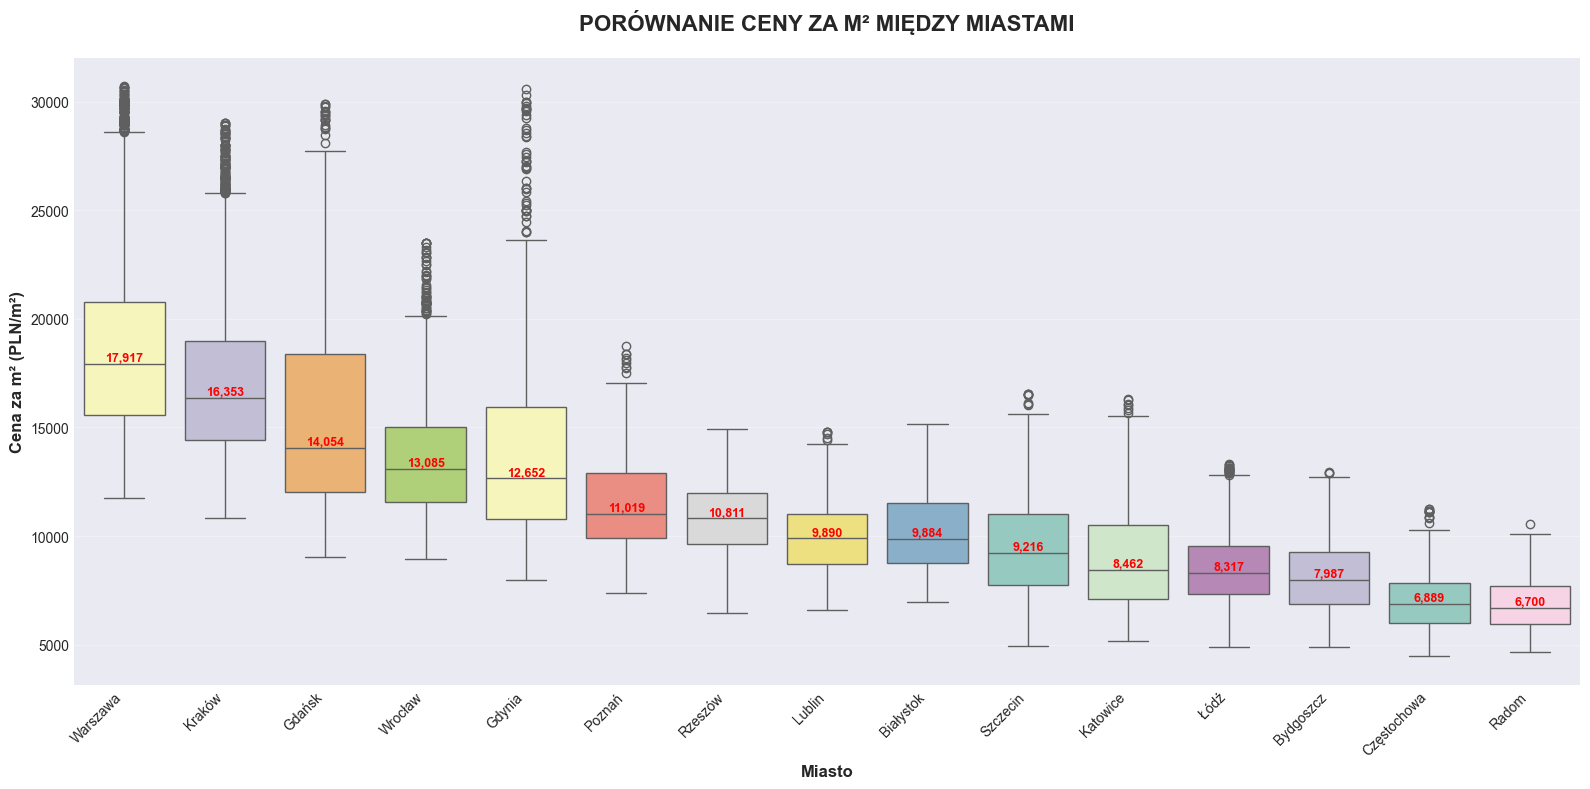

STATYSTYKI CENY ZA M² W MIASTACH W PLN
             Średnia  Mediana      Min      Max  Odch. std.
miasto                                                     
Warszawa     18504.0  17917.0  11760.0  30703.0      3926.0
Kraków       17135.0  16353.0  10833.0  29000.0      3789.0
Gdańsk       15402.0  14054.0   9036.0  29893.0      4374.0
Wrocław      13562.0  13085.0   8925.0  23500.0      2742.0
Gdynia       14020.0  12652.0   7990.0  30571.0      4657.0
Poznań       11472.0  11019.0   7403.0  18750.0      2210.0
Rzeszów      10804.0  10811.0   6476.0  14912.0      1882.0
Lublin       10061.0   9890.0   6611.0  14803.0      1780.0
Białystok    10089.0   9884.0   6991.0  15149.0      1838.0
Szczecin      9529.0   9216.0   4927.0  16542.0      2515.0
Katowice      9038.0   8462.0   5190.0  16324.0      2461.0
Łódź          8536.0   8317.0   4906.0  13328.0      1653.0
Bydgoszcz     8194.0   7987.0   4883.0  12940.0      1736.0
Częstochowa   7035.0   6889.0   4472.0  11264.0      1403.0
R

In [90]:
# ========================================
# CZĘŚĆ 3b: PORÓWNANIE CENY ZA M² MIĘDZY MIASTAMI
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Tworzymy kolumnę cena_za_m2 jeśli jeszcze nie istnieje
if 'cena_za_m2' not in df.columns:
    df['cena_za_m2'] = df['cena'] / df['metraż']

# Sortujemy miasta według mediany ceny za m²
city_medians_m2 = df.groupby('miasto')['cena_za_m2'].median().sort_values(ascending=False)
sorted_cities_m2 = city_medians_m2.index.tolist()

plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='miasto', y='cena_za_m2', order=sorted_cities_m2, hue='miasto', palette='Set3', legend=False)
plt.title('PORÓWNANIE CENY ZA M² MIĘDZY MIASTAMI', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Miasto', fontsize=12, fontweight='bold')
plt.ylabel('Cena za m² (PLN/m²)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Dodajemy medianę na wykresie
for i, city in enumerate(sorted_cities_m2):
    median_val = city_medians_m2[city]
    plt.text(i, median_val, f'{median_val:,.0f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Wyświetlamy statystyki
print("="*60)
print("STATYSTYKI CENY ZA M² W MIASTACH W PLN")
print("="*60)

price_m2_stats = df.groupby('miasto')['cena_za_m2'].agg([
    ('Średnia', 'mean'),
    ('Mediana', 'median'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Odch. std.', 'std')
]).round(0)

price_m2_stats = price_m2_stats.sort_values('Mediana', ascending=False)
print(price_m2_stats)

print("\n✅ Boxplot porównawczy ceny za m² wygenerowany!")
print("="*60)

Przeprowadzona przez nas analiza różnic regionalnych wykazała istotną statystycznie przewagę średnich cen na wschodzie kraju, co wynika głównie z dominującej pozycji Warszawy, gdzie różnice względem miast takich jak Radom czy Częstochowa przekraczają 11 000 PLN/m². Na podstawie podziału zbioru na tercyle ustaliliśmy, że najwyższą cenę jednostkową generują mieszkania małe (do 46,51 m²), natomiast testy Shapiro-Wilka i D'Agostino-Pearsona jednoznacznie potwierdziły, że rozkład cen nie jest normalny i wykazuje silną skośność prawostronną. Dodatkowo test chi-kwadrat wykazał istotne różnice w wyposażeniu budynków w windy w zależności od typu zabudowy, przy czym statystyki miast potwierdzają ogromny dystans cenowy między stolicą a ośrodkami regionalnymi.

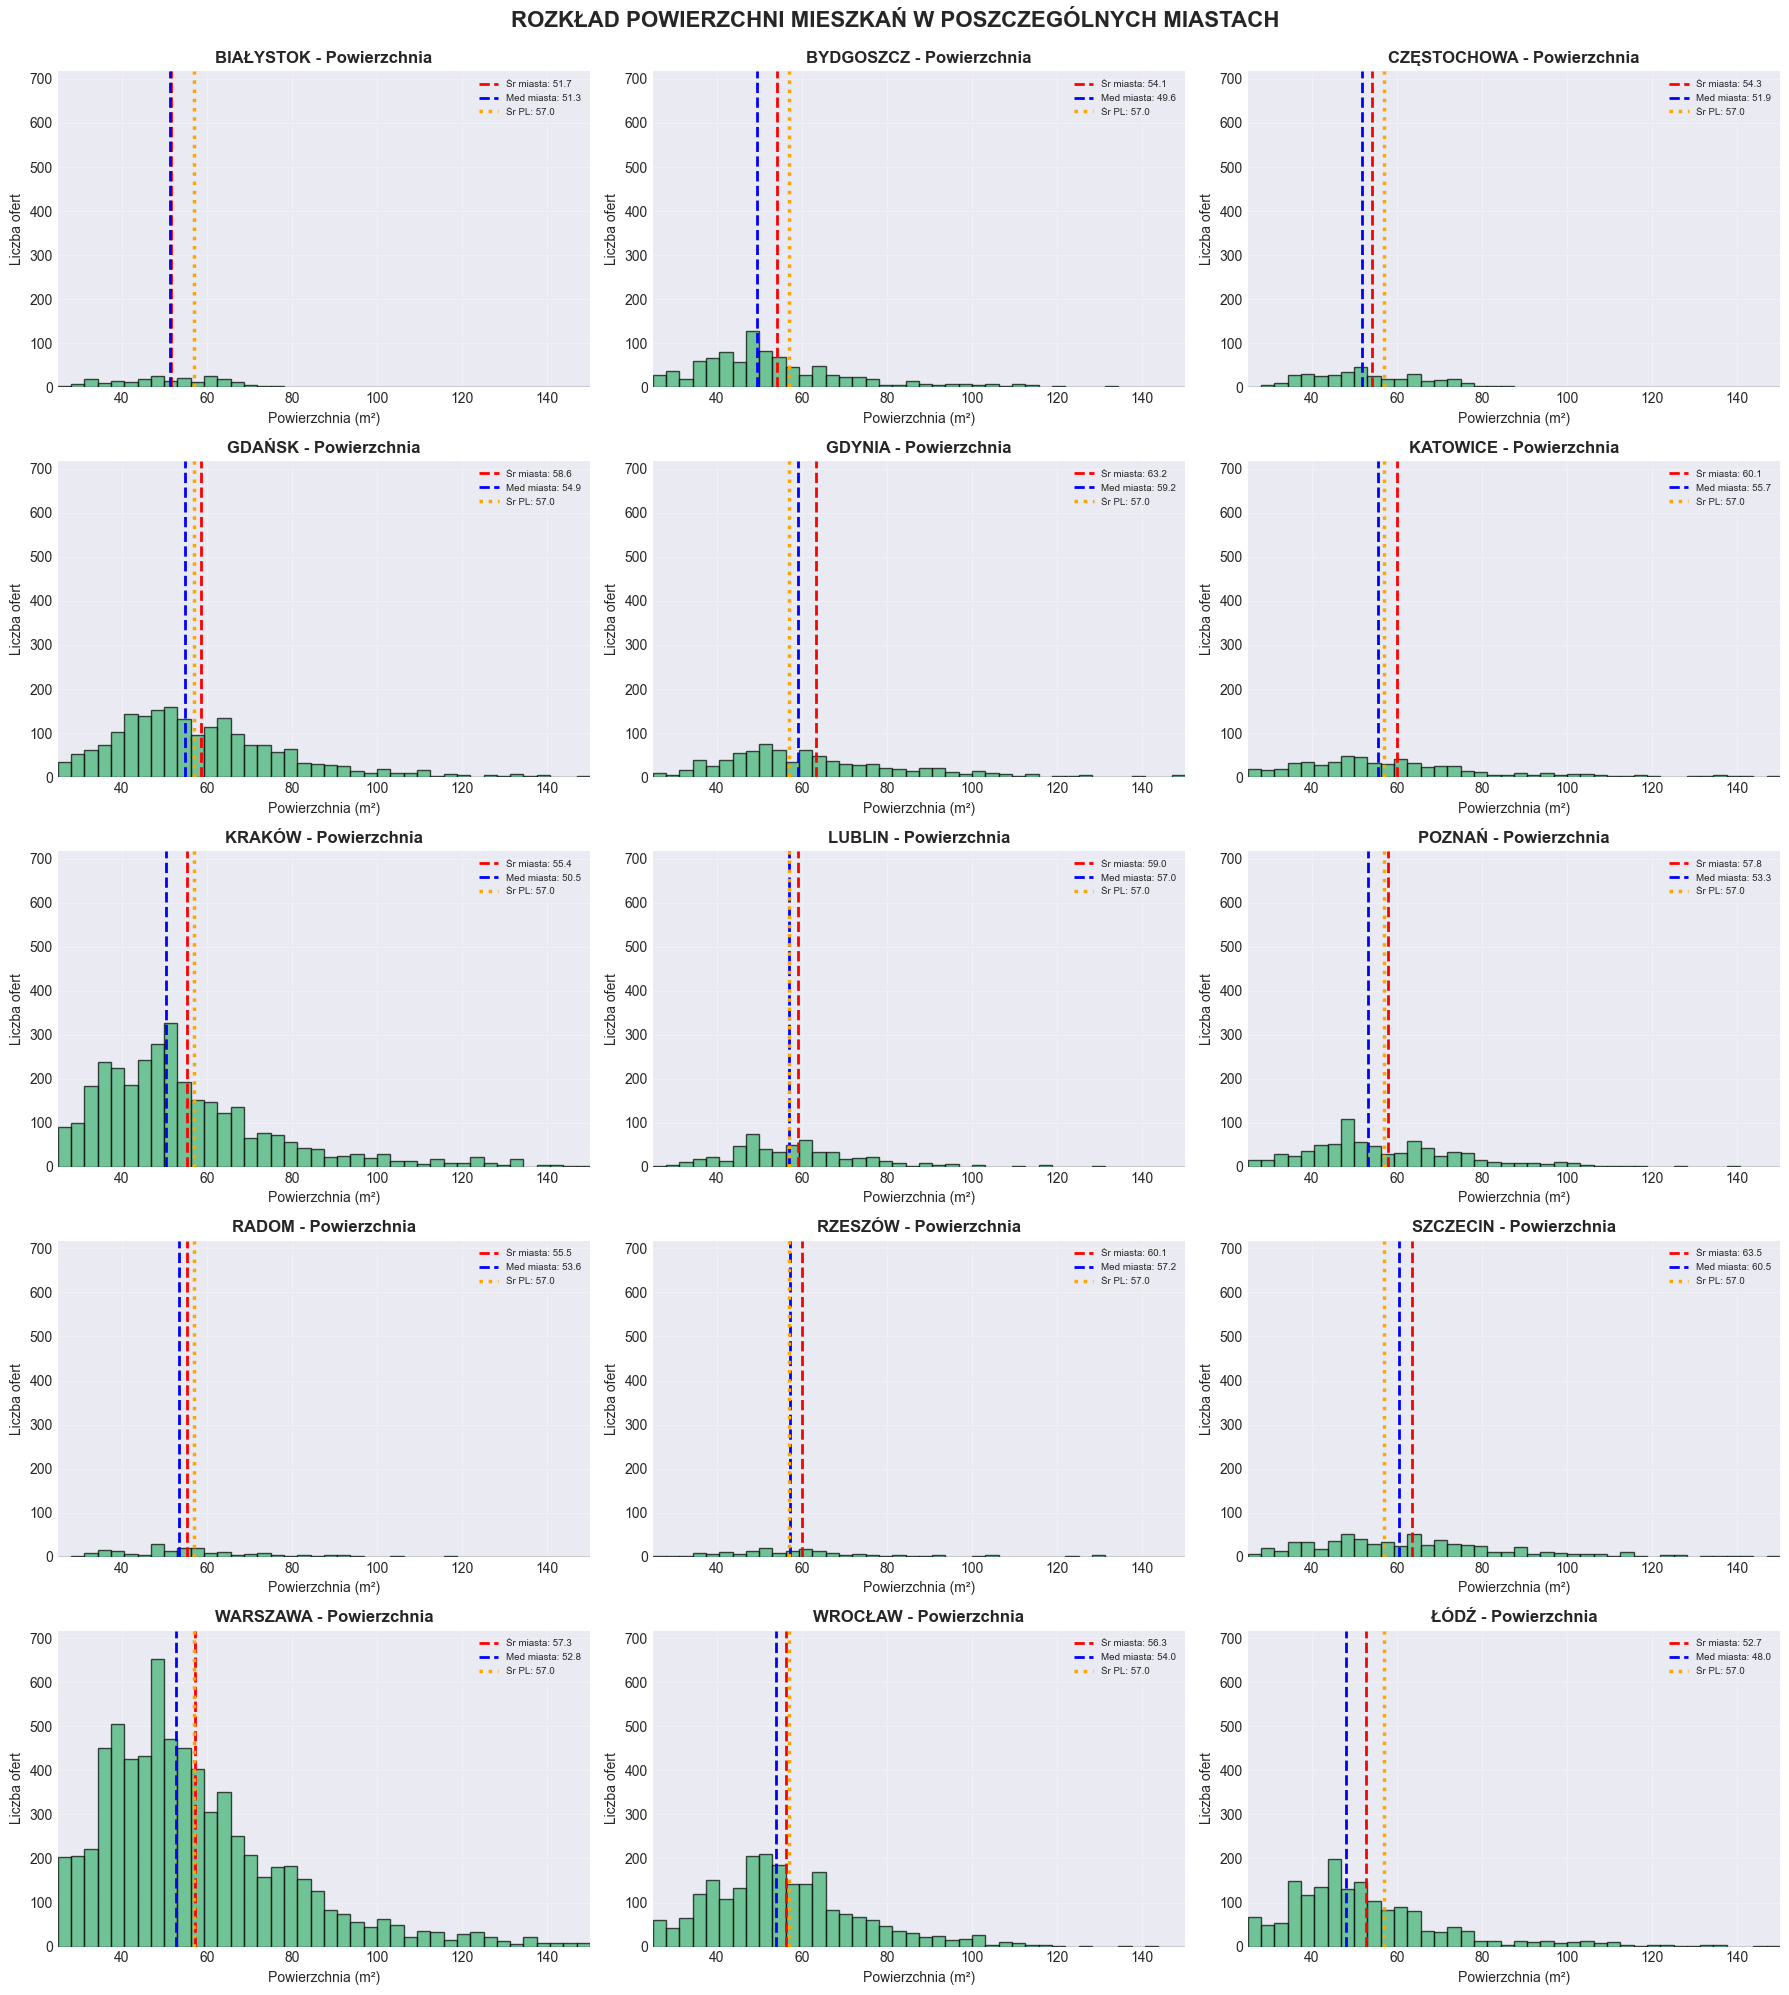

In [91]:
# ========================================
# CZĘŚĆ 4: HISTOGRAMY POZOSTAŁYCH ZMIENNYCH
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cities = sorted(df['miasto'].unique())
n_cities = len(cities)

# ========================================
# 4.1 POWIERZCHNIA (metraż)
# ========================================

# Obliczamy globalną średnią
global_mean_sqm = df['metraż'].mean()
global_median_sqm = df['metraż'].median()

# Ustalamy wspólną skalę
x_min, x_max = df['metraż'].min(), df['metraż'].max()

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

# Liczymy maksymalną liczbę dla osi Y
max_count = 0
for city in cities:
    city_data = df[df['miasto'] == city]['metraż']
    counts, _ = np.histogram(city_data, bins=40, range=(x_min, x_max))
    max_count = max(max_count, counts.max())

for idx, city in enumerate(cities):
    city_data = df[df['miasto'] == city]['metraż']
    
    axes[idx].hist(city_data, bins=40, range=(x_min, x_max), edgecolor='black', alpha=0.7, color='mediumseagreen')
    axes[idx].set_title(f'{city.upper()} - Powierzchnia', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Powierzchnia (m²)', fontsize=10)
    axes[idx].set_ylabel('Liczba ofert', fontsize=10)
    
    # Wspólna skala
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].set_ylim(0, max_count * 1.1)
    
    mean_val = city_data.mean()
    median_val = city_data.median()
    
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Śr miasta: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Med miasta: {median_val:.1f}')
    axes[idx].axvline(global_mean_sqm, color='orange', linestyle=':', linewidth=2.5, label=f'Śr PL: {global_mean_sqm:.1f}')
    
    axes[idx].legend(fontsize=7, loc='upper right')
    axes[idx].grid(True, alpha=0.3)

for idx in range(n_cities, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ROZKŁAD POWIERZCHNI MIESZKAŃ W POSZCZEGÓLNYCH MIASTACH', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


Analiza powierzchni mieszkań w Polsce ukazuje, że średnia wielkość lokalu w całym zbiorze danych wynosi 57 m². Zauważamy wyraźną prawoskośność rozkładów w największych metropoliach, takich jak Warszawa, Kraków oraz Łódź, co wynika z obecności nielicznych, bardzo dużych apartamentów przy jednoczesnej dominacji mniejszych metraży. Miastem o najniższej wartości mediany jest Łódź, w której środkowa wartość zbioru wskazuje na mieszkanie o powierzchni zaledwie 48 m². Na drugim biegunie znajduje się Szczecin, który określamy jako miasto o średnio największych lokalach, gdzie przeciętna powierzchnia mieszkania wynosi niemal 70 m².

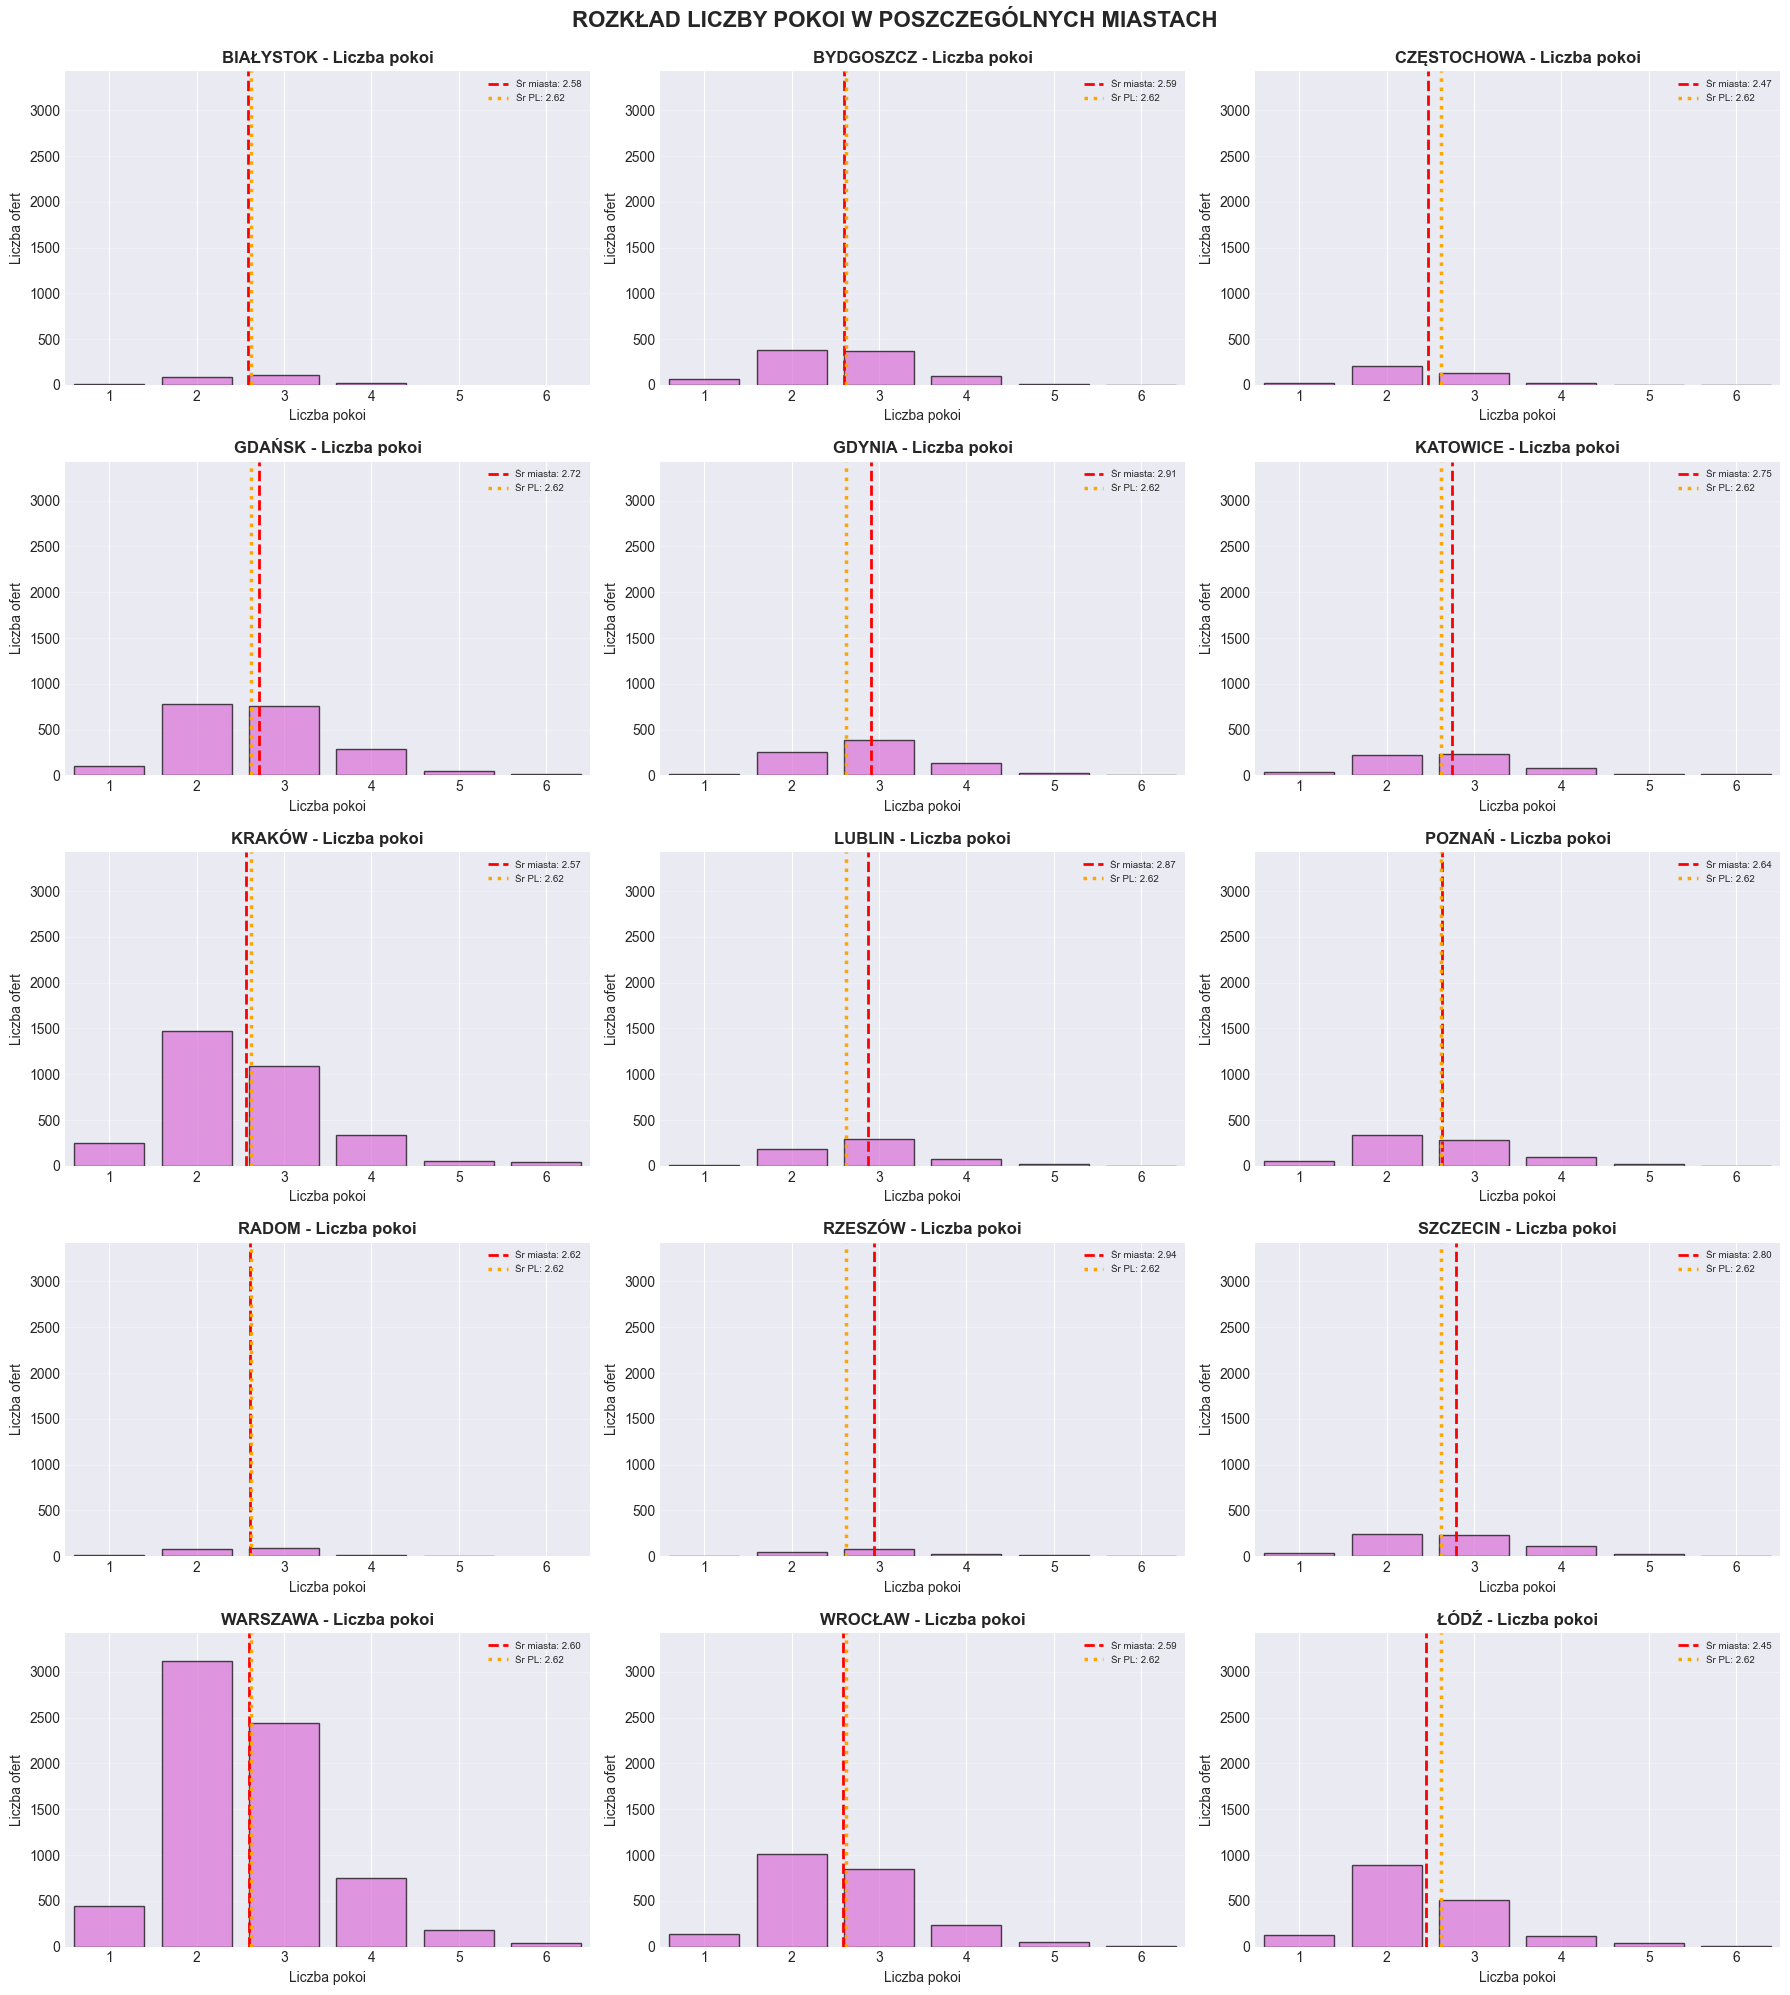

In [92]:
# ========================================
# CZĘŚĆ 4b: LICZBA POKOI
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cities = sorted(df['miasto'].unique())
n_cities = len(cities)

# Obliczamy globalną średnią
global_mean_rooms = df['liczba_pokoi'].mean()

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

# Ustalamy wspólny zakres dla osi X i Y
x_min, x_max = df['liczba_pokoi'].min(), df['liczba_pokoi'].max()

# Liczymy maksymalną liczbę dla osi Y
max_count = 0
for city in cities:
    city_data = df[df['miasto'] == city]['liczba_pokoi']
    room_counts = city_data.value_counts()
    max_count = max(max_count, room_counts.max())

for idx, city in enumerate(cities):
    city_data = df[df['miasto'] == city]['liczba_pokoi']
    
    # Zliczamy liczbę pokoi
    room_counts = city_data.value_counts().sort_index()
    
    axes[idx].bar(room_counts.index, room_counts.values, edgecolor='black', alpha=0.7, color='orchid')
    axes[idx].set_title(f'{city.upper()} - Liczba pokoi', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Liczba pokoi', fontsize=10)
    axes[idx].set_ylabel('Liczba ofert', fontsize=10)
    
    # Wspólna skala
    axes[idx].set_xlim(x_min - 0.5, x_max + 0.5)
    axes[idx].set_ylim(0, max_count * 1.1)
    axes[idx].set_xticks(range(int(x_min), int(x_max) + 1))
    
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Dodajemy średnie
    mean_val = city_data.mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Śr miasta: {mean_val:.2f}')
    axes[idx].axvline(global_mean_rooms, color='orange', linestyle=':', linewidth=2.5, label=f'Śr PL: {global_mean_rooms:.2f}')
    
    axes[idx].legend(fontsize=7, loc='upper right')

for idx in range(n_cities, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ROZKŁAD LICZBY POKOI W POSZCZEGÓLNYCH MIASTACH', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



Analiza rozkładu liczby pokoi w polskich miastach wykazuje niemal całkowity brak ofert lokali 5- i 6-pokojowych w Białymstoku oraz Radomiu. Zauważamy, że średnia liczba pokoi dla całego zbioru danych wynosi 2,62, a większość badanych przez nas miast oscyluje wokół tej wartości. Wyjątkami są Gdynia, Lublin oraz Rzeszów, w których średnia wielkość mieszkania jest wyższa i zbliża się do poziomu 3 pokoi. Za interesujące przypadki uznajemy również Gdańsk oraz Bydgoszcz, ponieważ w tych miastach struktura ofert jest nietypowa i cechuje się niemal identyczną liczbą mieszkań 2- oraz 3-pokojowych.

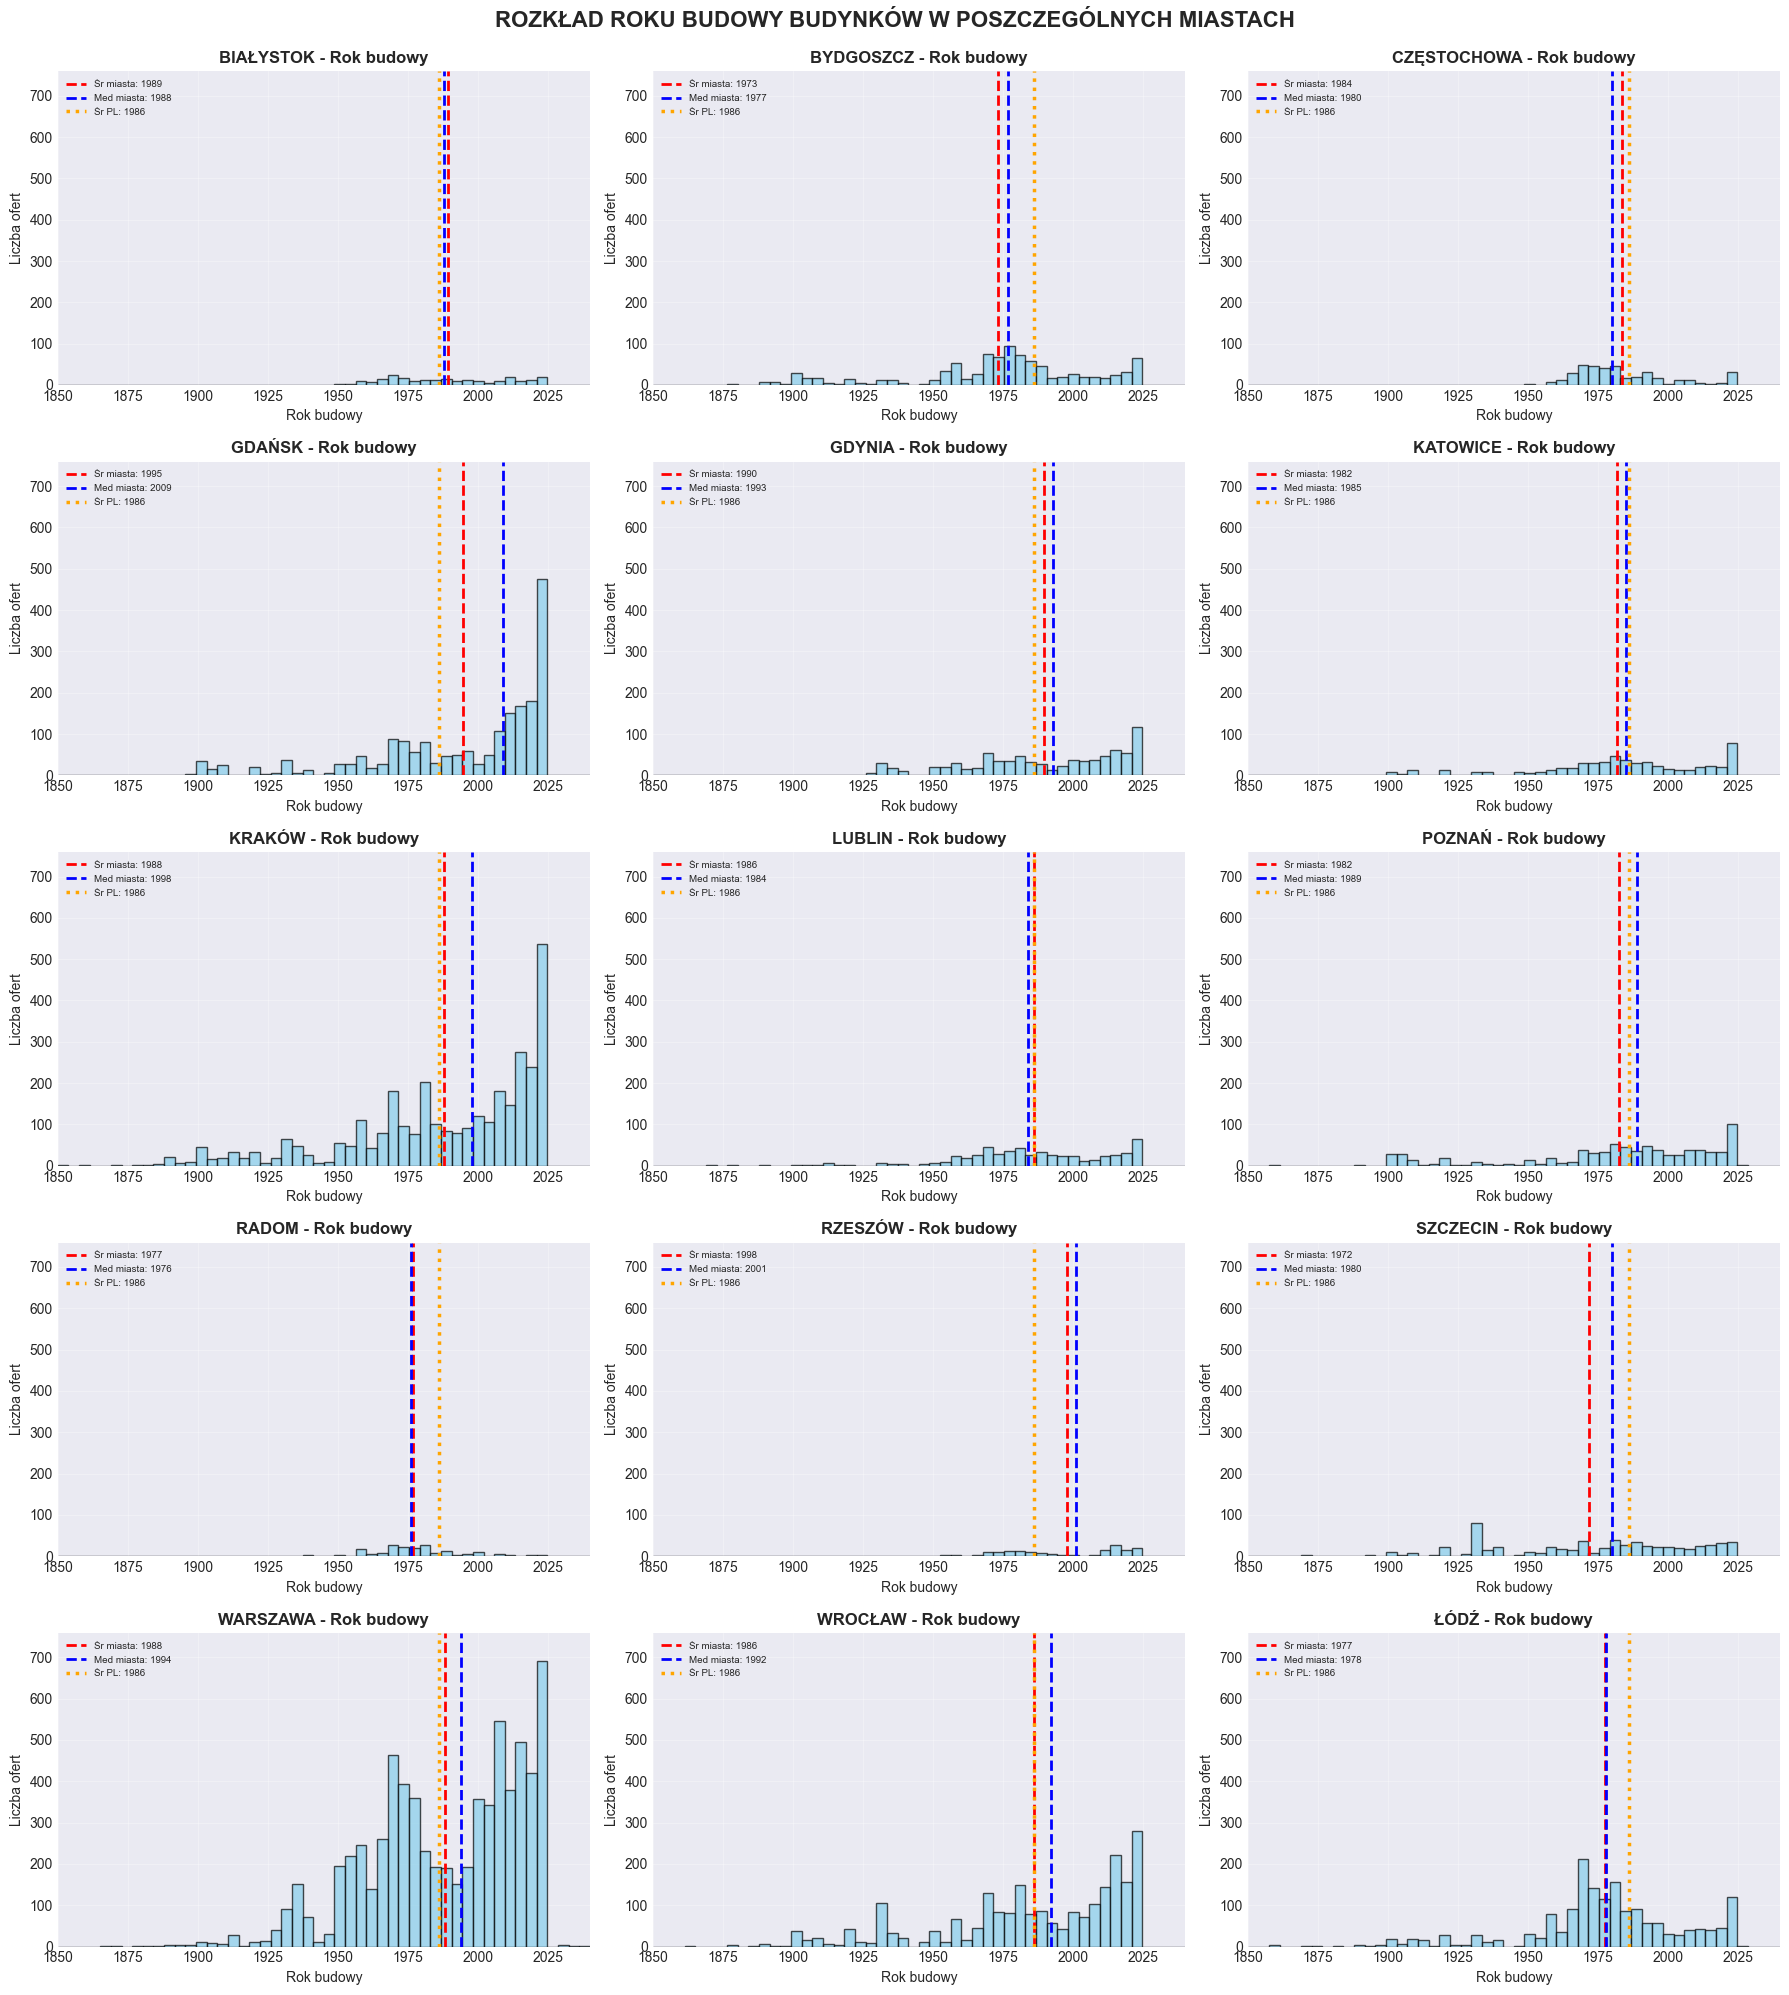

In [93]:
# ========================================
# CZĘŚĆ 4c: ROK BUDOWY
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cities = sorted(df['miasto'].unique())
n_cities = len(cities)

# Obliczamy globalną średnią
global_mean_year = df['rok_budowy'].mean()
global_median_year = df['rok_budowy'].median()

# Ustalamy wspólną skalę
x_min, x_max = df['rok_budowy'].min(), df['rok_budowy'].max()

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

# Liczymy maksymalną liczbę dla osi Y
max_count = 0
for city in cities:
    city_data = df[df['miasto'] == city]['rok_budowy']
    counts, _ = np.histogram(city_data, bins=50, range=(x_min, x_max))
    max_count = max(max_count, counts.max())

for idx, city in enumerate(cities):
    city_data = df[df['miasto'] == city]['rok_budowy']
    
    axes[idx].hist(city_data, bins=50, range=(x_min, x_max), edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'{city.upper()} - Rok budowy', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Rok budowy', fontsize=10)
    axes[idx].set_ylabel('Liczba ofert', fontsize=10)
    
    # Wspólna skala
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].set_ylim(0, max_count * 1.1)
    
    mean_val = city_data.mean()
    median_val = city_data.median()
    
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Śr miasta: {mean_val:.0f}')
    axes[idx].axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Med miasta: {median_val:.0f}')
    axes[idx].axvline(global_mean_year, color='orange', linestyle=':', linewidth=2.5, label=f'Śr PL: {global_mean_year:.0f}')
    
    axes[idx].legend(fontsize=7, loc='upper left')
    axes[idx].grid(True, alpha=0.3)

for idx in range(n_cities, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ROZKŁAD ROKU BUDOWY BUDYNKÓW W POSZCZEGÓLNYCH MIASTACH', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


Analizowane przez nas histogramy roku budowy wykazują wyraźną lewostronną skośność, co potwierdza dynamiczny rozwój rynku i dużą podaż nowych lokali w ostatnich dekadach. Dane te obrazują również historyczne uwarunkowania, w tym zniszczenia wojenne oraz powojenny zastój budowlany, przez co mieszkania z lat 40. XX wieku praktycznie nie występują w zbiorze. Największe ubytki w tkance historycznej dostrzegamy w Warszawie, Krakowie oraz Wrocławiu. Z kolei miastami o najstarszej średniej zabudowie są Szczecin (1972) oraz Bydgoszcz (1973). Na przeciwległym biegunie znajdują się Rzeszów oraz Gdańsk, przy czym ten drugi ośrodek wyróżnia się najwyższą medianą roku budowy wynoszącą 2009. Tak wysoki wynik dla Gdańska wynika z intensywnej rozbudowy miasta w ostatnim pięcioleciu, co znajduje odzwierciedlenie w dużej liczbie ofert z lat 2020–2025.

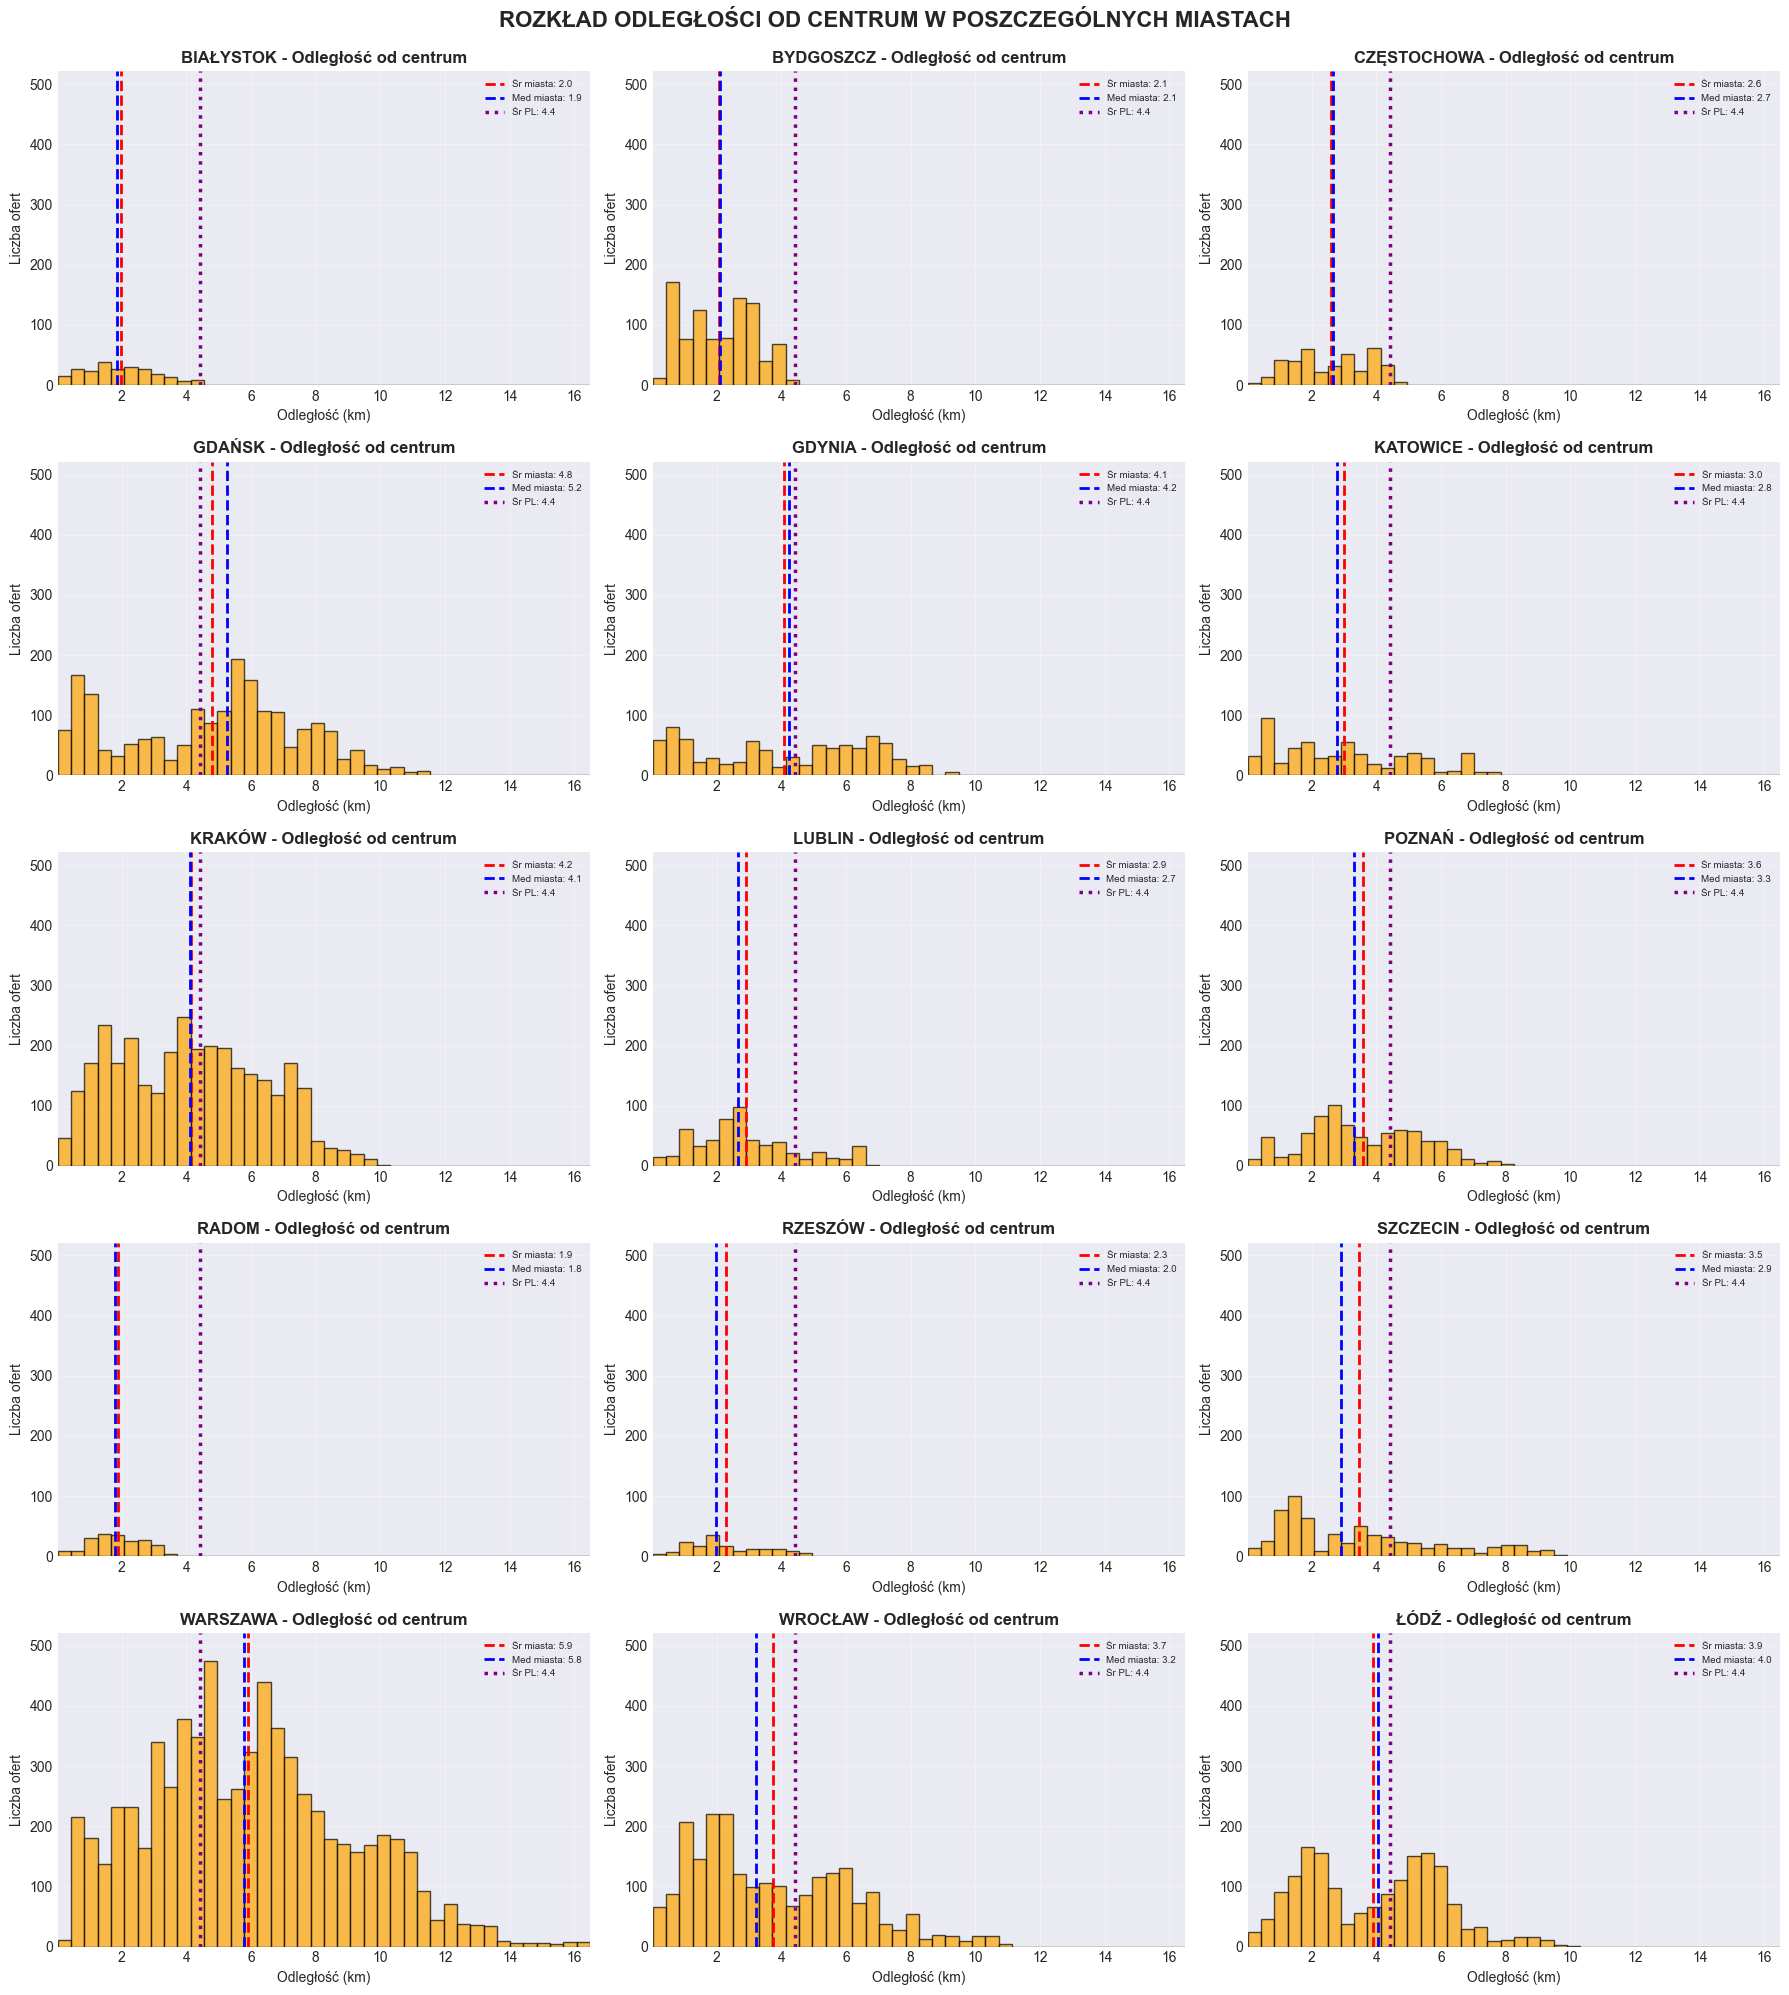

In [94]:
# ========================================
# CZĘŚĆ 4d: ODLEGŁOŚĆ OD CENTRUM
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cities = sorted(df['miasto'].unique())
n_cities = len(cities)

# Obliczamy globalną średnią
global_mean_distance = df['odległość_od_centrum'].mean()
global_median_distance = df['odległość_od_centrum'].median()

# Ustalamy wspólną skalę
x_min, x_max = df['odległość_od_centrum'].min(), df['odległość_od_centrum'].max()

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

# Liczymy maksymalną liczbę dla osi Y
max_count = 0
for city in cities:
    city_data = df[df['miasto'] == city]['odległość_od_centrum']
    counts, _ = np.histogram(city_data, bins=40, range=(x_min, x_max))
    max_count = max(max_count, counts.max())

for idx, city in enumerate(cities):
    city_data = df[df['miasto'] == city]['odległość_od_centrum']
    
    axes[idx].hist(city_data, bins=40, range=(x_min, x_max), edgecolor='black', alpha=0.7, color='orange')
    axes[idx].set_title(f'{city.upper()} - Odległość od centrum', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Odległość (km)', fontsize=10)
    axes[idx].set_ylabel('Liczba ofert', fontsize=10)
    
    # Wspólna skala
    axes[idx].set_xlim(x_min, x_max)
    axes[idx].set_ylim(0, max_count * 1.1)
    
    mean_val = city_data.mean()
    median_val = city_data.median()
    
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Śr miasta: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Med miasta: {median_val:.1f}')
    axes[idx].axvline(global_mean_distance, color='purple', linestyle=':', linewidth=2.5, label=f'Śr PL: {global_mean_distance:.1f}')
    
    axes[idx].legend(fontsize=7, loc='upper right')
    axes[idx].grid(True, alpha=0.3)

for idx in range(n_cities, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ROZKŁAD ODLEGŁOŚCI OD CENTRUM W POSZCZEGÓLNYCH MIASTACH', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



Analiza odległości od centrum pozwala nam wyróżnić trzy typy miast. W pierwszej grupie znajdują się ośrodki takie jak Radom, Białystok, Bydgoszcz, Częstochowa, Rzeszów oraz Lublin, gdzie średni dystans wynosi około 2 km, co jest wartością ponad dwukrotnie mniejszą od średniej dla całego zbioru (4.4 km). Miasta te uznajemy za stosunkowo niewielkie i mocno skoncentrowane wokół centrum. Druga grupa, obejmująca Gdynię, Kraków, Poznań, Wrocław oraz Łódź, oscyluje w okolicy średniej krajowej. Z kolei Warszawa i Gdańsk charakteryzują się najwyższymi wartościami, odpowiednio 5.8 km oraz 4.8 km. W przypadku Gdańska wynik ten wynika ze specyficznej, liniowej budowy miasta oraz faktu, że jego historyczne centrum jest przesunięte względem geograficznego środka ciężkości i głównych punktów biznesowych.

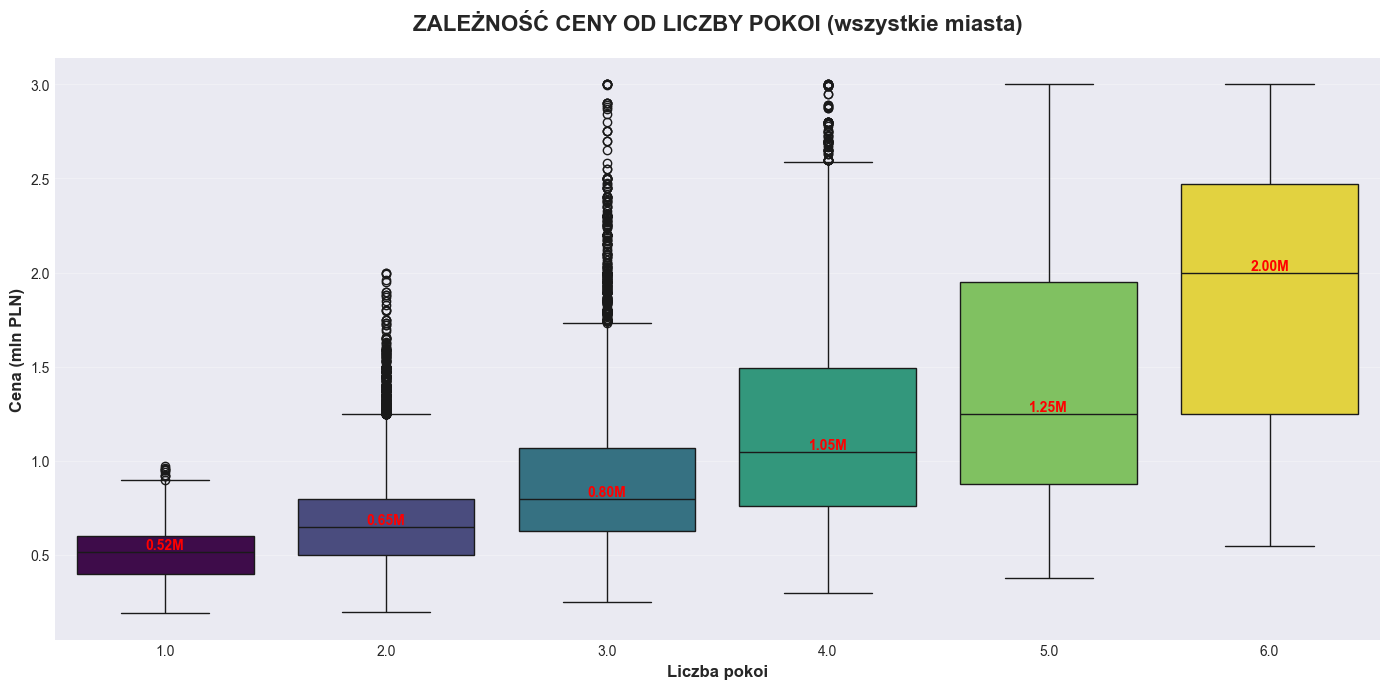

STATYSTYKI CENY WEDŁUG LICZBY POKOI
              Liczba ofert    Średnia    Mediana     Min      Max
liczba_pokoi                                                     
1.0                   1308   504602.0   517000.0  191000   970000
2.0                   9310   671582.0   649000.0  195000  2000000
3.0                   7842   890556.0   799000.0  249000  3000000
4.0                   2404  1187753.0  1049000.0  299000  3000000
5.0                    496  1410322.0  1249000.0  375000  2999000
6.0                    141  1864664.0  1999000.0  550000  3000000


In [95]:
# ========================================
# CZĘŚĆ 5: CENA VS LICZBA POKOI
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# ========================================
# 5.1 BOXPLOT - CENA VS LICZBA POKOI (wszystkie miasta razem)
# ========================================

# Funkcja formatująca oś Y w milionach
def millions_formatter(x, pos):
    return f'{x/1e6:.1f}'

plt.figure(figsize=(14, 7))
ax = sns.boxplot(data=df, x='liczba_pokoi', y='cena', hue='liczba_pokoi', palette='viridis', legend=False)
plt.title('ZALEŻNOŚĆ CENY OD LICZBY POKOI (wszystkie miasta)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Liczba pokoi', fontsize=12, fontweight='bold')
plt.ylabel('Cena (mln PLN)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Formatowanie osi Y w milionach
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

# Dodajemy mediany
room_medians = df.groupby('liczba_pokoi')['cena'].median()
for i, room in enumerate(sorted(df['liczba_pokoi'].unique())):
    median_val = room_medians[room]
    plt.text(i, median_val, f'{median_val/1e6:.2f}M', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Statystyki
print("="*60)
print("STATYSTYKI CENY WEDŁUG LICZBY POKOI")
print("="*60)

room_stats = df.groupby('liczba_pokoi')['cena'].agg([
    ('Liczba ofert', 'count'),
    ('Średnia', 'mean'),
    ('Mediana', 'median'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(0)

print(room_stats)



Analiza statystyk ceny w zależności od liczby pokoi wykazuje wyraźną, niemal liniową zależność wzrostową, gdzie najliczniejszą grupę ofert stanowią mieszkania dwupokojowe (9310 ofert) oraz trzypokojowe (7842 oferty). Zauważamy, że mediana ceny dla lokali sześcipokojowych (1 999 000 PLN) jest niemal czterokrotnie wyższa niż w przypadku mieszkań jednopokojowych, co odzwierciedla wzrost wartości wraz z metrażem i funkcjonalnością. Interesujący jest fakt, że mediana dla mieszkań jednopokojowych jest wyższa od ich średniej, co sugeruje dużą koncentrację ofert w wyższych przedziałach cenowych dla tej grupy, natomiast w pozostałych kategoriach to średnia przewyższa medianę, co potwierdza występowanie ofert luksusowych o bardzo wysokich cenach maksymalnych (do 3 000 000 PLN). Rozpiętość między ceną minimalną a maksymalną rośnie wraz z liczbą pokoi, co wskazuje na coraz większe zróżnicowanie standardu i lokalizacji w segmencie większych nieruchomości.

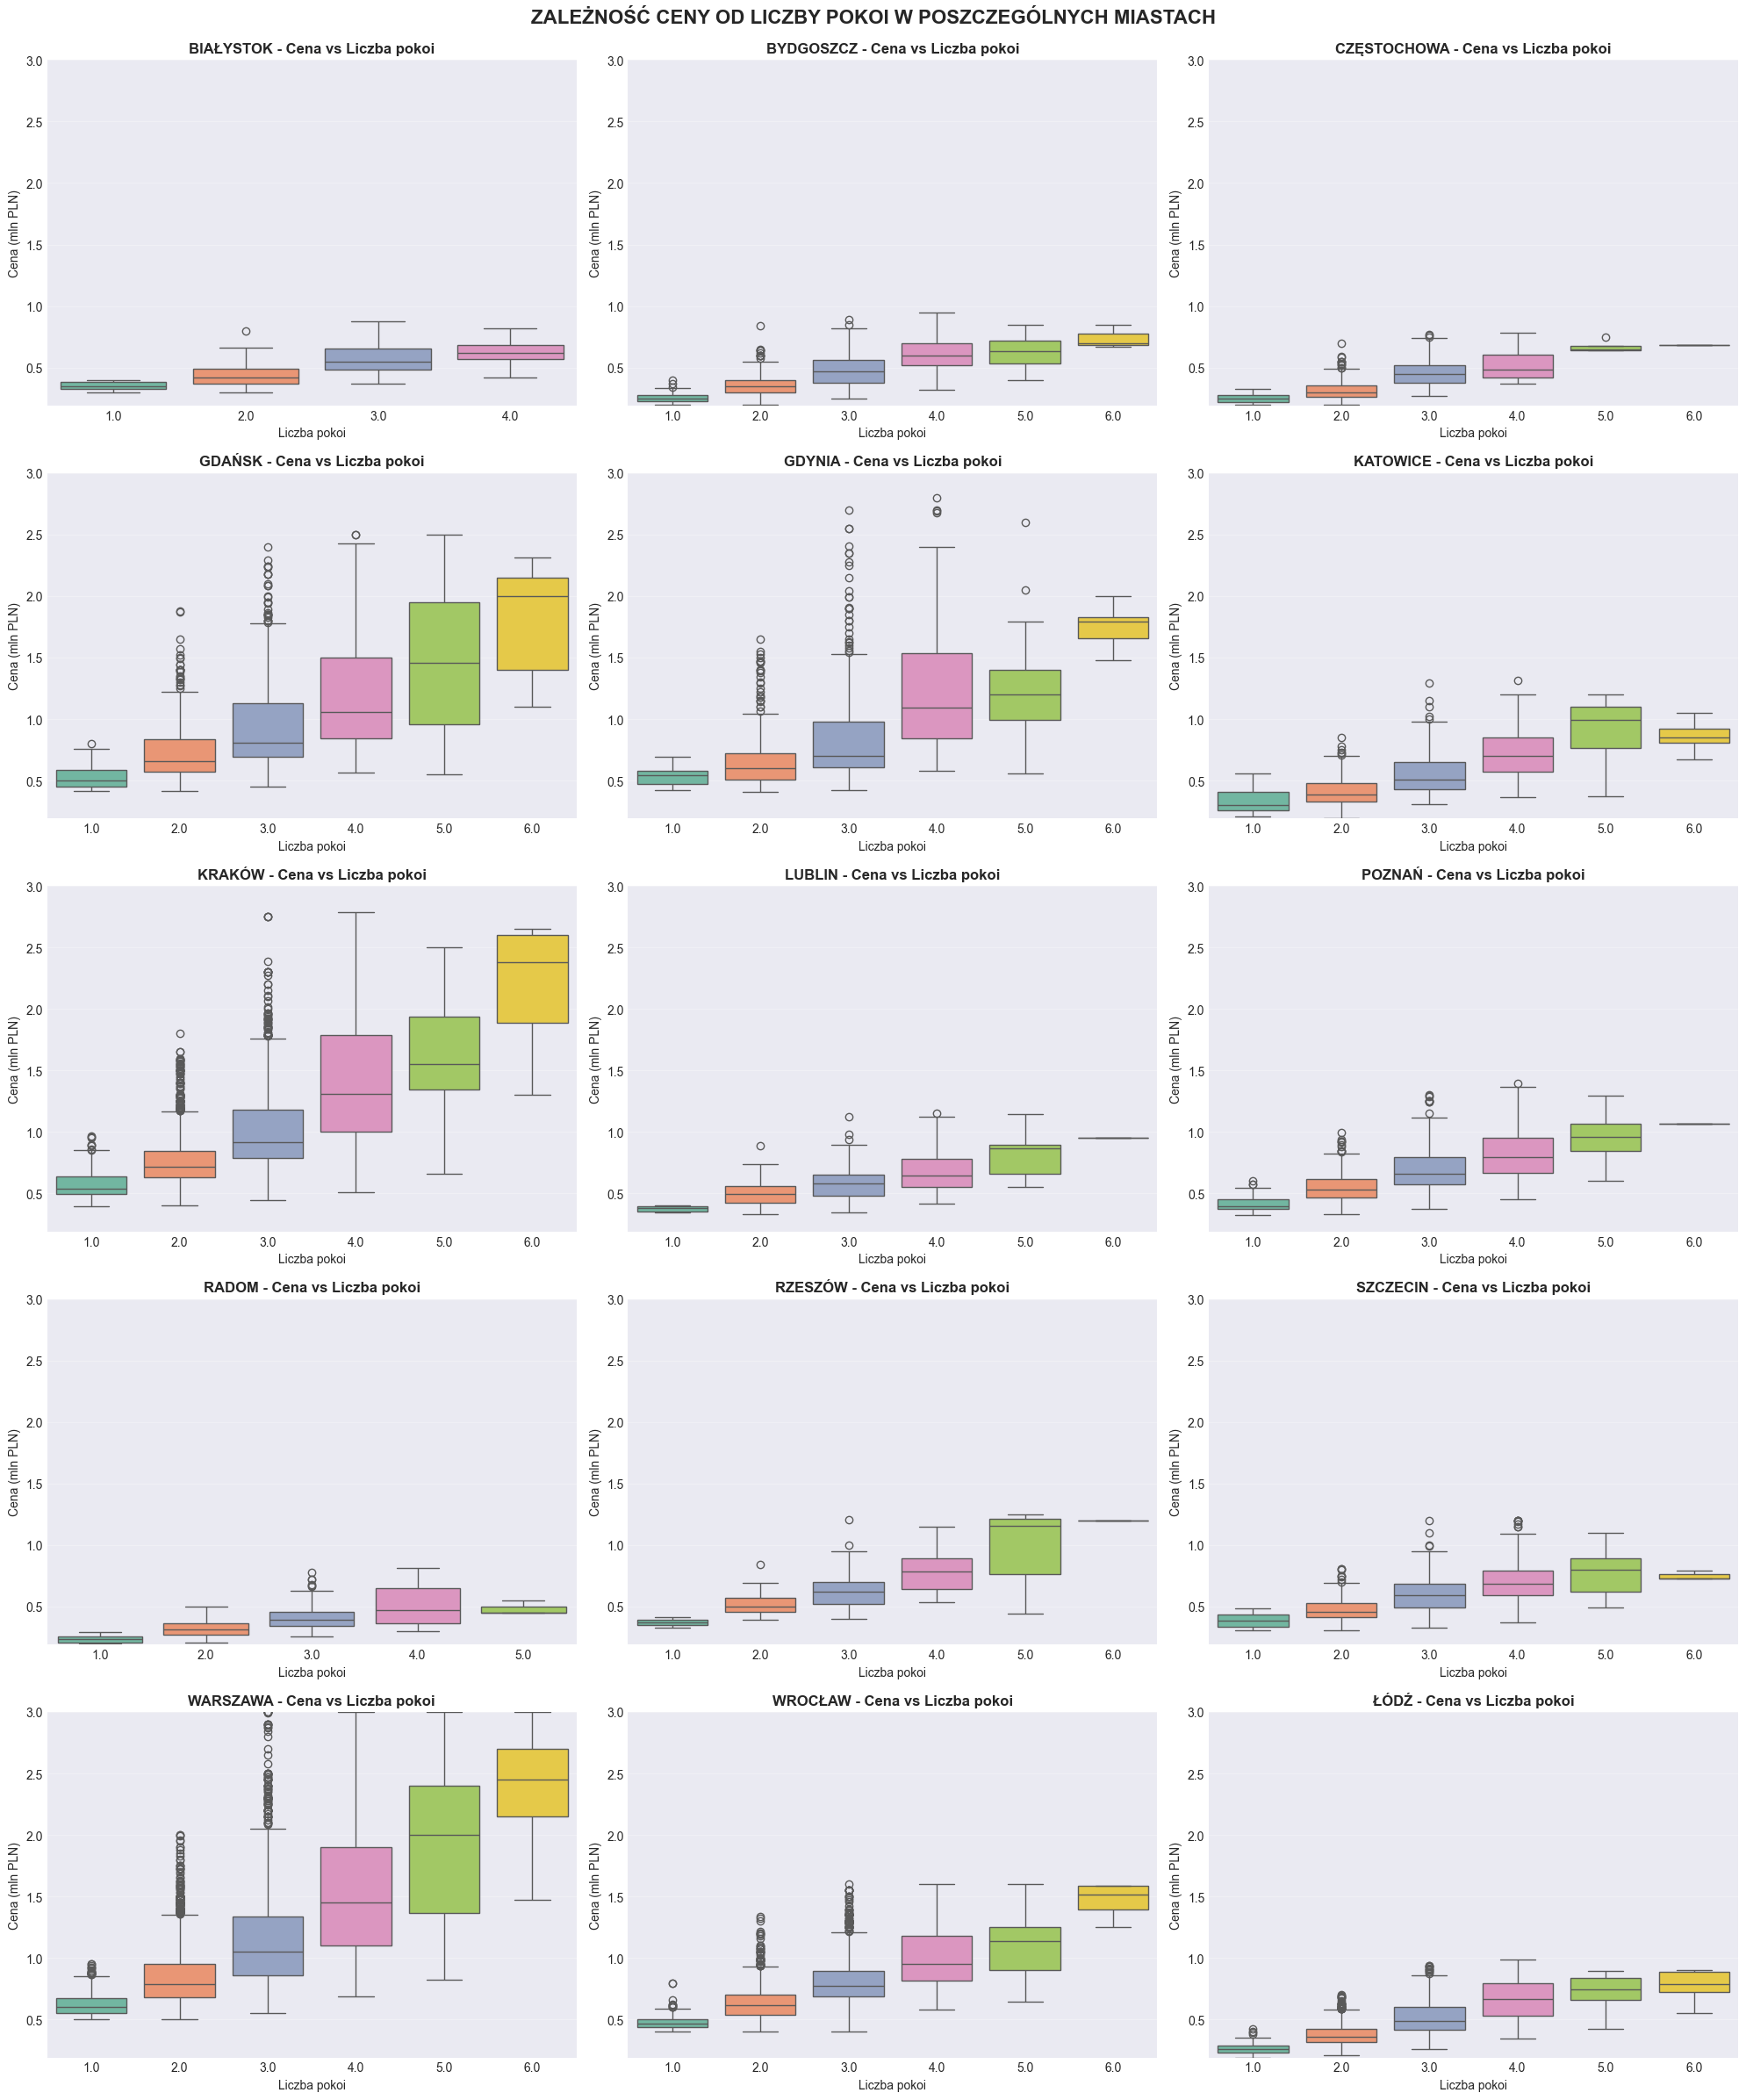

In [96]:
# ========================================
# CZĘŚĆ 5b: CENA VS LICZBA POKOI - PO MIASTACH
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

cities = sorted(df['miasto'].unique())
n_cities = len(cities)

# Funkcja formatująca oś Y w milionach
def millions_formatter(x, pos):
    return f'{x/1e6:.1f}'

# Ustalamy wspólną skalę osi Y (cena)
y_min, y_max = df['cena'].min(), df['cena'].max()

fig, axes = plt.subplots(5, 3, figsize=(20, 24))
axes = axes.flatten()

for idx, city in enumerate(cities):
    city_data = df[df['miasto'] == city]
    
    sns.boxplot(data=city_data, x='liczba_pokoi', y='cena', hue='liczba_pokoi', ax=axes[idx], palette='Set2', legend=False)
    axes[idx].set_title(f'{city.upper()} - Cena vs Liczba pokoi', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Liczba pokoi', fontsize=10)
    axes[idx].set_ylabel('Cena (mln PLN)', fontsize=10)
    
    # Formatowanie osi Y w milionach
    axes[idx].yaxis.set_major_formatter(FuncFormatter(millions_formatter))
    
    # Wspólna skala osi Y
    axes[idx].set_ylim(y_min, y_max)
    
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(n_cities, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ZALEŻNOŚĆ CENY OD LICZBY POKOI W POSZCZEGÓLNYCH MIASTACH', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



Analizowane przez nas wykresy pudełkowe wykazują liczne wartości odstające w relacji liczby pokoi do ceny, co jest szczególnie widoczne w miastach o wysokim poziomie cenowym, takich jak Warszawa, Kraków, Wrocław, Gdańsk oraz Gdynia. Zauważamy jednocześnie, że w ośrodkach takich jak Poznań, Lublin, Rzeszów, Szczecin, Radom czy Częstochowa występuje niska reprezentacja mieszkań o największej liczbie pokoi (5 i 6). Fakt ten potwierdza, że rynki w tych miastach są zdominowane przez mniejsze lokale, a segment nieruchomości wielopokojowych ma tam charakter marginalny.

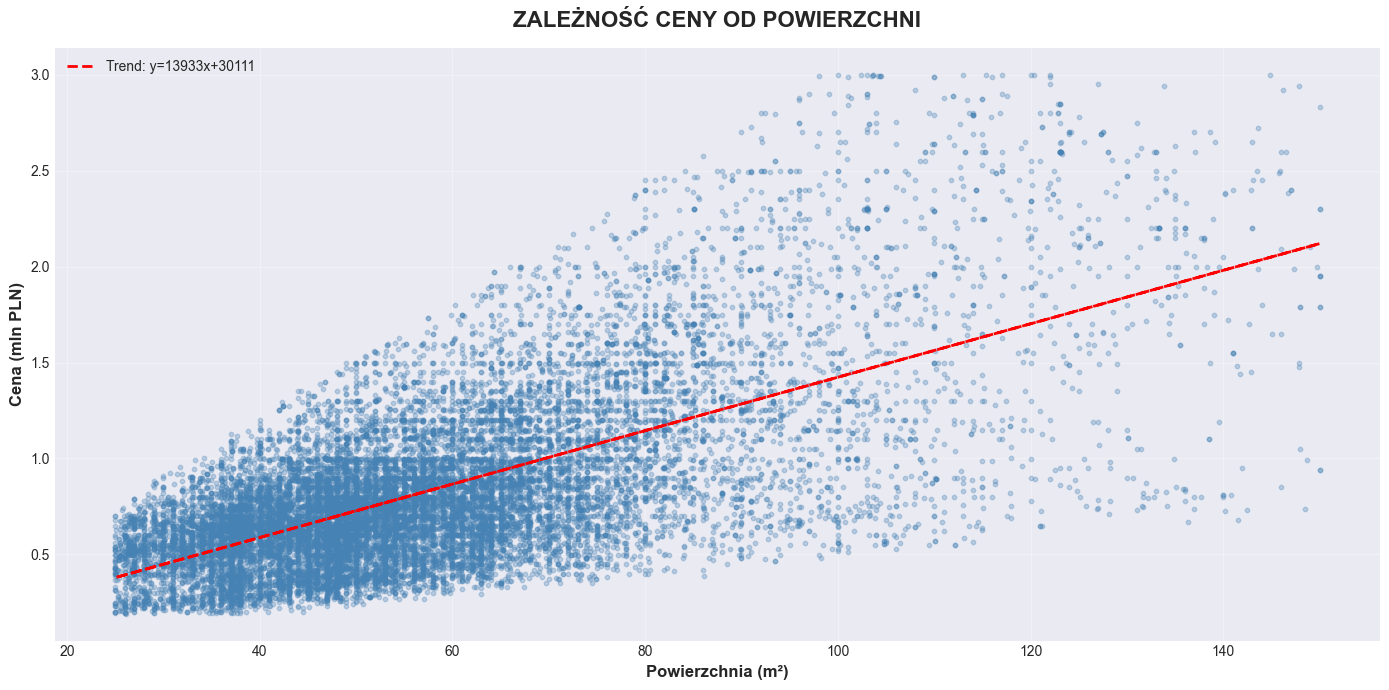

ANALIZA KORELACJI: POWIERZCHNIA vs CENA
Współczynnik korelacji Pearsona: 0.6663
P-value: 0.0000e+00
Wynik: Bardzo silnie istotny statystycznie (p < 0.001) ***


In [97]:
# ========================================
# CZĘŚĆ 6: SCATTERPLOTY - KLUCZOWE ZALEŻNOŚCI
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
from scipy import stats

# ========================================
# 6.1 CENA VS POWIERZCHNIA
# ========================================

# Funkcja formatująca oś Y w milionach
def millions_formatter(x, pos):
    return f'{x/1e6:.1f}'

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(df['metraż'], df['cena'], alpha=0.3, s=10, c='steelblue')
ax.set_title('ZALEŻNOŚĆ CENY OD POWIERZCHNI', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Powierzchnia (m²)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cena (mln PLN)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Formatowanie osi Y w milionach
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

# Dodajemy linię trendu
z = np.polyfit(df['metraż'], df['cena'], 1)
p = np.poly1d(z)
ax.plot(df['metraż'], p(df['metraż']), "r--", linewidth=2, label=f'Trend: y={z[0]:.0f}x+{z[1]:.0f}')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Korelacja Pearsona z p-value
corr, p_value = stats.pearsonr(df['metraż'], df['cena'])
print("="*60)
print("ANALIZA KORELACJI: POWIERZCHNIA vs CENA")
print("="*60)
print(f"Współczynnik korelacji Pearsona: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpretacja istotności statystycznej
if p_value < 0.001:
    print("Wynik: Bardzo silnie istotny statystycznie (p < 0.001) ***")
elif p_value < 0.01:
    print("Wynik: Silnie istotny statystycznie (p < 0.01) **")
elif p_value < 0.05:
    print("Wynik: Istotny statystycznie (p < 0.05) *")
else:
    print("Wynik: Nieistotny statystycznie (p ≥ 0.05)")



Scatterplot, wykazuje jednoznaczą korelacje między powierzchnią a ceną mieszkań w Polsce, wartość korelacji wynosi 0.6663 oraz P-Value poniżej 0,05

# -----------------------------------------------------
### Wnioskowanie statystyczne

### Przygotowanie danych

In [98]:
# dodawanie zmiennej 'cena_za_m2'
df['cena_za_m2'] = df['cena'] / df['metraż']   

# wyświetlenie pierwszych pięciu wierszy ramki danych
print(df.head())

                                 id    miasto       typ_zabudowy  metraż  \
0  811891f98a870dfd6e414374a0a85560  Szczecin       blockOfFlats   47.00   
1  adaf636d0c44d8d9325bce42403eefee  Szczecin  apartmentBuilding   88.22   
2  9b957bd60885a469c96f17b58a914f4b  Szczecin  apartmentBuilding  117.00   
3  74fef2ff7135bc70797a3fbfd7d44ed6  Szczecin       blockOfFlats   33.31   
4  77cc78c75b0d09bf84d6d3124a28803c  Szczecin       blockOfFlats   56.00   

   liczba_pokoi  piętro  liczba_pięter_w_budynku  rok_budowy  \
0           2.0       6                       12        1981   
1           3.0       1                        2        2000   
2           5.0       4                        4        1983   
3           1.0       1                        4        1963   
4           3.0       7                        7        2018   

   szerokość_geograficzna  długość_geograficzna  ...  odległość_od_uczelni  \
0               53.428544             14.552812  ...                 0.593   
1 

In [99]:
# zamiana zmiennych binarnych kategorycznych z 'tak'/'nie' na 1/0
kolumny_binarne = ["czy_posiada_parking", "czy_posiada_balkon", "czy_posiada_ochronę", "czy_posiada_komórkę_lokatorską"]

# używamy metody .map() do konwersji wartości
df[kolumny_binarne] = df[kolumny_binarne].map(lambda x: 1 if str(x).lower() == 'yes' else 0)

# wyświetlenie nagłówka wybranych kolumn binarnych
print(df[kolumny_binarne].head())

   czy_posiada_parking  czy_posiada_balkon  czy_posiada_ochronę  \
0                    0                   1                    0   
1                    1                   1                    0   
2                    1                   1                    0   
3                    1                   0                    1   
4                    1                   1                    1   

   czy_posiada_komórkę_lokatorską  
0                               1  
1                               0  
2                               0  
3                               1  
4                               1  


In [100]:
# sprawdzenie czy próba jest wystarczająca

n = len(df)
print("liczba obserwacji:", n)

# reguła kciuka – dla średniej zazwyczaj n > 30 wystarcza
print("czy próba jest wystarczająca do estymacji średniej? ->", n > 30)

# dla proporcji – min 10 sukcesów i 10 porażek
def sprawdz_warunek_proporcji(seria):
    sukcesy = (seria == 1).sum()
    porazki = (seria == 0).sum()
    return sukcesy >= 10 and porazki >= 10

print("czy dla zmiennych binarnych jest wystarczająca ilość sukcesów i porażek?")
for kolumna in ["czy_posiada_parking", "czy_posiada_balkon", "czy_posiada_windę", "czy_posiada_ochronę", "czy_posiada_komórkę_lokatorską"]:
    print(kolumna, sprawdz_warunek_proporcji(df[kolumna]))

liczba obserwacji: 21501
czy próba jest wystarczająca do estymacji średniej? -> True
czy dla zmiennych binarnych jest wystarczająca ilość sukcesów i porażek?
czy_posiada_parking True
czy_posiada_balkon True
czy_posiada_windę True
czy_posiada_ochronę True
czy_posiada_komórkę_lokatorską True



### 1. Macierze korelacji



--- 1. Macierz Korelacji Spearmana (ρ) dla Zmiennych Ilościowych (Q-Q) ---


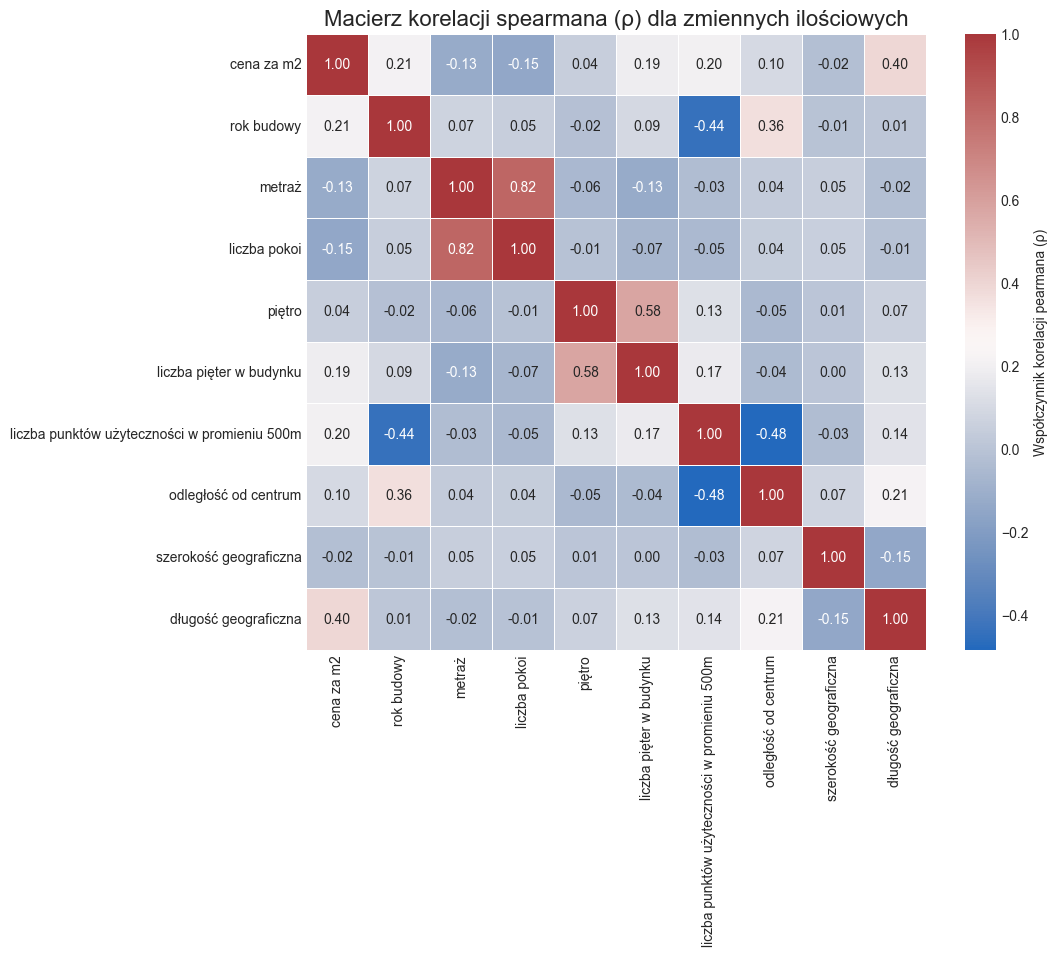


--- 2. Macierz siły związku Craméra V dla zmiennych jakościowych (C-C) ---


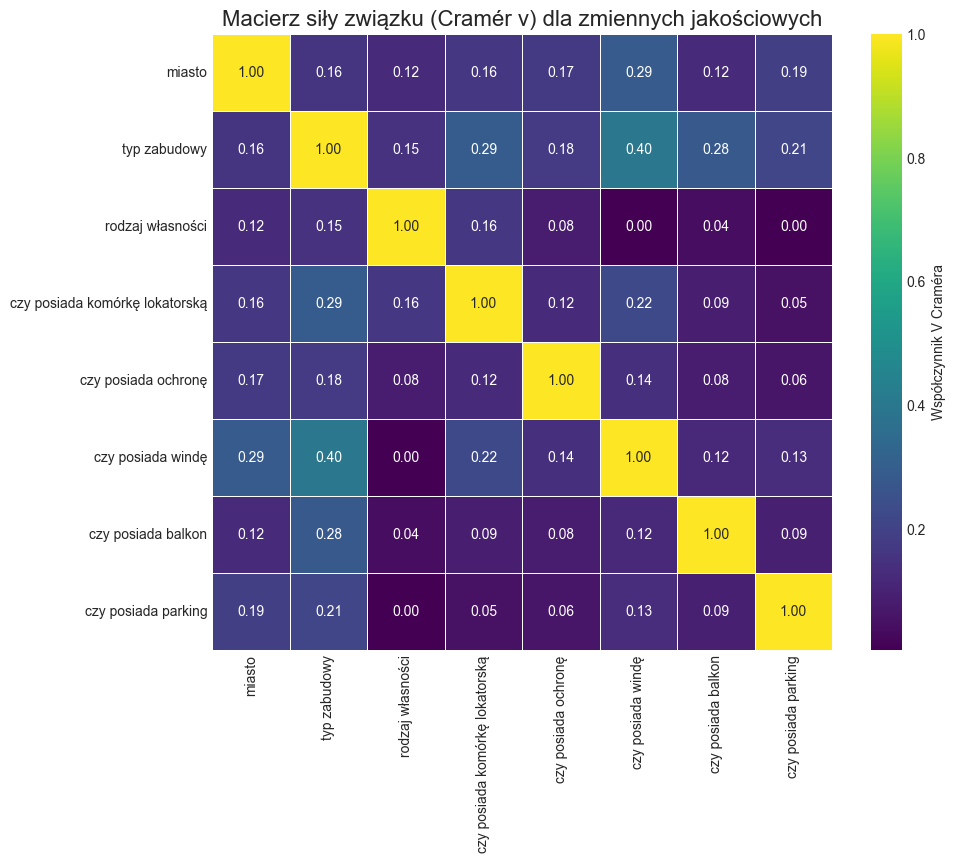

--- 📊 Macierz korelacji dla wszystkich zmiennych (N=21501) ---


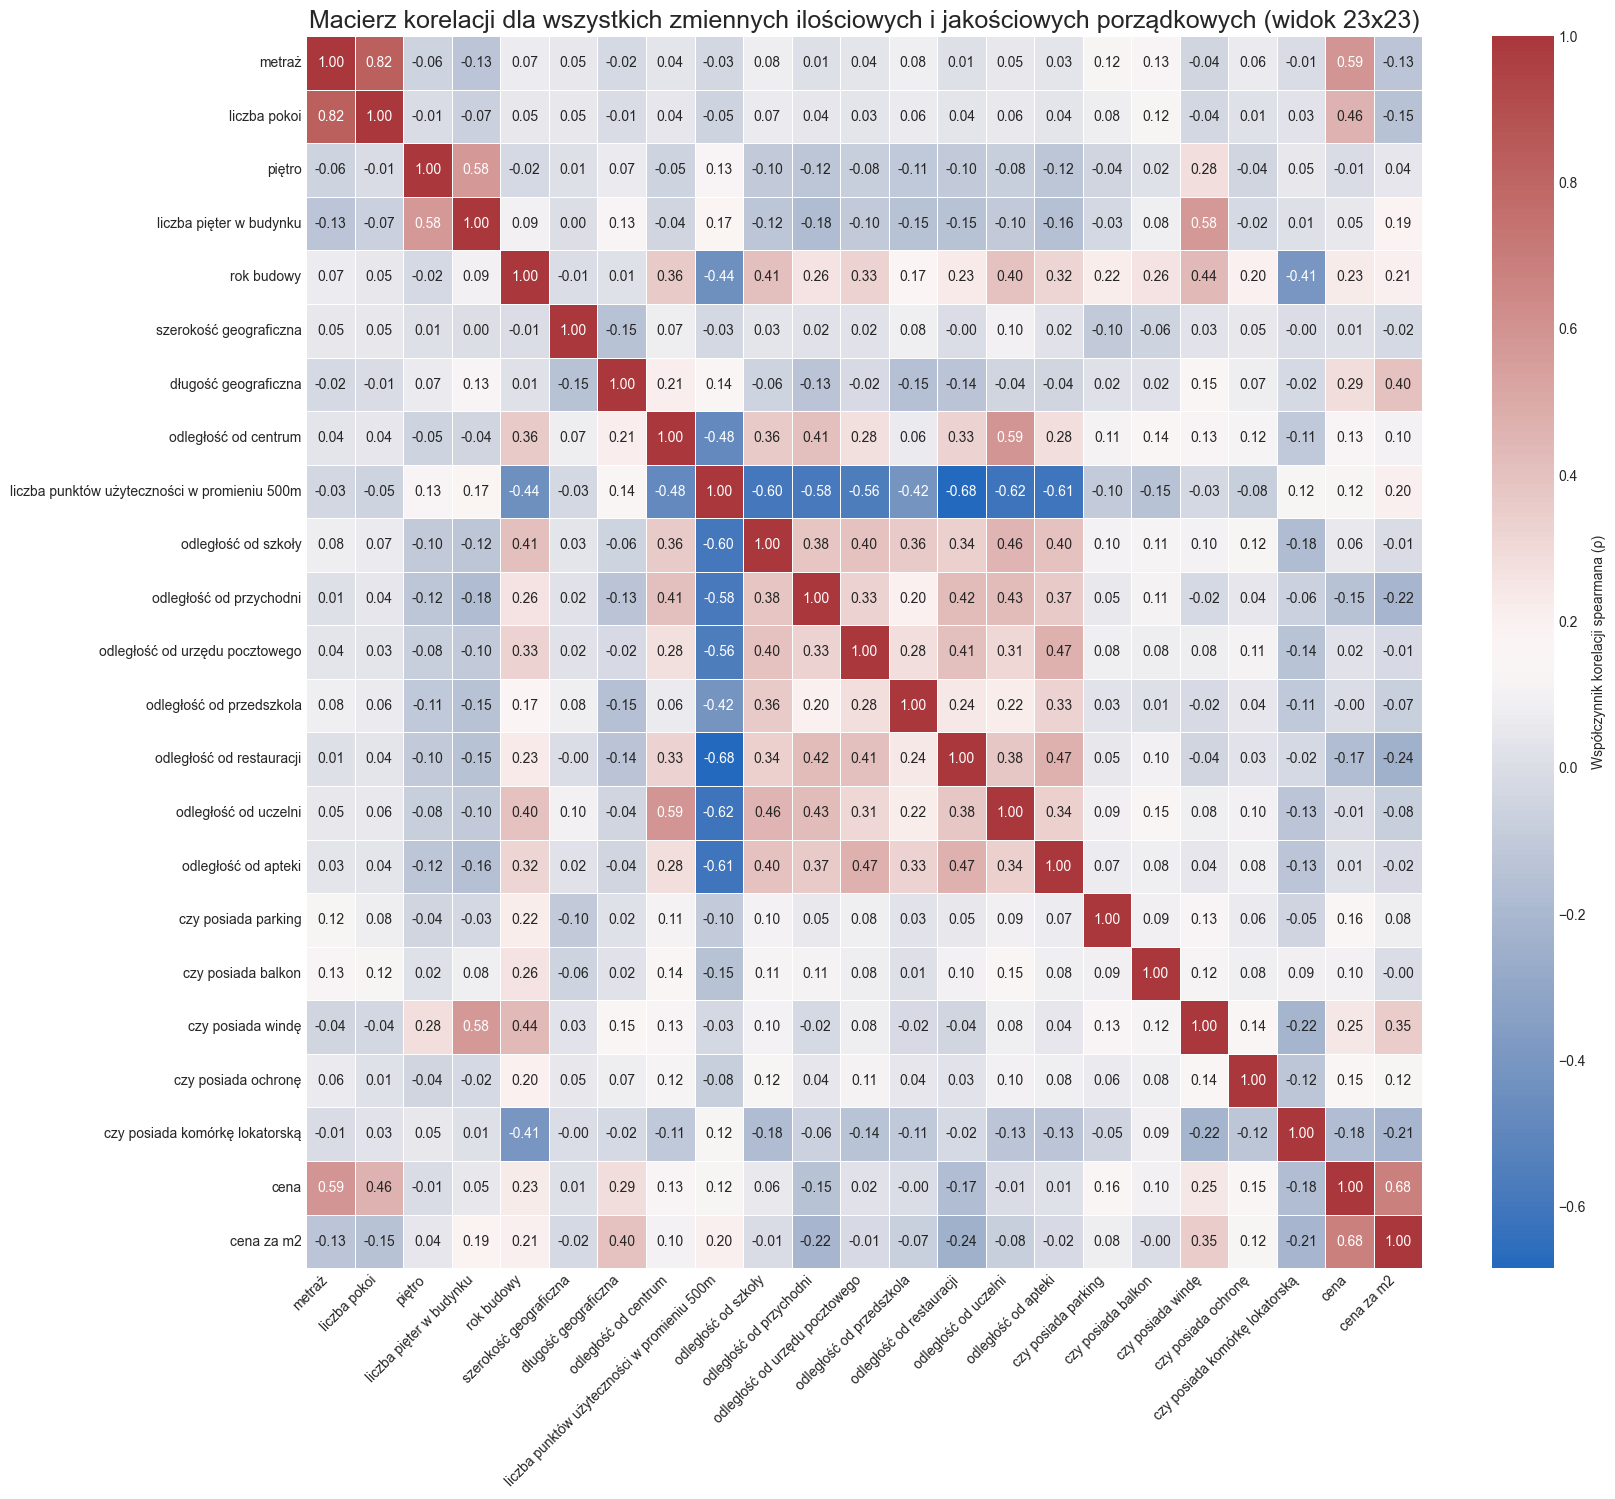

In [ ]:
# Zmienne Ilościowe (Q-VARS) - po polsku
Q_VARS = ['cena_za_m2', 'rok_budowy', 'metraż', 'liczba_pokoi', 'piętro', 
          'liczba_pięter_w_budynku', 'liczba_punktów_użyteczności_w_promieniu_500m', 
          'odległość_od_centrum', 'szerokość_geograficzna', 'długość_geograficzna']

# Zmienne Jakościowe (C-VARS) - po polsku
C_VARS = ['miasto', 'typ_zabudowy', 'rodzaj_własności', 'czy_posiada_komórkę_lokatorską', 
          'czy_posiada_ochronę', 'czy_posiada_windę', 'czy_posiada_balkon', 'czy_posiada_parking']
# --- SEKCJA 1: KORELACJA ILOŚCIOWE vs. ILOŚCIOWE ---

print("--- 1. Macierz korelacji spearmana (ρ) dla zmiennych ilościowych (Q-Q) ---")
correlation_matrix_q = df[Q_VARS].dropna().corr(method='spearman')

# USUWANIE _ Z NAZW
correlation_matrix_q.index = [c.replace('_', ' ') for c in correlation_matrix_q.index]
correlation_matrix_q.columns = [c.replace('_', ' ') for c in correlation_matrix_q.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_q, annot=True, cmap='vlag', fmt=".2f", linewidths=.5,
            cbar_kws={'label': 'Współczynnik korelacji pearmana (ρ)'})
plt.title('Macierz korelacji spearmana (ρ) dla zmiennych ilościowych', fontsize=16)
plt.show()


# --- SEKCJA 2: KORELACJA JAKOŚCIOWE vs. JAKOŚCIOWE ---

print("\n--- 2. Macierz siły związku Craméra V dla zmiennych jakościowych (C-C) ---")
v_matrix = pd.DataFrame(index=C_VARS, columns=C_VARS, dtype=float)
np.fill_diagonal(v_matrix.values, 1.0)
df_clean_c = df.dropna(subset=C_VARS).copy()

for var1, var2 in combinations(C_VARS, 2):
    contingency_table = pd.crosstab(df_clean_c[var1], df_clean_c[var2])
    v_matrix.loc[var1, var2] = cramers_v(contingency_table)
    v_matrix.loc[var2, var1] = v_matrix.loc[var1, var2]

# USUWANIE _ Z NAZW
v_matrix.index = [c.replace('_', ' ') for c in v_matrix.index]
v_matrix.columns = [c.replace('_', ' ') for c in v_matrix.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(v_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5,
            cbar_kws={'label': 'Współczynnik V Craméra'})
plt.title("Macierz siły związku (Cramér v) dla zmiennych jakościowych", fontsize=16)
plt.show()


# --- SEKCJA 3: PEŁNA MACIERZ KORELACJI ---

print(f"--- 📊 Macierz korelacji dla wszystkich zmiennych (N={SAMPLE_SIZE}) ---")

combined_correlation_matrix = df_encoded[df_encoded.select_dtypes(include=np.number).columns].corr(method='spearman')

final_size = min(len(combined_correlation_matrix), MATRIX_VISUAL_LIMIT)
matrix_to_plot = combined_correlation_matrix.iloc[:final_size, :final_size].copy()

# USUWANIE _ ORAZ CZYSZCZENIE NAZW
matrix_to_plot.index = [c.replace('_', ' ').strip() for c in matrix_to_plot.index]
matrix_to_plot.columns = [c.replace('_', ' ').strip() for c in matrix_to_plot.columns]

plt.figure(figsize=(18, 16))
sns.heatmap(
    matrix_to_plot,
    annot=True, 
    fmt=".2f",
    cmap='vlag',
    linewidths=.5,
    cbar_kws={'label': 'Współczynnik korelacji spearmana (ρ)'}
)
plt.title(f'Macierz korelacji dla wszystkich zmiennych ilościowych i jakościowych porządkowych (widok {final_size}x{final_size})', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

Analiza korelacji Spearmana na zmiennych ilościowych oraz identyfikacja związków jakościowych pozwoliła na określenie kluczowych zależności w danych rynkowych. W zbiorze danych dominuje wysoka dodatnia korelacja między zmiennymi wyrażającymi odległość od konkretnych punktów użyteczności publicznej (np. pharmacyDistance, collegeDistance) oraz zmienną pokazującą odległość od centrum (centreDistance). Oznacza to, że punkty POI są zlokalizowane blisko siebie w przestrzeni miejskiej. Jednocześnie, zmienne te wykazują silną ujemną korelację ze zmienną poiCount, co potwierdza, że im dalej od centrum, tym mniejsza jest ogólna liczba dostępnych punktów użyteczności publicznej w pobliżu. Poza oczywistymi zależnościami, takimi jak silna dodatnia korelacja między liczbą pokoi (rooms) a powierzchnią (squareMeters), wyciągnęliśmy bardziej interesujące wnioski. Zauważalna dodatnia korelacja wynosząca około 0.36 między rokiem budowy (buildYear) a odległością od centrum sugeruje, że nowsze budynki statystycznie częściej znajdują się dalej od ścisłego centrum miasta, co odzwierciedla ekspansję urbanistyczną. Ciekawa jest również silna dodatnia korelacja wynosząca około 0.59 między odległością od centrum a odległością od uniwersytetów (collegeDistance), co wyraźnie wskazuje na to, że większość uczelni wyższych jest położona w centrum lub jego bezpośrednim sąsiedztwie. Zauważyliśmy także istotną zależność między typem budynku a faktem posiadania windy (hasElevator), co sugeruje, że występowanie windy jest silnie skorelowane z kategorią zabudowy (np. nowsze apartamentowce mają windy częściej niż kamienice), co zostało pogłębione w osobnej analizie wizualnej.


### 2. Proporcja mieszkań posiadających windę: analiza porównawcza występowania wind w różnych typach budynku


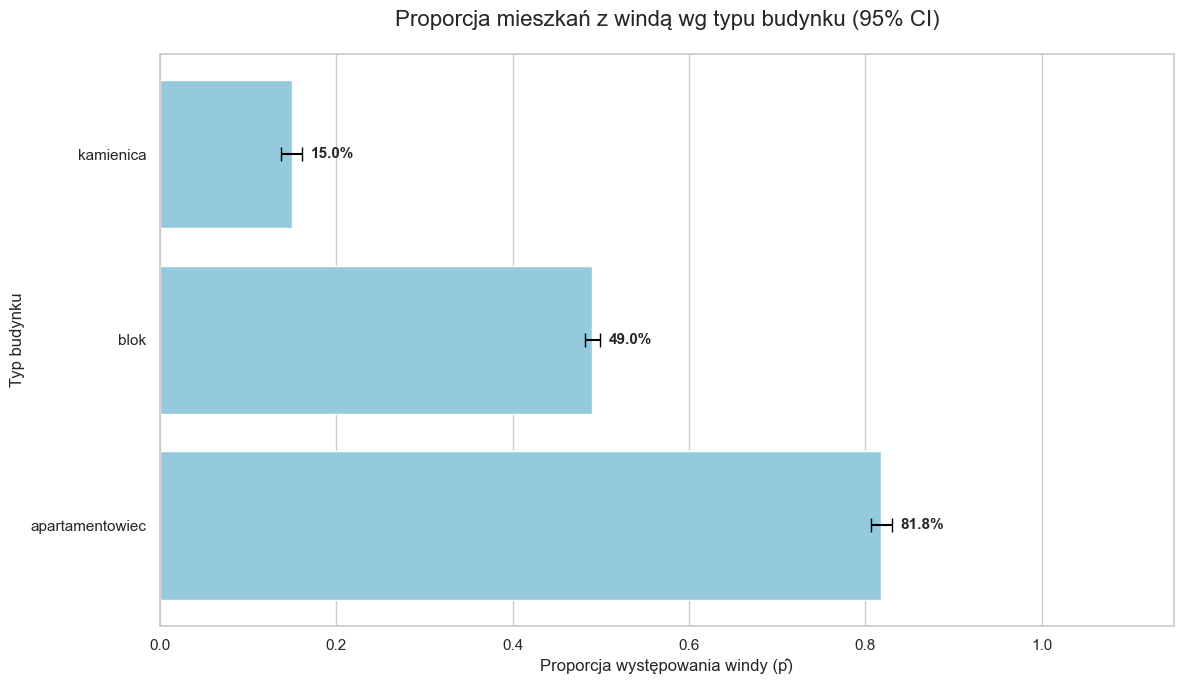

------------------------------
Statystyka chi-kwadrat: 3449.380
p-value: 0.00000e+00
Wniosek: Istnieją istotne statystycznie różnice w posiadaniu windy między typami zabudowy.


In [102]:

# --- Ustawienia estetyki ---
sns.set_theme(style="whitegrid")

# Definicja zmiennych
zmienna_cel = 'czy_posiada_windę'
zmienna_grupujaca = 'typ_zabudowy'
poziom_ufnosci = 0.95
z_score = stats.norm.ppf(1 - (1 - poziom_ufnosci) / 2)

mapowanie_typów = {
    'apartmentBuilding': 'apartamentowiec',
    'blockOfFlats': 'blok',
    'tenement': 'kamienica'
}

# 1. Przygotowanie danych
df[zmienna_cel] = pd.to_numeric(df[zmienna_cel], errors='coerce').fillna(0).astype(int)
df[zmienna_grupujaca] = df[zmienna_grupujaca].replace(mapowanie_typów)
df_czyste = df.dropna(subset=[zmienna_grupujaca, zmienna_cel])

# 2. Funkcja do obliczania CI
def oblicz_ci_proporcji(grupa):
    n = len(grupa)
    if n == 0:
        return pd.Series({'p_hat': np.nan, 'n': 0, 'moe': np.nan})
    
    p_hat = grupa.mean() 
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    moe = z_score * se 
    return pd.Series({'p_hat': p_hat, 'n': n, 'moe': moe})

ci_wg_typu = df_czyste.groupby(zmienna_grupujaca)[zmienna_cel].apply(oblicz_ci_proporcji).unstack()
ci_wg_typu = ci_wg_typu[ci_wg_typu['n'] >= 30].sort_values(by='p_hat', ascending=True)

# 3. Wizualizacja - WYKRES LEŻĄCY (Horyzontalny)
plt.figure(figsize=(12, 7))

etykiety_y = [str(ind).replace('_', ' ') for ind in ci_wg_typu.index]

# Rysowanie słupków
ax = sns.barplot(
    x=ci_wg_typu['p_hat'], 
    y=etykiety_y, 
    color='skyblue',
    orient='h'
)

# Dodanie Error Bars (poziome)
plt.errorbar(
    x=ci_wg_typu['p_hat'], 
    y=etykiety_y, 
    xerr=ci_wg_typu['moe'], 
    fmt='none', capsize=5, color='black', elinewidth=1.5
)

# --- DODANIE ETYKIET DANYCH (Procenty) ---
for i, p_hat in enumerate(ci_wg_typu['p_hat']):
    plt.text(
        p_hat + ci_wg_typu['moe'].iloc[i] + 0.01, 
        i,                                       
        f'{p_hat:.1%}',                         
        va='center', fontweight='bold', fontsize=11
    )

plt.title('Proporcja mieszkań z windą wg typu budynku (95% CI)', fontsize=16, pad=20)
plt.xlabel('Proporcja występowania windy (p̂)', fontsize=12)
plt.ylabel('Typ budynku', fontsize=12)
plt.xlim(0, 1.15) 
plt.tight_layout()
plt.show()

# --- Statystyka ---
tabela_kontyngencji = pd.crosstab(df_czyste[zmienna_grupujaca], df_czyste[zmienna_cel])
chi2_stat, p_value, dof, expected = chi2_contingency(tabela_kontyngencji)

print("-" * 30)
print(f"Statystyka chi-kwadrat: {chi2_stat:.3f}")
print(f"p-value: {p_value:.5e}")
if p_value < 0.05:
    print("Wniosek: Istnieją istotne statystycznie różnice w posiadaniu windy między typami zabudowy.")

Przeprowadzona analiza wykazała, że występowanie windy w mieszkaniach różni się istotnie w zależności od typu budynku. Największą proporcję mieszkań wyposażonych w windę obserwujemy w grupie „apartmentBuilding” (ok. 82%), nieco mniejszą w „blockOfFlats” (ok. 49%), a najmniejszą w „tenement” (ok. 15%). Wyniki testu Chi-kwadrat (χ² = 3449,38, p < 0,001) wskazują, że te różnice są istotne statystycznie, co oznacza, że typ budynku ma realny wpływ na prawdopodobieństwo posiadania windy w mieszkaniu.


### 3. Badanie normalności rozkładu całkowitej ceny


--- 📊 badanie normalności rozkładu 'cena' ---
liczba wszystkich obserwacji: n = 21501


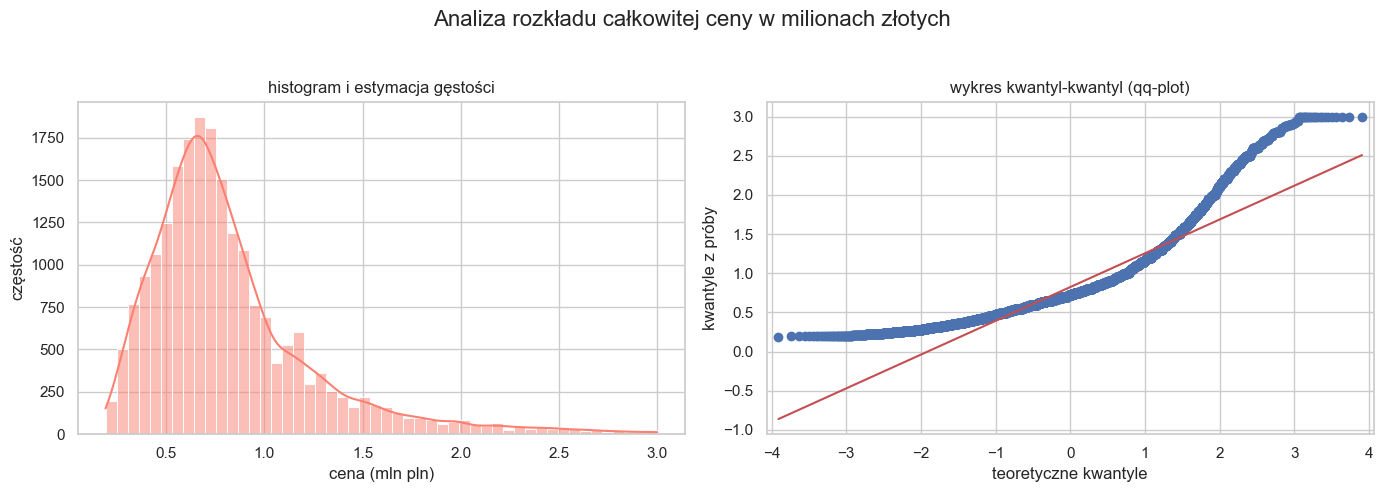

test shapiro-wilka przeprowadzono na losowej podpróbce n=5000 obserwacji.


In [103]:
# ustawienie estetyki wykresów
sns.set_theme(style="whitegrid")
zmienna_analizowana = 'cena'

# 1. przygotowanie danych (konwersja na miliony)
dane_cena_mln = df[zmienna_analizowana].dropna() / 1000000

print(f"--- 📊 badanie normalności rozkładu '{zmienna_analizowana}' ---")
print(f"liczba wszystkich obserwacji: n = {len(dane_cena_mln)}")

# 2. wizualna weryfikacja (histogram i qq-plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Analiza rozkładu całkowitej ceny w milionach złotych", fontsize=16)

# histogram w milionach
sns.histplot(dane_cena_mln, kde=True, ax=axes[0], color='salmon', bins=50)
axes[0].set_title('histogram i estymacja gęstości')
axes[0].set_xlabel('cena (mln pln)')
axes[0].set_ylabel('częstość')

# wykres qq-plot
sm.qqplot(dane_cena_mln, line='s', ax=axes[1]) 
axes[1].set_title('wykres kwantyl-kwantyl (qq-plot)')
axes[1].set_xlabel('teoretyczne kwantyle')
axes[1].set_ylabel('kwantyle z próby')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 3. formalne testy statystyczne
stat_dagostino, p_dagostino = stats.normaltest(dane_cena_mln)

limit_n = 5000
if len(dane_cena_mln) > limit_n:
    probka_danych = dane_cena_mln.sample(limit_n, random_state=42)
    stat_shapiro, p_shapiro = stats.shapiro(probka_danych)
    print(f"test shapiro-wilka przeprowadzono na losowej podpróbce n={limit_n} obserwacji.")
else:
    stat_

Dla lepszego zrozumienia rozkładu naszej kluczowej zmiennej, czyli całkowitej ceny mieszkań, przeprowadzono analizę normalności. Wykonany został Test Shapiro-Wilka oraz test D’Agostino-Pearsona. Wyniki obu testów wskazują na bardzo niskie p-value (p < 0,001), co prowadzi do odrzucenia hipotezy zerowej o normalności rozkładu. Oznacza to, że rozkład całkowitej ceny nie jest normalny i cechuje się silną prawostronną asymetrią – istnieje więcej mieszkań o cenach niższych, a kilka wysokich cen powoduje długi prawy ogon rozkładu.
Takie wnioski są istotne przy wyborze metod statystycznych i interpretacji wyników, ponieważ wiele klasycznych testów zakłada normalność danych.


### 4. Lokalny przedział ufności dla średniej ceny za m2, powierzchni i wieku budynku w całej Polsce


--- generowanie wizualizacji przedziałów ufności dla miast ---


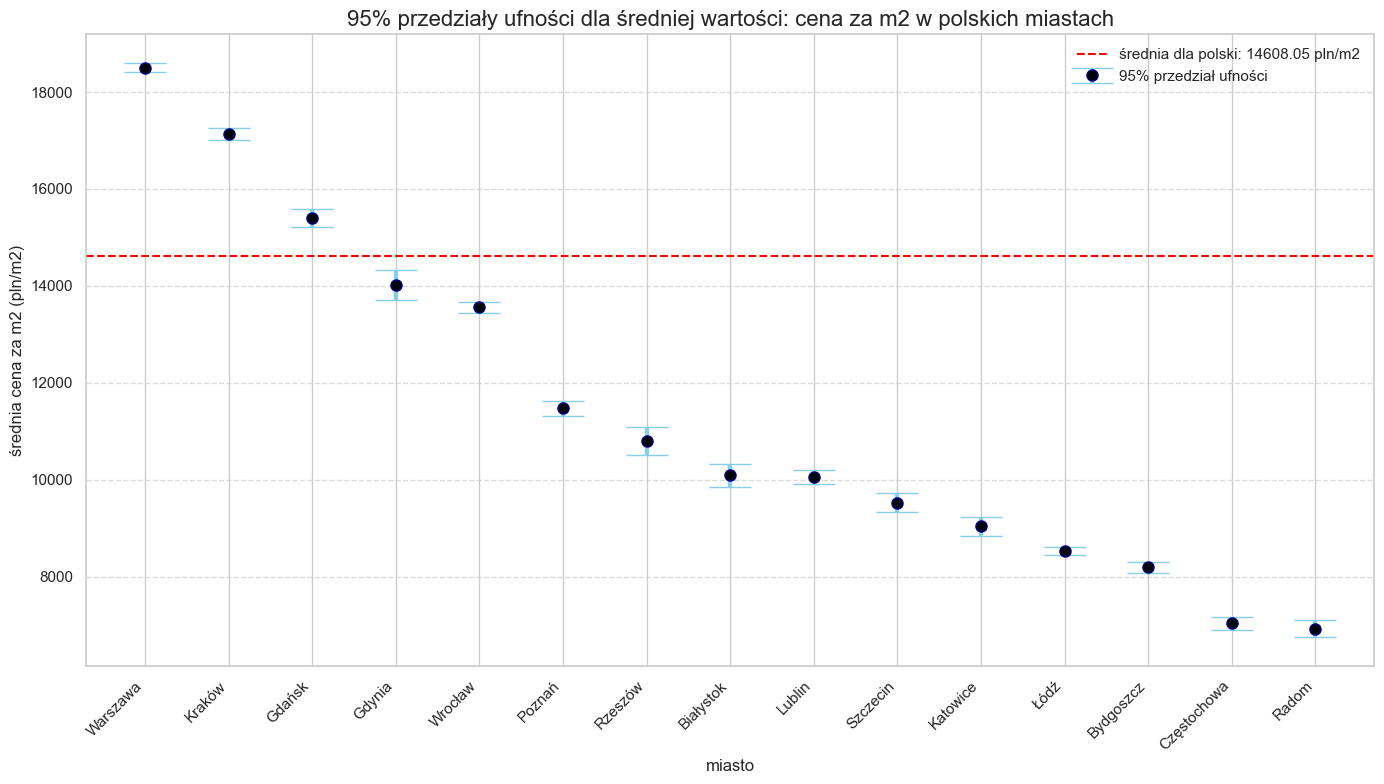

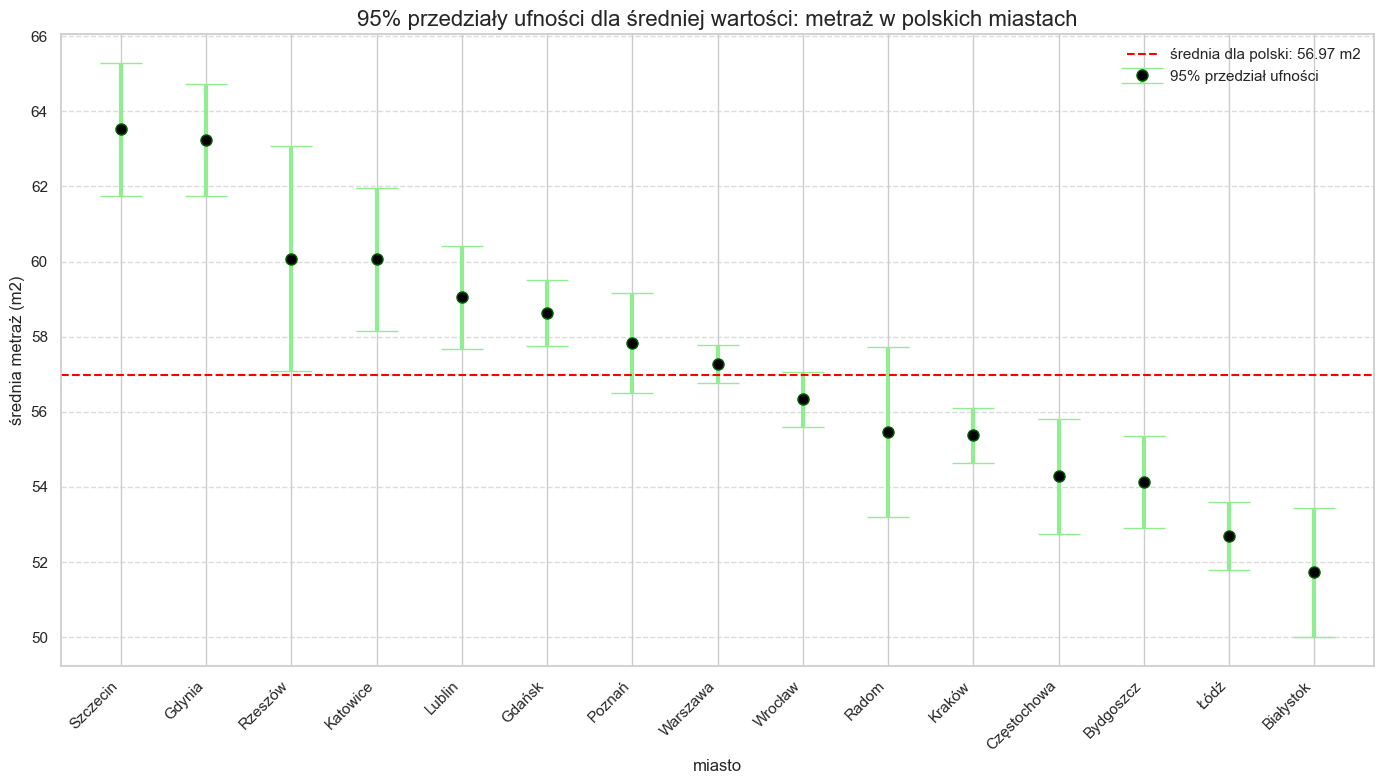

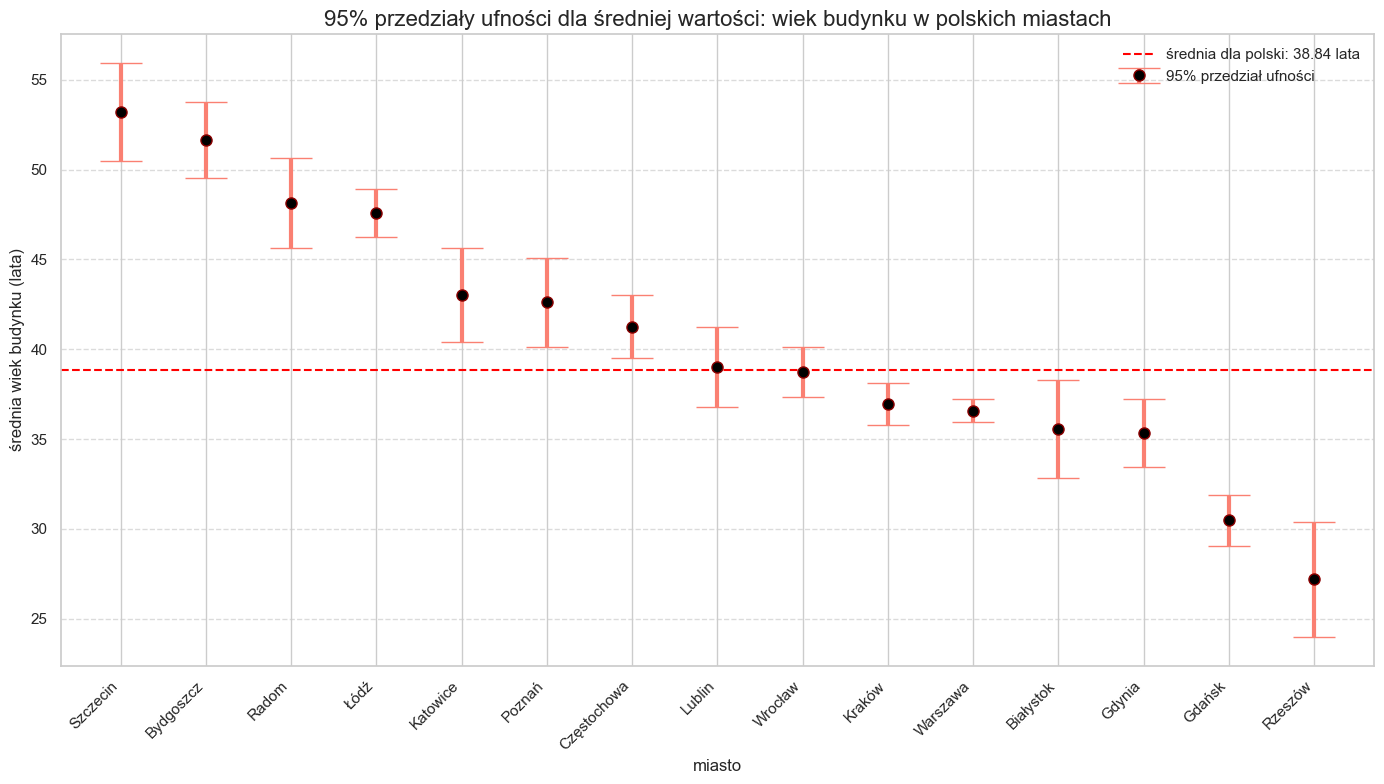

In [104]:
# przyjęcie roku 2025 jako punktu odniesienia do obliczeń
aktualny_rok = 2025 

# obliczenie wieku nieruchomości na podstawie roku budowy
seria_wiek_budynku = aktualny_rok - df['rok_budowy']

# dodanie obliczonego wieku jako nowej kolumny 'wiek_budynku' do ramki danych
df['wiek_budynku'] = seria_wiek_budynku

# konfiguracja estetyki wykresów oraz poziomu ufności
sns.set_theme(style="whitegrid")
poziom_ufnosci = 0.95

# 1. funkcja pomocnicza wyznaczająca przedziały ufności
def oblicz_ci(grupa, poziom_ufnosci=0.95):
    """oblicza średnią arytmetyczną, błąd standardowy oraz granice przedziału ufności."""
    n = len(grupa)
    if n == 0:
        return pd.Series({'mean': np.nan, 'ci_lower': np.nan, 'ci_upper': np.nan, 'moe': np.nan})
    
    mean = grupa.mean()
    std = grupa.std()
    
    # obliczenie błędu standardowego średniej
    std_err = std / np.sqrt(n)
    # wyznaczenie wartości krytycznej z-score
    z_score = stats.norm.ppf((1 + poziom_ufnosci) / 2)
    margines_bledu = z_score * std_err
    
    return pd.Series({
        'mean': mean,
        'ci_lower': mean - margines_bledu,
        'ci_upper': mean + margines_bledu,
        'moe': margines_bledu
    })

# 2. funkcja generująca wykresy porównawcze dla miast
def generuj_wykres_ci_miasta(df, kolumna, etykieta_jednostki):
    """wyznacza przedziały ufności i tworzy wykres błędów dla miast."""
    
    # grupowanie danych według miast i aplikacja funkcji oblicz_ci
    ci_miasta = df.groupby('miasto')[kolumna].apply(oblicz_ci).unstack()
    # sortowanie wyników od najwyższej średniej i usuwanie brakujących danych
    ci_miasta = ci_miasta.sort_values(by='mean', ascending=False).dropna(subset=['mean'])
    
    # usunięcie podkreślników z nazw miast na potrzeby wykresu
    etykiety_miast = [str(i).replace('_', ' ') for i in ci_miasta.index]
    
    # wyznaczenie średniej krajowej dla linii odniesienia
    srednia_ogolna = df[kolumna].mean()

    if ci_miasta.empty:
        print(f"brak wystarczających danych, aby wygenerować wykres dla kolumny: {kolumna}")
        return

    plt.figure(figsize=(14, 8))
    
    # przygotowanie nazwy zmiennej do wyświetlenia na wykresie
    nazwa_bez_podkreslen = kolumna.replace('_', ' ')
    
    plt.errorbar(
        x=etykiety_miast, 
        y=ci_miasta['mean'], 
        yerr=ci_miasta['moe'], 
        fmt='o', 
        capsize=15, 
        # dobór kolorystyki w zależności od analizowanej jednostki
        color='darkgreen' if etykieta_jednostki == 'm2' else ('darkred' if etykieta_jednostki == 'lata' else 'darkblue'),
        ecolor='lightgreen' if etykieta_jednostki == 'm2' else ('salmon' if etykieta_jednostki == 'lata' else 'skyblue'),
        elinewidth=3,
        markerfacecolor='black',
        markersize=8,
        label='95% przedział ufności'
    )

    # naniesienie linii średniej dla całej polski
    plt.axhline(srednia_ogolna, color='red', linestyle='--', linewidth=1.5, label=f'średnia dla polski: {srednia_ogolna:.2f} {etykieta_jednostki}')

    plt.title(f'95% przedziały ufności dla średniej wartości: {nazwa_bez_podkreslen} w polskich miastach', fontsize=16)
    plt.xlabel('miasto', fontsize=12)
    plt.ylabel(f'średnia {nazwa_bez_podkreslen} ({etykieta_jednostki})', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("--- generowanie wizualizacji przedziałów ufności dla miast ---")

# analiza średniej ceny za metr kwadratowy
generuj_wykres_ci_miasta(df, 'cena_za_m2', 'pln/m2')

# analiza średniego metrażu lokali
generuj_wykres_ci_miasta(df, 'metraż', 'm2')

# analiza średniego wieku budynków
if 'wiek_budynku' in df.columns:
    generuj_wykres_ci_miasta(df, 'wiek_budynku', 'lata')
else:
    print("\n⚠️ uwaga: w ramce danych nie znaleziono kolumny 'wiek_budynku'.")

Przedział ufności to zakres wartości, obliczony na podstawie danych z próby, który z określonym poziomem ufności (w tym przypadku 95%) zawiera rzeczywisty, nieznany parametr populacji (np. średnią μ lub proporcję p). Na przykład: 95% przedział ufności dla średniej ceny za metr kwadratowy oznacza, że istnieje 95% prawdopodobieństwo, iż faktyczna średnia cena w całej populacji ofert mieści się w wyznaczonym zakresie.

Analiza zmiennych pricePerM2, squareMeters i centreDistance pokazuje, że średnie wartości tych cech są dobrze oszacowane, o czym świadczą wąskie przedziały ufności (CI) obejmujące 90% możliwych średnich w populacji. Jednocześnie szerokie przedziały predykcji (PI) wskazują, że pojedyncze mieszkania mogą znacząco odbiegać od średniej — ceny za m², powierzchnie i odległości od centrum wykazują dużą zmienność wśród poszczególnych nieruchomości. Oznacza to, że choć średnie wartości są reprezentatywne, rzeczywiste dane poszczególnych mieszkań mogą różnić się od nich w znacznym stopniu.


### 5. Welch anova + interpretacja + wizualizacja (cena za m2 w podziale na miasto, typ budynku, licbę pięter)



ANALIZA: cena za m2 ~ miasto

📊 Wyniki Welch ANOVA:
   Source  ddof1      ddof2          F  p-unc     np2
0  miasto     14  2822.6942  3517.3094    0.0  0.5665

🧠 Interpretacja:
✔ Istnieją **istotne statystycznie różnice** średniej zmiennej 'cena za m2' pomiędzy grupami zmiennej 'miasto' (p = 0.0000 < 0.05).

📈 Statystyki opisowe:
                 mean    median      std  count
miasto                                         
Białystok    10089.06   9884.49  1837.51    231
Bydgoszcz     8194.03   7987.22  1735.80    937
Częstochowa   7034.63   6888.89  1402.83    385
Gdańsk       15402.31  14053.57  4373.61   1986
Gdynia       14020.05  12652.36  4656.85    828
Katowice      9038.26   8461.54  2461.50    593
Kraków       17135.48  16353.48  3788.69   3245
Lublin       10060.79   9890.25  1780.42    574
Poznań       11472.10  11018.52  2210.07    793
Radom         6929.92   6699.51  1220.21    195
Rzeszów      10803.55  10811.15  1882.11    163
Szczecin      9529.45   9216.01  2515.33  

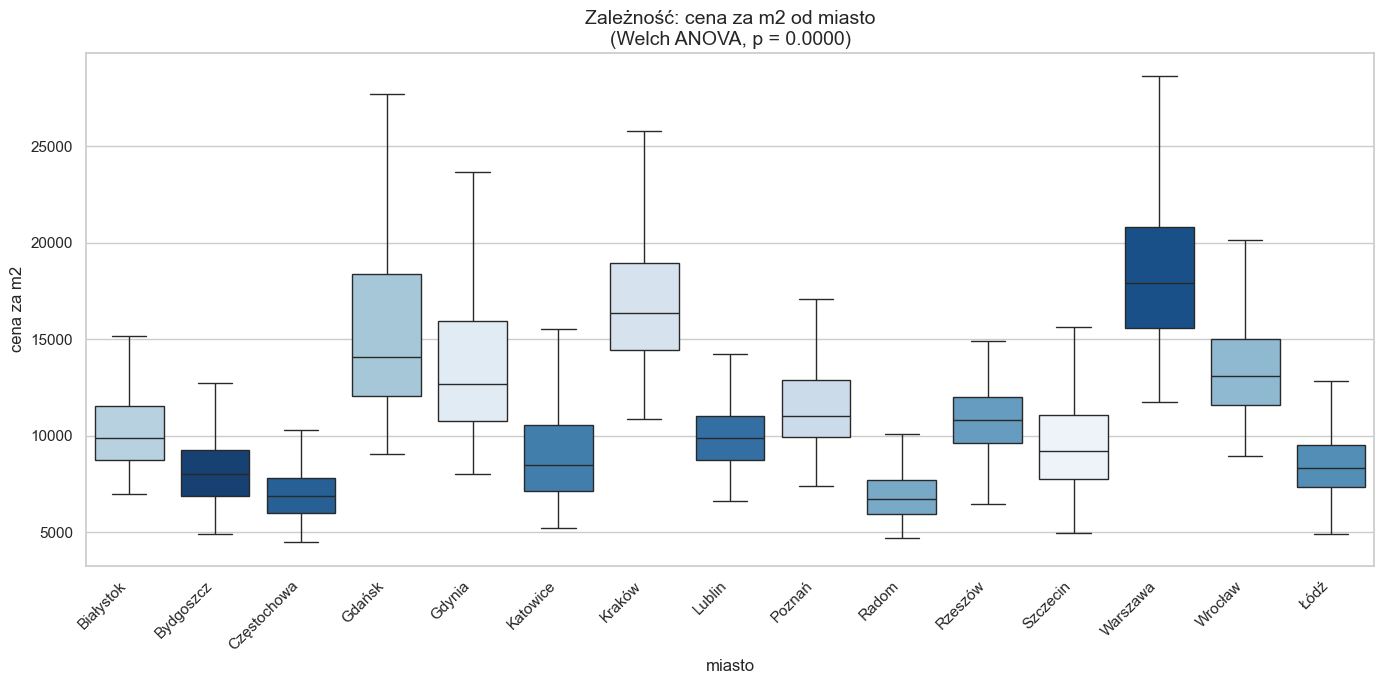


ANALIZA: cena za m2 ~ typ zabudowy

📊 Wyniki Welch ANOVA:
         Source  ddof1      ddof2          F  p-unc    np2
0  typ_zabudowy      2  6707.6453  1295.1974    0.0  0.107

🧠 Interpretacja:
✔ Istnieją **istotne statystycznie różnice** średniej zmiennej 'cena za m2' pomiędzy grupami zmiennej 'typ zabudowy' (p = 0.0000 < 0.05).

📈 Statystyki opisowe:
                     mean    median      std  count
typ_zabudowy                                       
apartamentowiec  17954.37  17900.00  5002.06   4268
blok             13602.71  13472.22  4458.65  13735
kamienica        14472.62  13625.36  6217.90   3498


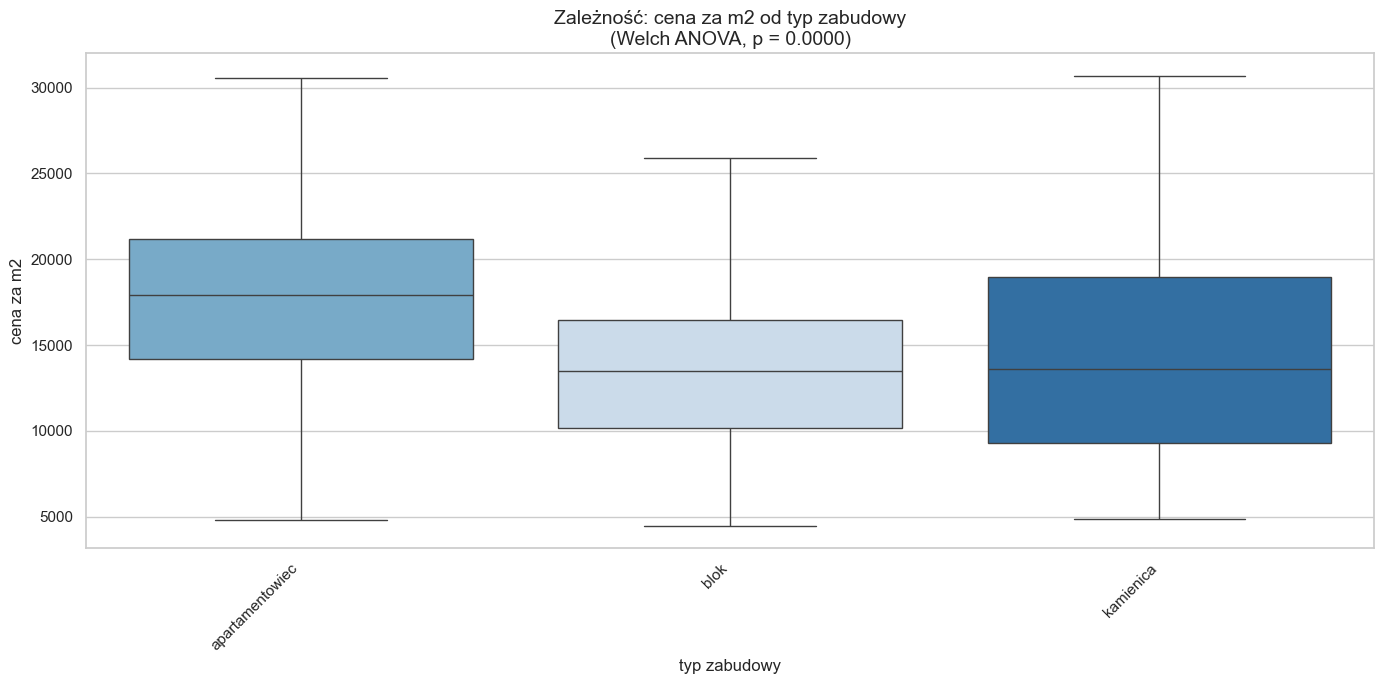


ANALIZA: cena za m2 ~ liczba pięter w budynku

📊 Wyniki Welch ANOVA:
                    Source  ddof1   ddof2         F  p-unc    np2
0  liczba_pięter_w_budynku     28  77.192  158.5818    0.0  0.126

🧠 Interpretacja:
✔ Istnieją **istotne statystycznie różnice** średniej zmiennej 'cena za m2' pomiędzy grupami zmiennej 'liczba pięter w budynku' (p = 0.0000 < 0.05).

📈 Statystyki opisowe:
                             mean    median      std  count
liczba_pięter_w_budynku                                    
1                        12724.19  12370.44  4682.35    421
2                        13832.85  13424.66  4971.22   1517
3                        13837.24  13438.61  4872.33   4034
4                        13211.65  12744.89  4924.71   6562
5                        16788.30  16441.67  5105.99   2046
6                        17856.87  17771.01  4965.40   1327
7                        17814.82  17625.23  4292.32    867
8                        17381.94  16923.08  4806.57    651
9       

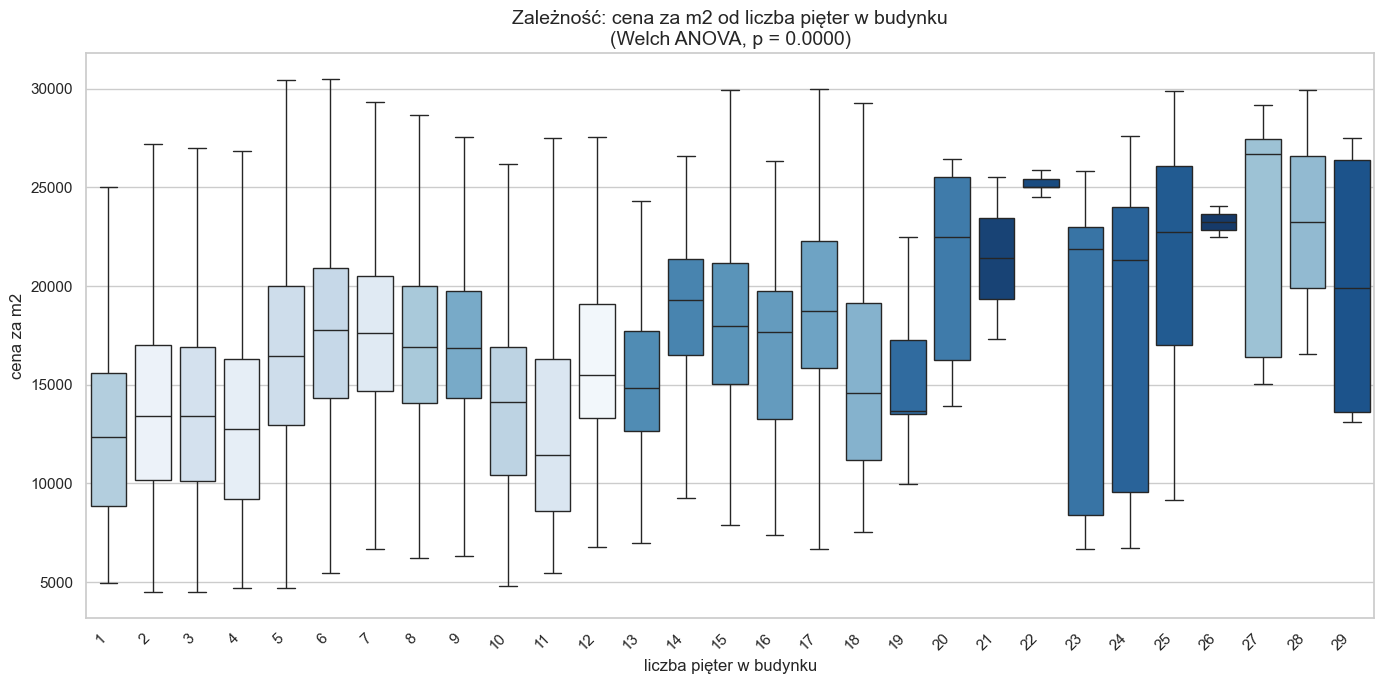

In [121]:

# Ustawienie stylu wizualizacji
sns.set_theme(style="whitegrid")

# --- 1. FUNKCJA ANALIZY WELCH ANOVA ---

def welch_anova_z_wizualizacja(df, dv, group, alpha=0.05):
    # Mapowanie nazw do wyświetlania
    display_dv = dv.replace('_', ' ')
    display_group = group.replace('_', ' ')
    
    print("\n" + "="*70)
    print(f"ANALIZA: {display_dv} ~ {display_group}")
    print("="*70)

    # --- 1. Czyszczenie danych i sortowanie ---
    data = df[[dv, group]].dropna().copy()

    if data.empty:
        print("❌ Brak danych po usunięciu braków (NaN).")
        return

    if data[group].nunique() < 2:
        print("❌ Zmienna grupująca ma mniej niż 2 grupy – ANOVA niemożliwa.")
        return

    # LOGIKA SORTOWANIA (ważna dla liczby pięter)
    # Sortujemy unikalne wartości przed zamianą na tekst
    sorted_categories = sorted(data[group].unique())
    data[group] = data[group].astype(str)
    order_list = [str(x) for x in sorted_categories]

    # --- 2. Welch ANOVA ---
    anova = pg.welch_anova(dv=dv, between=group, data=data)
    p_value = anova["p-unc"].iloc[0]

    print("\n📊 Wyniki Welch ANOVA:")
    print(anova.round(4))

    # --- 3. Interpretacja ---
    print("\n🧠 Interpretacja:")
    if p_value < alpha:
        print(
            f"✔ Istnieją **istotne statystycznie różnice** średniej zmiennej "
            f"'{display_dv}' pomiędzy grupami zmiennej '{display_group}' "
            f"(p = {p_value:.4f} < {alpha})."
        )
    else:
        print(
            f"✖ Brak podstaw do stwierdzenia istotnych różnic "
            f"średniej '{display_dv}' pomiędzy grupami '{display_group}' "
            f"(p = {p_value:.4f} ≥ {alpha})."
        )

    # --- 4. Statystyki opisowe ---
    desc = data.groupby(group, observed=False)[dv].agg(['mean', 'median', 'std', 'count']).round(2)
    # Sortujemy statystyki zgodnie z kolejnością na wykresie
    desc = desc.reindex(order_list)
    print("\n📈 Statystyki opisowe:")
    print(desc)

    # --- 5. Wizualizacja ---
    plt.figure(figsize=(14, 7))

    sns.boxplot(
        data=data,
        x=group,
        y=dv,
        order=order_list,
        hue=group,
        showfliers=False,
        palette="Blues",
        legend=False
    )

    plt.title(f"Zależność: {display_dv} od {display_group}\n(Welch ANOVA, p = {p_value:.4f})", fontsize=14)
    plt.xlabel(display_group, fontsize=12)
    plt.ylabel(display_dv, fontsize=12)
    
    # Czyszczenie etykiet osi X
    ax = plt.gca()
    labels = [str(item.get_text()).replace('_', ' ') for item in ax.get_xticklabels()]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels, rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

# --- 2. WYWOŁANIE ANALIZ ---

welch_anova_z_wizualizacja(df, 'cena_za_m2', 'miasto')
welch_anova_z_wizualizacja(df, 'cena_za_m2', 'typ_zabudowy')
welch_anova_z_wizualizacja(df, 'cena_za_m2', 'liczba_pięter_w_budynku')

Wyniki testów Welch ANOVA wskazują, że średnia cena za m² istotnie różni się między analizowanymi grupami.
Miasto: Zaobserwowano bardzo duże i istotne statystycznie różnice cen za m² między miastami (p < 0,05), co potwierdza silne zróżnicowanie regionalne rynku nieruchomości.
Typ budynku: Rodzaj zabudowy istotnie wpływa na cenę za m² – najwyższe ceny występują w budynkach apartamentowych, a najniższe w blokach (p < 0,05).
Liczba kondygnacji (floorCount): Cena za m² różni się istotnie w zależności od wysokości budynku (p < 0,05), przy czym wyższe budynki są przeciętnie droższe.
Wyniki potwierdzają, że lokalizacja oraz cechy budynku są kluczowymi determinantami cen mieszkań.

# -----------------------------
### 6. Przedziały ufności (95%) dla proporcji cech binarnych (metoda Walda)
# -----------------------------


## 📊 przedziały ufności (99%):
                       zmienna  proporcja  dolna_granica  gorna_granica
           czy_posiada_parking   0.277429       0.269564       0.285294
            czy_posiada_balkon   0.585787       0.577134       0.594440
             czy_posiada_windę   0.500070       0.491286       0.508853
           czy_posiada_ochronę   0.123762       0.117977       0.129547
czy_posiada_komórkę_lokatorską   0.435515       0.426805       0.444225


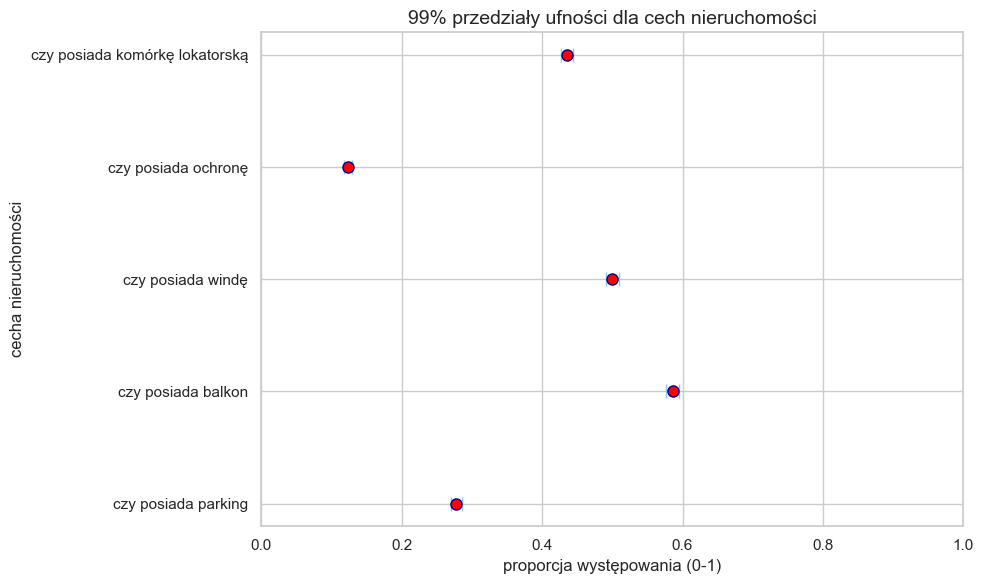

In [107]:

# 1. ustawienia i parametry
zmienne_binarne = ['czy_posiada_parking', 'czy_posiada_balkon', 'czy_posiada_windę', 'czy_posiada_ochronę', 'czy_posiada_komórkę_lokatorską']
poziom_ufnosci = 0.99
z_score = stats.norm.ppf(1 - (1 - poziom_ufnosci) / 2)

# 2. funkcja do bezpiecznej konwersji yes/no na 1/0
def konwertuj_na_binarne(seria):
    return seria.astype(str).str.lower().map({'yes': 1, 'no': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0})

# 3. obliczenia statystyczne
wyniki = []
for zmienna in zmienne_binarne:
    if zmienna not in df.columns:
        continue
        
    dane_tekstowe = df[zmienna].dropna()
    dane_numeryczne = konwertuj_na_binarne(dane_tekstowe).dropna()
    
    n = len(dane_numeryczne)
    if n < 30: 
        continue
        
    p_hat = dane_numeryczne.mean() 
    margines_bledu = z_score * np.sqrt(p_hat * (1 - p_hat) / n)
    
    wyniki.append({
        'zmienna': zmienna,
        'proporcja': p_hat,
        'me': margines_bledu,
        'dolna_granica': max(0, p_hat - margines_bledu),
        'gorna_granica': min(1, p_hat + margines_bledu)
    })

df_wyniki = pd.DataFrame(wyniki)

# 4. wyświetlenie tabeli wyników
print(f"## 📊 przedziały ufności ({int(poziom_ufnosci*100)}%):")
print(df_wyniki[['zmienna', 'proporcja', 'dolna_granica', 'gorna_granica']].to_string(index=False))

# 5. wizualizacja wyników
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

etykiety_y = [z.replace('_', ' ') for z in df_wyniki['zmienna']]

plt.errorbar(x=df_wyniki['proporcja'], y=etykiety_y, xerr=df_wyniki['me'],
             fmt='o', capsize=5, color='darkblue', ecolor='skyblue', 
             elinewidth=3, markerfacecolor='red', markersize=8)

plt.title(f'{int(poziom_ufnosci*100)}% przedziały ufności dla cech nieruchomości', fontsize=14)
plt.xlabel('proporcja występowania (0-1)')
plt.ylabel('cecha nieruchomości')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

Wyznaczone zostały przedziały ufności dla proporcji cech nieruchomości metodą Walda, standaryzując dane i weryfikując liczebność próby, co pozwala na precyzyjne oszacowanie struktury rynku. Wyniki prezentowane są na wykresie punktowym, gdzie kropka reprezentuje szacowaną proporcję występowania danej cechy (np. windy lub balkonu), a pionowe linie wyznaczają margines błędu, w którym z 99% prawdopodobieństwem znajduje się faktyczna wartość rynkowa. Interpretacja opiera się na szerokości tych przedziałów – im są one węższe, tym większa precyzja wynikająca z dużej liczby danych (N=21501),


### 7. Analiza CI i wizualizacja dla grup wielkościowych pod wzgledem powierzhni (małe, średnie, duże)


--- 📏 klasyfikacja mieszkań na 3 grupy (tercyle) ---
liczba wszystkich obserwacji (n): 21501
--------------------------------------------------
## 📐 granice podziału (powierzchnia w m²)
minimum (min): 25.00 m²
**1/3 kwantyl (q1/3): 46.51 m²**
**2/3 kwantyl (q2/3): 61.18 m²**
maksimum (max): 150.00 m²
--------------------------------------------------
## 🏷️ klasyfikacja mieszkań na podstawie metrażu:
* **małe:** powierzchnia do 46.51 m²
* **średnie:** powierzchnia od 46.51 m² do 61.18 m²
* **duże:** powierzchnia powyżej 61.18 m²

## 🔢 liczność mieszkań w utworzonych grupach:
grupa_wielkosci
małe       7168
duże       7167
średnie    7166
Name: count, dtype: int64
--------------------------------------------------
## 💰 wyniki przedziałów ufności (pln/m2) dla grup wielkościowych
                     mean  ci_lower  ci_upper
grupa_wielkosci                              
małe             15647.41  15526.63  15768.19
średnie          13908.23  13798.40  14018.07
duże             14268.27  14

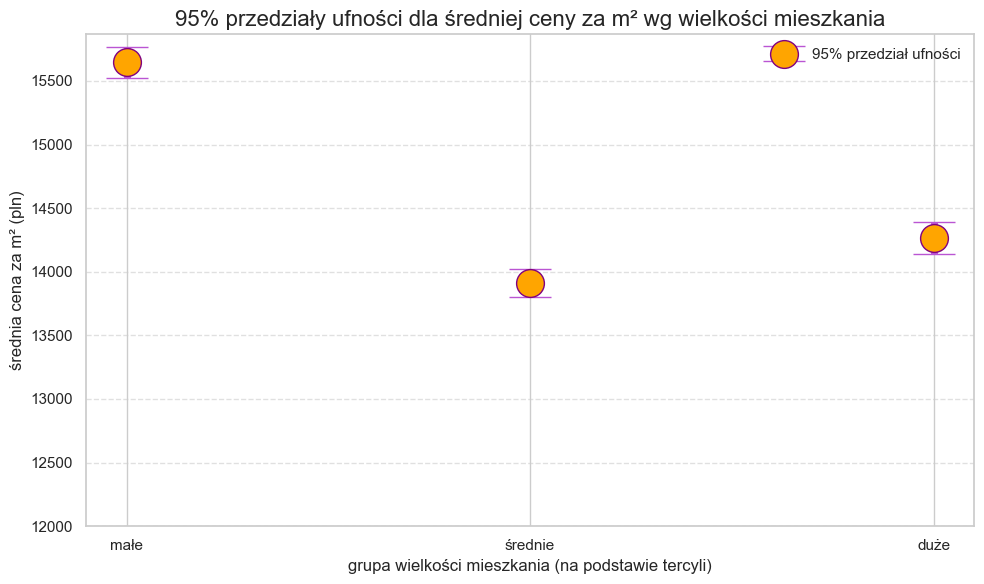

In [108]:
# ustawienie estetyki wykresów
sns.set_theme(style="whitegrid")
poziom_ufnosci = 0.95

# 1. funkcja pomocnicza do obliczania przedziałów ufności (ci)

def oblicz_ci_grupy(grupa, poziom_ufnosci=0.95):
    """oblicza średnią, błąd standardowy i granice ci dla podanej serii danych."""
    n = len(grupa)
    if n == 0:
        return pd.Series({'mean': np.nan, 'ci_lower': np.nan, 'ci_upper': np.nan, 'moe': np.nan})
    
    srednia = grupa.mean()
    odchylenie_std = grupa.std()
    blad_standardowy = odchylenie_std / np.sqrt(n)
    z_score = stats.norm.ppf((1 + poziom_ufnosci) / 2)
    margines_bledu = z_score * blad_standardowy
    
    return pd.Series({
        'mean': srednia,
        'ci_lower': srednia - margines_bledu,
        'ci_upper': srednia + margines_bledu,
        'moe': margines_bledu
    })


# 2. klasyfikacja i wyznaczenie granic podziału (tercyle)

print("--- 📏 klasyfikacja mieszkań na 3 grupy (tercyle) ---")
df['grupa_wielkosci'] = pd.qcut(
    df['metraż'],
    q=3,
    labels=['małe', 'średnie', 'duże'],
    duplicates='drop'
)
granice_tercyli = df['metraż'].quantile([1/3, 2/3])
dolna_granica = df['metraż'].min()
gorna_granica = df['metraż'].max()
kwantyl_1_3 = granice_tercyli.iloc[0]
kwantyl_2_3 = granice_tercyli.iloc[1]

print(f"liczba wszystkich obserwacji (n): {len(df)}")
print("-" * 50)

print("## 📐 granice podziału (powierzchnia w m²)")
print(f"minimum (min): {dolna_granica:.2f} m²")
print(f"**1/3 kwantyl (q1/3): {kwantyl_1_3:.2f} m²**")
print(f"**2/3 kwantyl (q2/3): {kwantyl_2_3:.2f} m²**")
print(f"maksimum (max): {gorna_granica:.2f} m²")
print("-" * 50)

print("## 🏷️ klasyfikacja mieszkań na podstawie metrażu:")
print(f"* **małe:** powierzchnia do {kwantyl_1_3:.2f} m²")
print(f"* **średnie:** powierzchnia od {kwantyl_1_3:.2f} m² do {kwantyl_2_3:.2f} m²")
print(f"* **duże:** powierzchnia powyżej {kwantyl_2_3:.2f} m²")

print("\n## 🔢 liczność mieszkań w utworzonych grupach:")
print(df['grupa_wielkosci'].value_counts())
print("-" * 50)

# 3. zastosowanie funkcji do zgrupowanych danych (cena za m2)

ci_wg_wielkosci = df.groupby('grupa_wielkosci', observed=False)['cena_za_m2'].apply(oblicz_ci_grupy).unstack()

print("## 💰 wyniki przedziałów ufności (pln/m2) dla grup wielkościowych")
print(ci_wg_wielkosci[['mean', 'ci_lower', 'ci_upper']].apply(lambda x: x.round(2)))

# 4. wizualizacja

plt.figure(figsize=(10, 6))

# przygotowanie danych do wykresu błędów
dane_bledu = ci_wg_wielkosci['moe'] 

plt.errorbar(
    x=ci_wg_wielkosci.index, 
    y=ci_wg_wielkosci['mean'],
    yerr=dane_bledu,
    fmt='o', 
    capsize=15,
    color='purple',
    ecolor='mediumorchid',
    elinewidth=5,
    markerfacecolor='orange',
    markersize=20,
    label='95% przedział ufności'
)

# ustawienie limitu osi y dla lepszej czytelności
plt.ylim(12000, None) 

# etykiety i tytuł
plt.title('95% przedziały ufności dla średniej ceny za m² wg wielkości mieszkania', fontsize=16)
plt.xlabel('grupa wielkości mieszkania (na podstawie tercyli)', fontsize=12)
plt.ylabel('średnia cena za m² (pln)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Przeprowadzona zastała analiza porównawcza średniej ceny za metr kwadratowy (pricePerM2) na polskim rynku nieruchomości, dzieląc mieszkania na trzy grupy: Małe, Średnie i Duże, na podstawie tercyli powierzchni. Stworzyliśmy te grupy, aby ocenić, czy cena jednostkowa różni się istotnie statystycznie w zależności od wielkości lokalu. Otrzymany wykres z 95% przedziałami ufności (CI) wizualnie potwierdza rynkową zasadę: najmniejsze mieszkania mają najwyszą cenę za m², ponieważ grupa "Małe" wykazuje najwyższą średnią.


### 8. Analiza istotności statystycznej różnic w średniej cenie za metr kwadratowy pomiędzy największymi miastami w Polsce (test Post-Hoc Tukeya)


--- 🔬 Analiza istotności statystycznej dla wszystkich miast ---


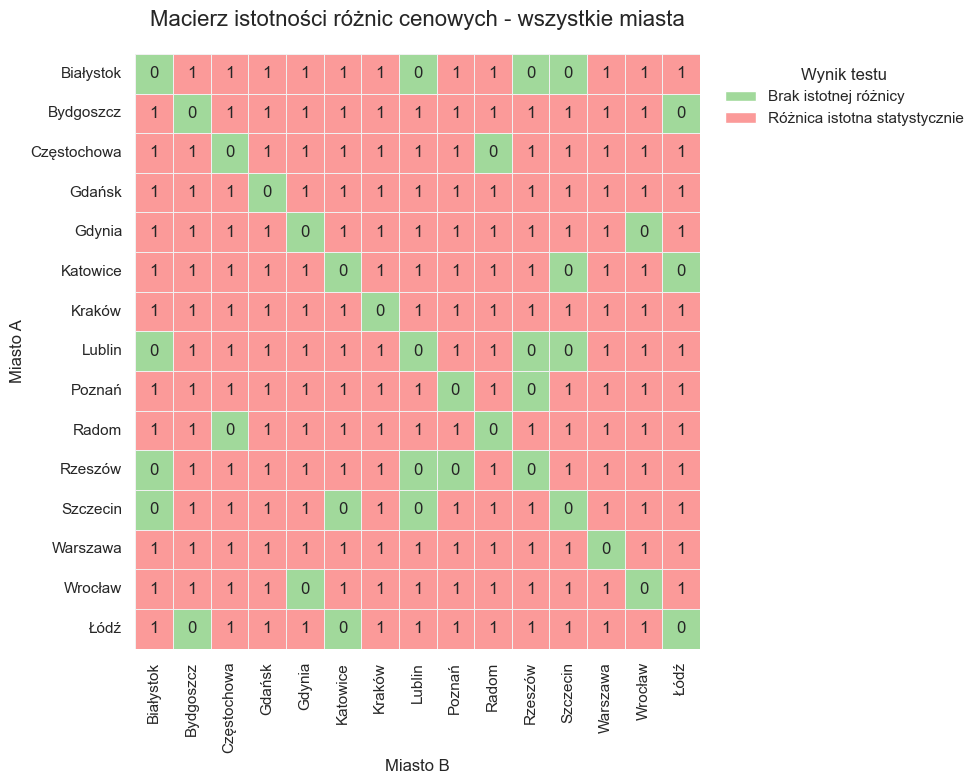


🔥 Pary miast z największą różnicą cenową:
         group1    group2    meandiff  reject
92        Radom  Warszawa  11574.0418    True
36  Częstochowa  Warszawa  11469.3368    True
24    Bydgoszcz  Warszawa  10309.9312    True
30  Częstochowa    Kraków  10100.8559    True
66     Katowice  Warszawa   9465.7055    True
99     Szczecin  Warszawa   8974.5139    True
18    Bydgoszcz    Kraków   8941.4503    True
81       Lublin  Warszawa   8443.1753    True
11    Białystok  Warszawa   8414.9035    True
27  Częstochowa    Gdańsk   8367.6878    True


In [109]:
# --- 1. Przygotowanie danych ---

df['miasto'] = df['miasto'].str.strip().str.title()

df_cities = df.copy()

target_col = 'pricePerM2' 
if target_col not in df_cities.columns:
    if 'cena_za_m2' in df_cities.columns:
        target_col = 'cena_za_m2'
    else:
        raise KeyError(f"Nie znaleziono kolumny z ceną za m2.")

# Usuwamy wiersze z brakującymi danymi
df_cities = df_cities.dropna(subset=[target_col, 'miasto'])

print(f"--- 🔬 Analiza istotności statystycznej dla wszystkich miast ---")

# --- 2. Wykonanie Testu Tukeya HSD ---
tukey = pairwise_tukeyhsd(endog=df_cities[target_col], 
                          groups=df_cities['miasto'], 
                          alpha=0.05)

# --- 3. Konwersja wyników na DataFrame ---
results_df = pd.DataFrame(data=tukey._results_table.data[1:], 
                          columns=tukey._results_table.data[0])

results_df['reject'] = results_df['reject'].astype(bool)
results_df['meandiff'] = pd.to_numeric(results_df['meandiff'])

# --- 4. Tworzenie macierzy binarnej ---
unique_cities = sorted(df_cities['miasto'].unique())
significance_matrix = pd.DataFrame(0, index=unique_cities, columns=unique_cities)

for _, row in results_df.iterrows():
    val = 1 if row['reject'] else 0
    significance_matrix.loc[row['group1'], row['group2']] = val
    significance_matrix.loc[row['group2'], row['group1']] = val

# --- 5. Wizualizacja ---

fig_size = max(10, len(unique_cities) * 0.6)
plt.figure(figsize=(fig_size, fig_size * 0.8))

sns.heatmap(
    significance_matrix,
    annot=len(unique_cities) < 25,
    cmap=sns.color_palette(["#a1d99b", "#fb9a99"]), 
    cbar=False,
    linewidths=.5,
    linecolor='#f0f0f0',
    fmt="d"
)

plt.title('Macierz istotności różnic cenowych - wszystkie miasta', fontsize=16, pad=20)
plt.xlabel('Miasto B', fontsize=12)
plt.ylabel('Miasto A', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#a1d99b', label='Brak istotnej różnicy'),
    Patch(facecolor='#fb9a99', label='Różnica istotna statystycznie')
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', title="Wynik testu")

plt.tight_layout()
plt.show()

print("\n🔥 Pary miast z największą różnicą cenową:")
print(results_df.sort_values(by='meandiff', ascending=False).head(10)[['group1', 'group2', 'meandiff', 'reject']])

Powyższa macierz wskazuje, między którymi miastami różnice w średniej cenie za m² są istotne statystycznie (1), a które rynki są do siebie zbliżone (0). Na jej podstawie można stwierdzić, że miastami o statystycznie tożsamych poziomach cen są m.in. Gdynia i Wrocław oraz Katowice i Łódź.

Oznacza to, że choć ich średnie ceny mogą się nieznacznie różnić, z punktu widzenia statystycznego różnice te są pomijalne i miasta te należą do tej samej klasy cenowej. Z kolei pola oznaczone jedynką (kolor czerwony) wyznaczają pary miast o wyraźnie odmiennej charakterystyce rynkowej, której nie da się wyjaśnić błędem losowym.


### 9. Analiza różnic cenowych: porównanie średniej ceny za m² między regionem wschodnim a zachodnim polski (test t Welcha)


--- 📊 Porównanie Regionalne Ceny za m² (N_Zachód=10748, N_Wschód=10753) ---
Średnia ZACHÓD: 14135.94 PLN/m²
Średnia WSCHÓD: 15079.94 PLN/m²
----------------------------------------
Statystyka t: -13.419
P-value: 6.96252e-41
Wniosek: Różnica średniej ceny za m² między Wschodem a Zachodem jest ISTOTNA STATYSTYCZNIE.


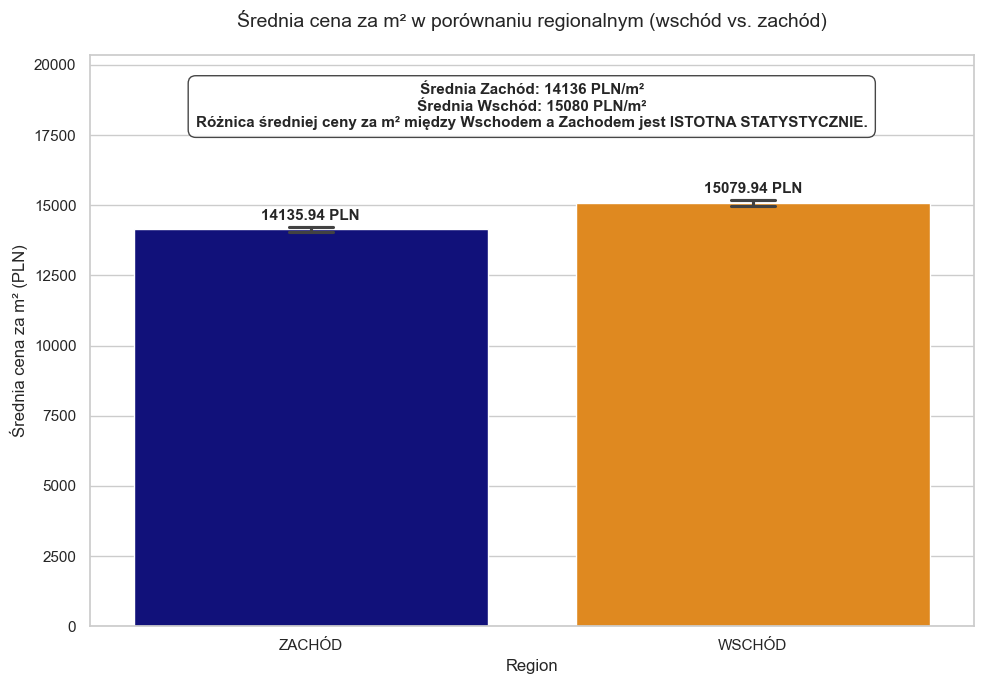

In [110]:
import pandas as pd
import scipy.stats as statystyka
import matplotlib.pyplot as plt
import seaborn as sns

# --- Ustawienia ---
ZMIENNA_CEL = 'cena_za_m2'
ALFA = 0.05

# --- 1. Definicja Regionów Wschód/Zachód ---
MIASTA_ZACHOD = ['gdańsk', 'gdynia', 'szczecin', 'wrocław', 'poznań', 'katowice', 'kraków', 'częstochowa']
MIASTA_WSCHOD = ['lublin', 'białystok', 'rzeszów', 'radom', 'łódź', 'warszawa', 'bydgoszcz']

# 2. Przygotowanie i Mapowanie Danych
if 'pricePerM2' in df.columns and 'cena_za_m2' not in df.columns:
    df = df.rename(columns={'pricePerM2': 'cena_za_m2'})

df['miasto_normalizacja'] = df['miasto'].str.lower().str.strip()

def mapuj_region_ew(miasto):
    if miasto in MIASTA_ZACHOD:
        return 'ZACHÓD'
    elif miasto in MIASTA_WSCHOD:
        return 'WSCHÓD'
    else:
        return 'INNE'

df['Region_EW'] = df['miasto_normalizacja'].apply(mapuj_region_ew)

# Filtrowanie tylko do regionów porównawczych i czyszczenie braków
df_regionalny_ew = df[df['Region_EW'].isin(['WSCHÓD', 'ZACHÓD'])].dropna(subset=[ZMIENNA_CEL, 'Region_EW']).copy()

# Wyodrębnienie próbek cen
probka_zachod = df_regionalny_ew[df_regionalny_ew['Region_EW'] == 'ZACHÓD'][ZMIENNA_CEL]
probka_wschod = df_regionalny_ew[df_regionalny_ew['Region_EW'] == 'WSCHÓD'][ZMIENNA_CEL]

print(f"--- 📊 Porównanie Regionalne Ceny za m² (N_Zachód={len(probka_zachod)}, N_Wschód={len(probka_wschod)}) ---")

# 3. Wykonanie Testu t (Test t-Welcha)
wynik_testu_t = statystyka.ttest_ind(probka_zachod, probka_wschod, equal_var=False)

# 4. Obliczenia i Wyniki Testu
srednia_zachod = probka_zachod.mean()
srednia_wschod = probka_wschod.mean()

print(f"Średnia ZACHÓD: {srednia_zachod:.2f} PLN/m²")
print(f"Średnia WSCHÓD: {srednia_wschod:.2f} PLN/m²")
print("-" * 40)
print(f"Statystyka t: {wynik_testu_t.statistic:.3f}")
print(f"P-value: {wynik_testu_t.pvalue:.5e}")

# 5. Wnioskowanie
if wynik_testu_t.pvalue < ALFA:
    wniosek = "Różnica średniej ceny za m² między Wschodem a Zachodem jest ISTOTNA STATYSTYCZNIE."
else:
    wniosek = "Nie ma podstaw do odrzucenia H₀. Różnica w średniej cenie nie jest istotna statystycznie."
print(f"Wniosek: {wniosek}")

# --- WIZUALIZACJA ---
plt.figure(figsize=(10, 7))

# Wykres słupkowy
ax = sns.barplot(
    x='Region_EW',
    y=ZMIENNA_CEL,
    data=df_regionalny_ew,
    hue='Region_EW',    
    legend=False,       
    capsize=0.1, 
    palette={'ZACHÓD': 'darkblue', 'WSCHÓD': 'darkorange'},
    errorbar=('ci', 95)
)

plt.ylim(0, max(srednia_zachod, srednia_wschod) * 1.35)

# Dodanie dokładnych wartości nad słupkami
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} PLN', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.text(0.5, 0.95, 
         f"Średnia Zachód: {srednia_zachod:.0f} PLN/m²\nŚrednia Wschód: {srednia_wschod:.0f} PLN/m²\n{wniosek}",
         transform=ax.transAxes,
         ha='center', va='top', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.9, ec="#333333"))

plt.title('Średnia cena za m² w porównaniu regionalnym (wschód vs. zachód)', fontsize=14, pad=20)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Średnia cena za m² (PLN)', fontsize=12)

plt.tight_layout()
plt.show()

Analiza porównawcza średniej ceny za m² między regionami Polski wykazała istotne różnice. Średnia cena na Zachodzie wynosi 14 135,94 PLN/m², natomiast na Wschodzie 15 079,94 PLN/m². Test t dla dwóch niezależnych prób dał wartość statystyki t = -13,419 oraz p-value ≈ 6,96×10⁻⁴¹, co jest znacznie poniżej progu istotności 0,05.
Wniosek: Różnica średnich cen za m² między Wschodem a Zachodem jest istotna statystycznie, co sugeruje, że mieszkania we wschodnich regionach Polski są średnio droższe niż w zachodnich. Wynik ten może odzwierciedlać różnice w popycie, dostępności gruntów, lokalizacji i charakterze zabudowy w poszczególnych częściach kraju.

### 10. Badanie wpływu liczby pokoi na całkowitą cenę nieruchomości

--- 🔬 Analiza zależności: Cena (mln zł) vs Liczba pokoi ---


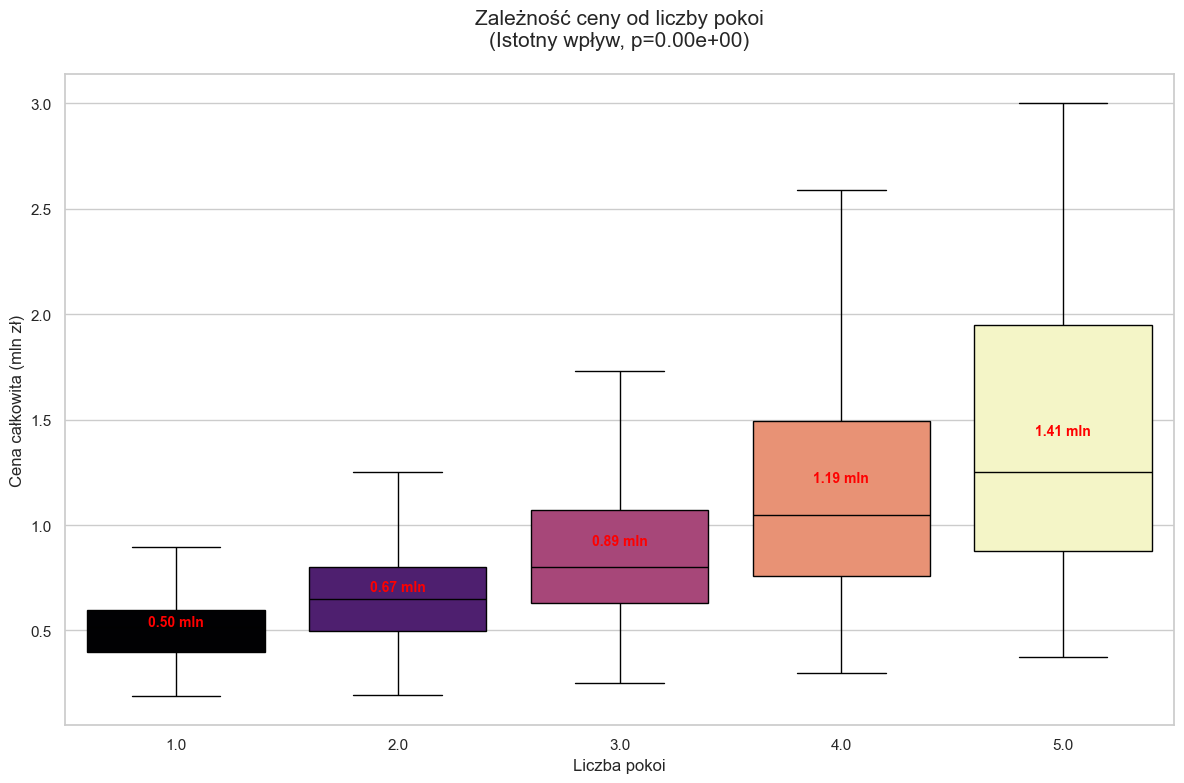

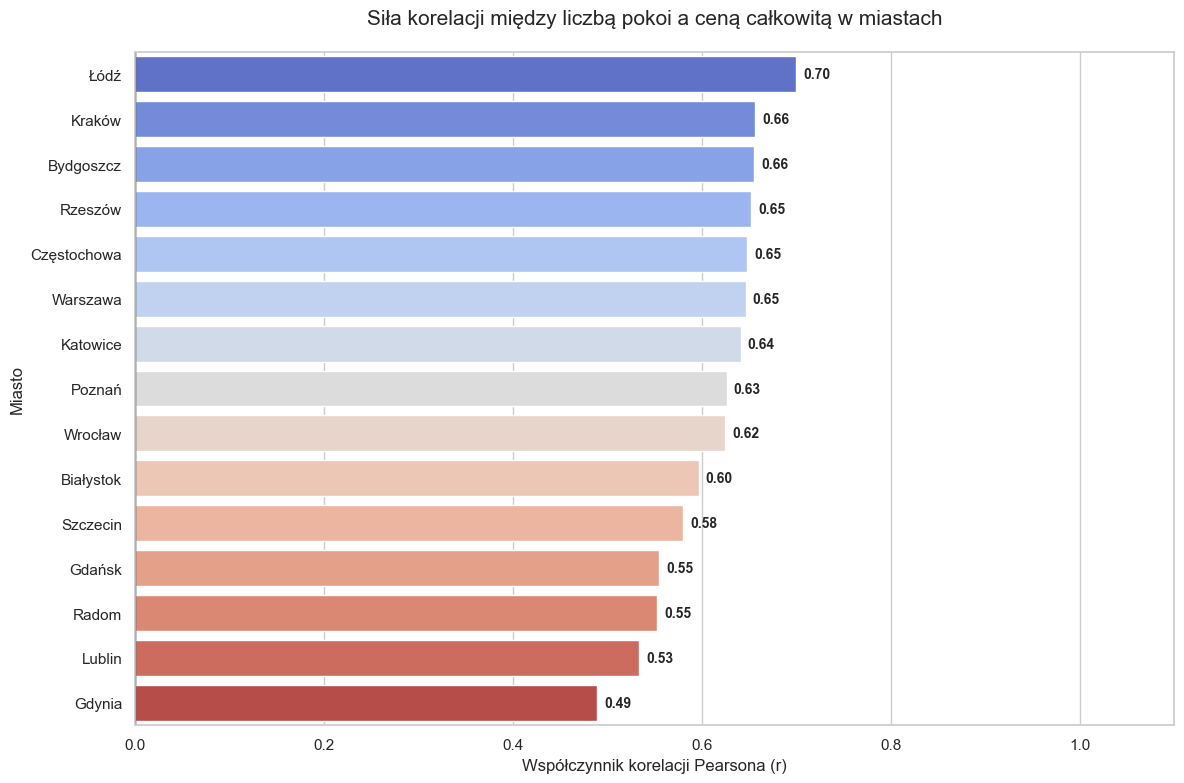


🔥 Ranking miast (najsilniejszy wpływ liczby pokoi na cenę):
         Miasto  Korelacja
0          Łódź   0.699602
1        Kraków   0.656506
2     Bydgoszcz   0.655219
3       Rzeszów   0.652424
4   Częstochowa   0.647984
5      Warszawa   0.646356
6      Katowice   0.640892
7        Poznań   0.626122
8       Wrocław   0.624572
9     Białystok   0.596841
10     Szczecin   0.579971
11       Gdańsk   0.554830
12        Radom   0.552626
13       Lublin   0.533449
14       Gdynia   0.489116


In [126]:

# --- SEKCJA A: ANALIZA CENY OD LICZBY POKOI (SKALA W MLN ZŁ) ---

# 1. Przygotowanie danych
kolumna_pokoi = 'rooms' if 'rooms' in df.columns else 'liczba_pokoi'
ZMIENNA_CEL = 'cena' if 'cena' in df.columns else 'price'

# Filtrowanie i kopia danych
df_pokoje = df.dropna(subset=[ZMIENNA_CEL, kolumna_pokoi]).copy()
df_pokoje = df_pokoje[df_pokoje[kolumna_pokoi].between(1, 5)]

# PRZELICZENIE NA MILIONY
df_pokoje['cena_mln'] = df_pokoje[ZMIENNA_CEL] / 1_000_000

print(f"--- 🔬 Analiza zależności: Cena (mln zł) vs Liczba pokoi ---")

# 2. Test ANOVA
grupy = [group['cena_mln'].values for name, group in df_pokoje.groupby(kolumna_pokoi)]
wynik_anova = statystyka.f_oneway(*grupy)

# 3. Test Post-Hoc
tukey = pairwise_tukeyhsd(endog=df_pokoje['cena_mln'], 
                          groups=df_pokoje[kolumna_pokoi], 
                          alpha=0.05)

# 4. Wizualizacja
plt.figure(figsize=(12, 8))

# Wykres pudełkowy
ax = sns.boxplot(
    x=kolumna_pokoi, 
    y='cena_mln', 
    data=df_pokoje, 
    palette='magma',
    hue=kolumna_pokoi,
    legend=False,
    showfliers=False
)


# Wynik ANOVA do tytułu
wniosek = "Istotny wpływ" if wynik_anova.pvalue < 0.05 else "Brak istotnego wpływu"

plt.title(f'Zależność ceny od liczby pokoi\n({wniosek}, p={wynik_anova.pvalue:.2e})', fontsize=15, pad=20)
plt.xlabel('Liczba pokoi', fontsize=12)
plt.ylabel('Cena całkowita (mln zł)', fontsize=12)

# Etykiety średnich na czerwono (w formacie 0.00 mln)
srednie = df_pokoje.groupby(kolumna_pokoi)['cena_mln'].mean()
for i, srednia in enumerate(srednie):
    plt.text(i, srednia, f'{srednia:.2f} mln', 
             ha='center', va='bottom', 
             fontweight='bold', 
             color='red', 
             fontsize=10)

plt.tight_layout()
plt.show()

# --- SEKCJA B: KORELACJA LICZBY POKOI I CENY W MIASTACH ---

# 1. Przygotowanie danych
kolumna_miasto = 'miasto'
df_kor = df.dropna(subset=[kolumna_pokoi, ZMIENNA_CEL, kolumna_miasto]).copy()

# Konwersja na typy numeryczne
df_kor[kolumna_pokoi] = pd.to_numeric(df_kor[kolumna_pokoi])
df_kor[ZMIENNA_CEL] = pd.to_numeric(df_kor[ZMIENNA_CEL])

# 2. Obliczanie korelacji dla każdego miasta
lista_korelacji = []
for miasto, grupa in df_kor.groupby(kolumna_miasto):
    if len(grupa) > 10:  # Tylko miasta z odpowiednią liczbą danych
        korelacja = grupa[kolumna_pokoi].corr(grupa[ZMIENNA_CEL])
        lista_korelacji.append({'Miasto': miasto.title(), 'Korelacja': korelacja})

wyniki_kor_df = pd.DataFrame(lista_korelacji).sort_values(by='Korelacja', ascending=False)

# 3. Wizualizacja korelacji
plt.figure(figsize=(12, 8))
paleta = sns.color_palette("coolwarm", len(wyniki_kor_df))

ax = sns.barplot(
    x='Korelacja', 
    y='Miasto', 
    data=wyniki_kor_df, 
    palette=paleta,
    hue='Miasto',
    legend=False
)

plt.axvline(0, color='black', linestyle='-', linewidth=1)

# Dodanie wartości korelacji na końcach słupków
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.2f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.title('Siła korelacji między liczbą pokoi a ceną całkowitą w miastach', fontsize=15, pad=20)
plt.xlabel('Współczynnik korelacji Pearsona (r)', fontsize=12)
plt.ylabel('Miasto', fontsize=12)
plt.xlim(0, 1.1)

plt.tight_layout()
plt.show()

# 4. Podsumowanie
print("\n🔥 Ranking miast (najsilniejszy wpływ liczby pokoi na cenę):")
print(wyniki_kor_df.reset_index(drop=True))


Analiza wykazała, że najniższy przyrost średniej ceny występuje przy przejściu z jednego na dwa pokoje i wynosi 167 tys. zł. Z kolei najbardziej skokowy wzrost ceny o 222 tys. zł  odnotowano pomiędzy lokalami 4, a 5-pokojowymi. We wszystkich badanych miastach stwierdzono silną korelację dodatnią między liczbą pokoi a ceną całkowitą; najwyższy współczynnik korelacji zaobserwowano w Łodzi, natomiast najniższy w Gdyni.”

# -----------------------------------------------------
### Podsumowanie projektu: analiza rynku nieruchomości
# -----------------------------------------------------

Niniejszy projekt stanowi kompleksowe opracowanie analityczne oparte na zbiorze 21 501 ofert sprzedaży mieszkań z 15 największych miast Polski, pozyskanych z serwisu OTODOM w czerwcu 2024 roku. Celem badania było zrozumienie struktury cenowej, terytorialnej oraz technicznej rynku nieruchomości przy wykorzystaniu zaawansowanych metod statystycznych. Proces badawczy rozpoczęto od rygorystycznego przygotowania danych, w tym tłumaczenia zmiennych oraz imputacji braków z wykorzystaniem algorytmów MICE dla danych numerycznych oraz KNN dla cech kategorycznych (takich jak typ zabudowy czy obecność windy). Dzięki tym zabiegom uzyskano zbiór o wysokiej spójności, pozwalający na precyzyjne wnioskowanie o parametrach populacji z 95-procentowym poziomem ufności.

Analiza statystyk opisowych pozwoliła nakreślić profil statystycznej nieruchomości: typowe polskie mieszkanie oferowane na rynku wtórnym i pierwotnym ma powierzchnię 57 m² (3 pokoje), znajduje się w budynku wzniesionym średnio w 1993 roku i jest zlokalizowane w gęstej tkance miejskiej, zaledwie 300–400 metrów od kluczowych punktów użyteczności publicznej, takich jak szkoły czy apteki. Rozkład całkowitych cen mieszkań wykazuje silną asymetrię prawostronną (mediana 721 824 PLN przy średniej 823 868 PLN), co jest wynikiem obecności segmentu luksusowego (oferty do 3 mln PLN), który istotnie zawyża wyniki średnie, podczas gdy typowy nabywca operuje w znacznie niższych przedziałach cenowych.

Wnioskowanie statystyczne dostarczyło dowodów na istnienie głębokich podziałów rynkowych. Test t-Welcha potwierdził z bardzo wysoką istotnością (p<0,001), że region wschodni Polski, silnie stymulowany przez rynek warszawski, charakteryzuje się cenami za metr kwadratowy wyższymi średnio o 944 PLN względem regionu zachodniego. Jednocześnie, wykorzystując podział metrażu na tercyle, wykazano słuszność rynkowej zasady „im mniejsze, tym droższe jednostkowo” – mieszkania małe (do 46,5 m²) osiągają najwyższą średnią cenę wynoszącą 15 647 PLN/m². Analiza korelacji Spearmana ujawniła z kolei procesy urbanizacyjne: nowsze budownictwo jest statystycznie lokalizowane dalej od centrów miast (r≈0,36), co odzwierciedla terytorialny rozwój metropolii.

Kluczowym elementem projektu była segmentacja miast przeprowadzona za pomocą testu Post-Hoc Tukeya. Pozwolił on na stworzenie macierzy istotności, która oddziela rynki o tożsamej charakterystyce (np. Gdynia i Wrocław lub Katowice i Łódź) od rynków całkowicie odrębnych. Warszawa pozostaje pod tym względem niekwestionowanym liderem i outlierem, z cenami o ponad 11 000 PLN/m² wyższymi niż w Radomiu czy Częstochowie. Dodatkowo, testy zależności wykazały, że całkowita cena nieruchomości rośnie skokowo wraz z liczbą pokoi, przy czym największy przyrost (średnio o 222 tys. PLN) następuje przy przejściu z lokalu 4- na 5-pokojowy.

Podsumowując, polski rynek nieruchomości w 2024 roku jawi się jako struktura stabilna pod względem średnich parametrów, ale wysoce zróżnicowana w ujęciu jednostkowym. Choć przedziały ufności dla średnich cen są wąskie, szerokie przedziały predykcji wskazują na dużą rolę indywidualnych cech lokali w procesie wyceny. Dominacja bloków mieszkalnych (64%) oraz silna korelacja między typem zabudowy a wyposażeniem w windę (potwierdzona testem Chi-kwadrat) wskazują, że standard techniczny pozostaje obok lokalizacji głównym determinantem wartości nieruchomości w Polsce.